In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [3]:
url = "https://scor.ascm.org/"

response = requests.get(url)

print(response.status_code)

200


In [4]:
print(response.text[:1000])




<!doctype html>
<html lang="en">

<head>

    <!-- Google Tag Manager -->
    <script nonce="rcvr4kNE7rWhvcLR6yRMZfpC">
        (function (w, d, s, l, i) {
            w[l] = w[l] || [];
            w[l].push({
                'gtm.start':
                    new Date().getTime(), event: 'gtm.js'
            });
            var f = d.getElementsByTagName(s)[0],
                j = d.createElement(s),
                dl = l != 'dataLayer' ? '&l=' + l : '';
            j.async = true;
            j.src = 'https://www.googletagmanager.com/gtm.js?id=' + i + dl;
            f.parentNode.insertBefore(j, f);
        })(window, document, 'script', 'dataLayer', 'GTM-T55XZB2');
    </script>
    <!-- End Google Tag Manager -->

    <meta charset="utf-8">
    <title>SCOR Model</title>

    <meta id="metaForScaling" name="viewport" content="width=device-width">

    <link rel="icon" type="image/x-icon" href="/scor/favicon.ico">
    <style>
        .loading-label


In [7]:
soup = BeautifulSoup(response.text, "html.parser")

In [8]:
print(soup.title)

<title>SCOR Model</title>


In [9]:
len(soup.find_all("a"))

0

In [10]:
len(soup.find_all("table"))

0

In [11]:
print(response.status_code)
print(response.url)
print(response.text[:500])

200
https://scor.ascm.org/



<!doctype html>
<html lang="en">

<head>

    <!-- Google Tag Manager -->
    <script nonce="rcvr4kNE7rWhvcLR6yRMZfpC">
        (function (w, d, s, l, i) {
            w[l] = w[l] || [];
            w[l].push({
                'gtm.start':
                    new Date().getTime(), event: 'gtm.js'
            });
            var f = d.getElementsByTagName(s)[0],
                j = d.createElement(s),
                dl = l != 'dataLayer' ? '&l=' + l : '';
            j.asyn


In [15]:
import requests
from bs4 import BeautifulSoup

url = "https://scor.ascm.org/"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

# استخراج كل الروابط
links = soup.find_all("a")

for link in links:
    text = link.get_text(" ", strip=True)
    href = link.get("href")
    
    if text:
        print(text, "→", href)

In [16]:
print("HTML length:", len(response.text))

HTML length: 25231


In [17]:
print(response.text[-1000:])

 </scor-root>

    <script nonce="S1mJKOXAUVTQH/&#x2B;zvWt/Ff12">
        var analyticsDataLayer = {
            pageInfo: {
                pageName: 'SCOR',
                userId: ''
            }
        };

        var SITE_NAME = "SCOR";
        var BASE_HREF = "/";

        var ENV = "prdscor";
        var USER_NAME = "No Name";
        var SAME_DOMAIN = "ascm.org";
        var FEATURES = {};
        var webConfig = {
            userID: "",
            externalUserEmail: "null",
            role: "Pilot",
            omnitureDTMUrl: ""
        };
        var ascmRouting = {
            signUpUrl: "https://ascm.org/create-account",
        }
    </script>
<script src="/scor/runtime.39b2be7081d19b39378b.js" defer></script><script src="/scor/polyfills-es5.0d1e5531189f00f8109b.js" nomodule defer></script><script src="/scor/polyfills.9de05f95fd508b93b4cc.js" defer></script><script src="/scor/main.bd8cd64481d1f524223b.js" defer></script></body>

</html>



In [19]:
import requests
import re

js_url = "https://scor.ascm.org/scor/main.bd8cd64481d1f524223b.js"

js_response = requests.get(js_url)

print("Status:", js_response.status_code)
print("JS length:", len(js_response.text))

Status: 200
JS length: 19061875


http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
http://www.w3.org/2000/svg
http://www.w3.org/1999/xlink
/api/user/current/permissions
/api/user/current/info
/api/files/
/api/scor/cache































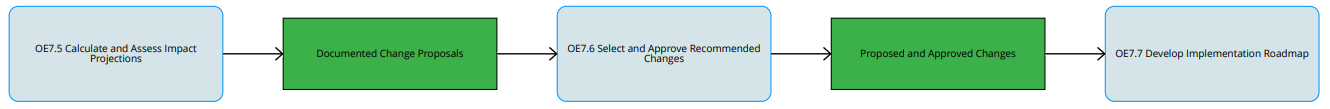
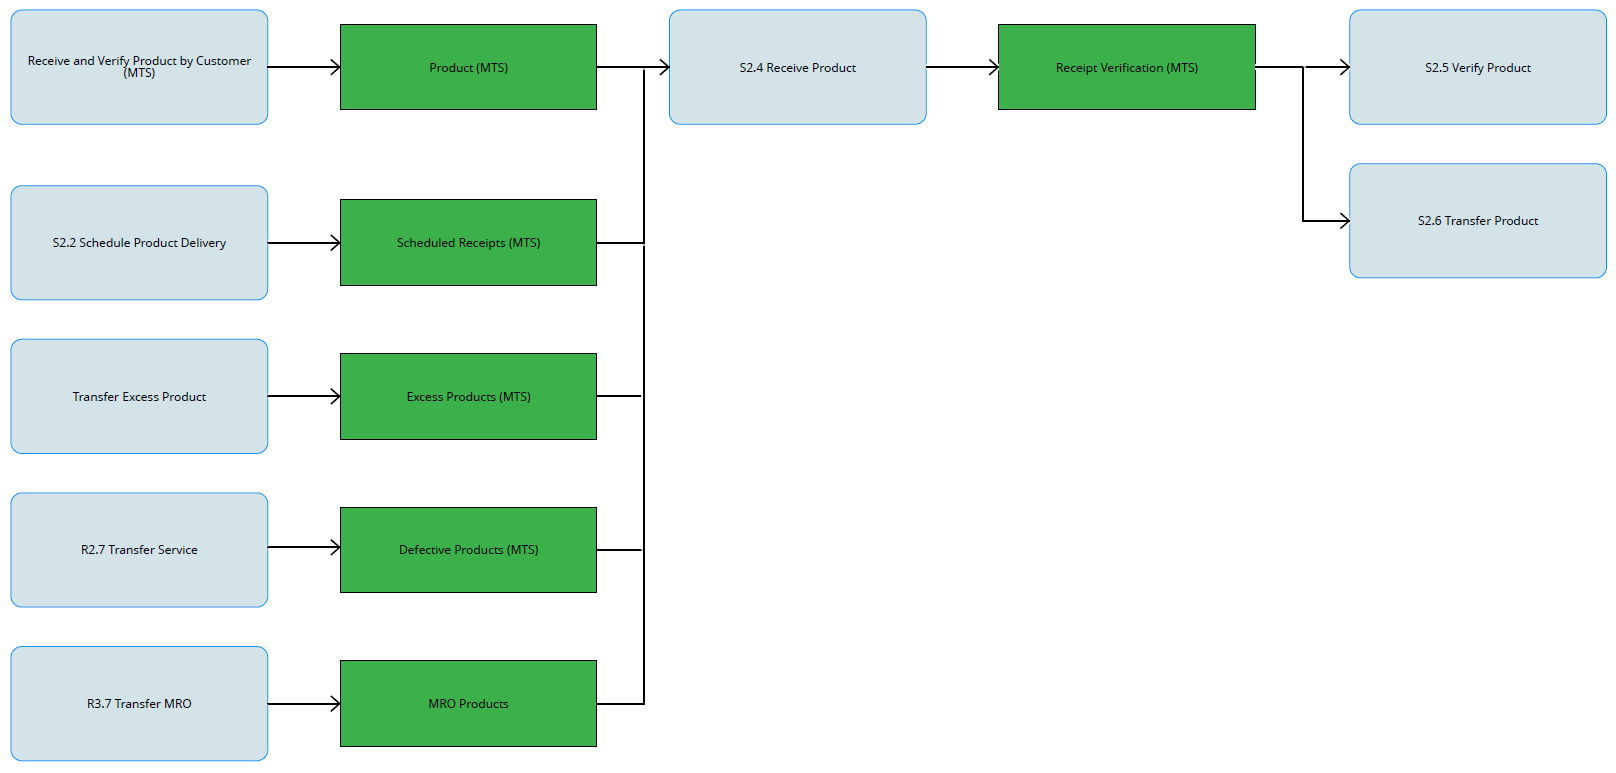
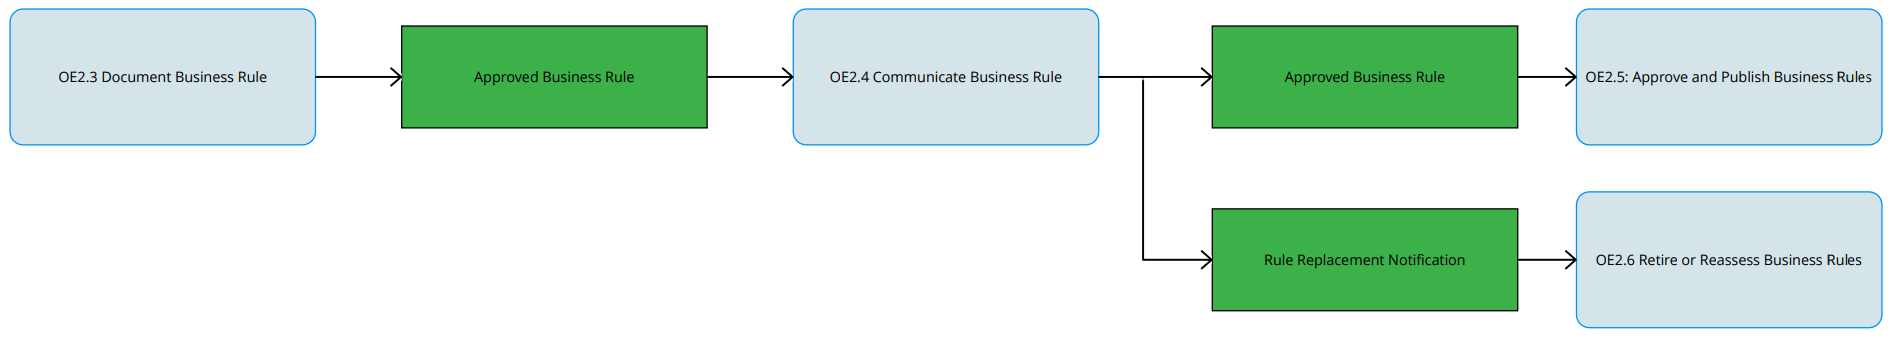
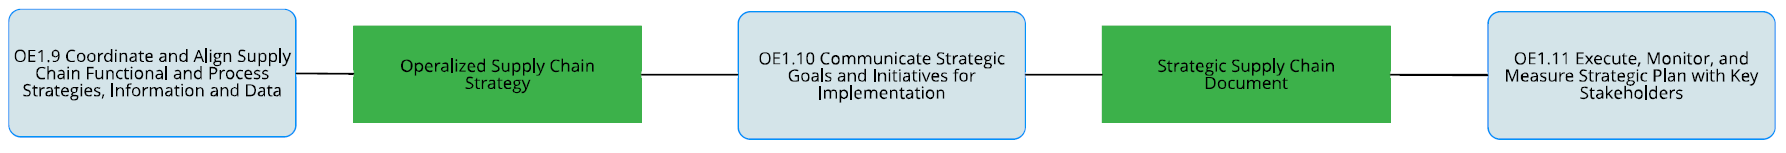
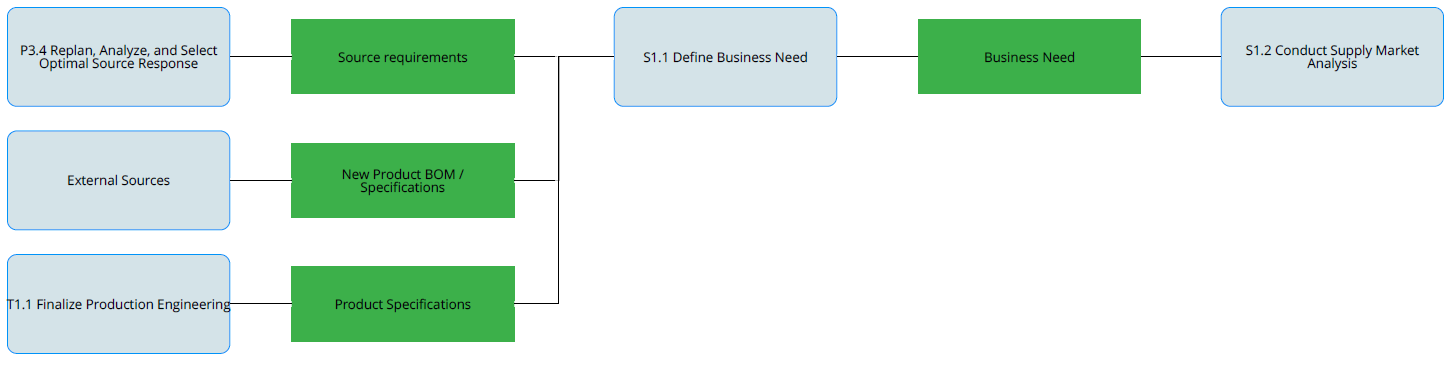
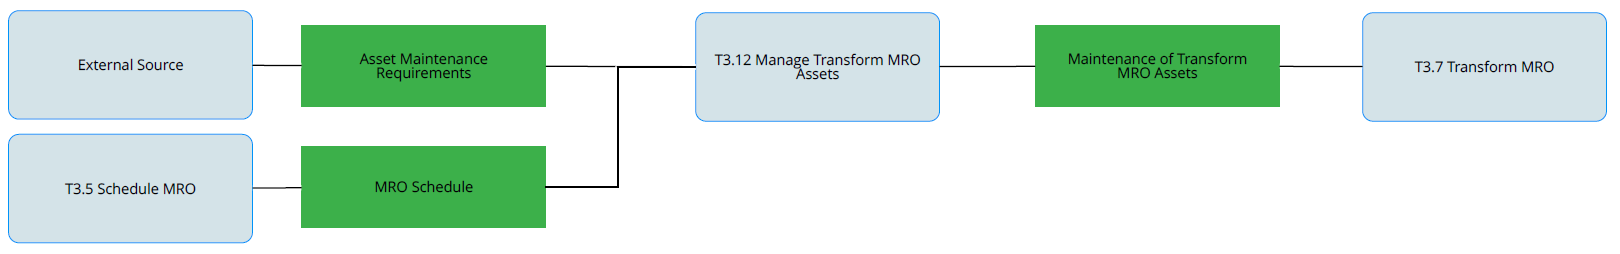
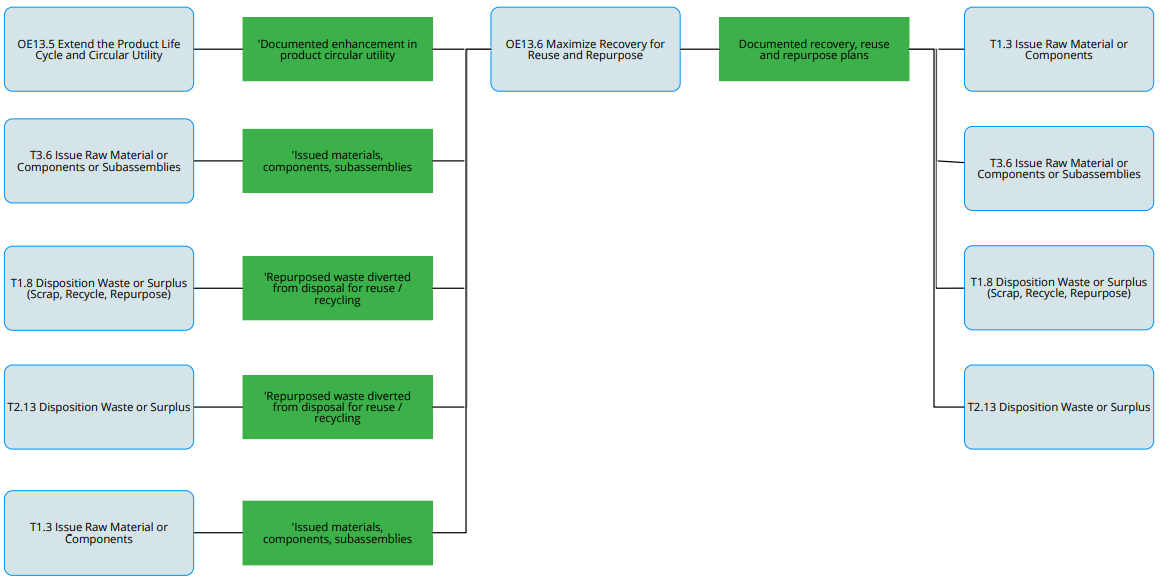
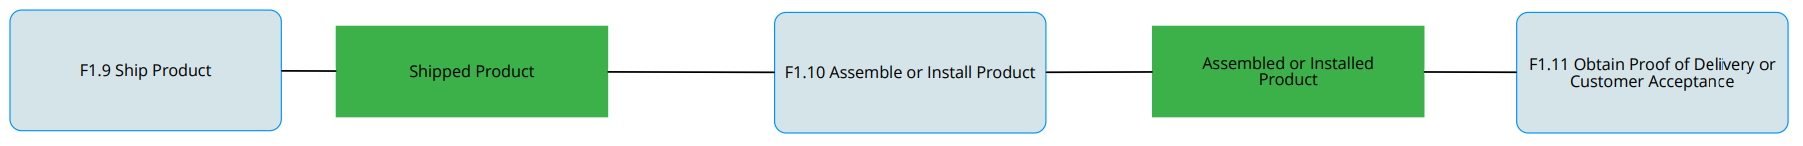
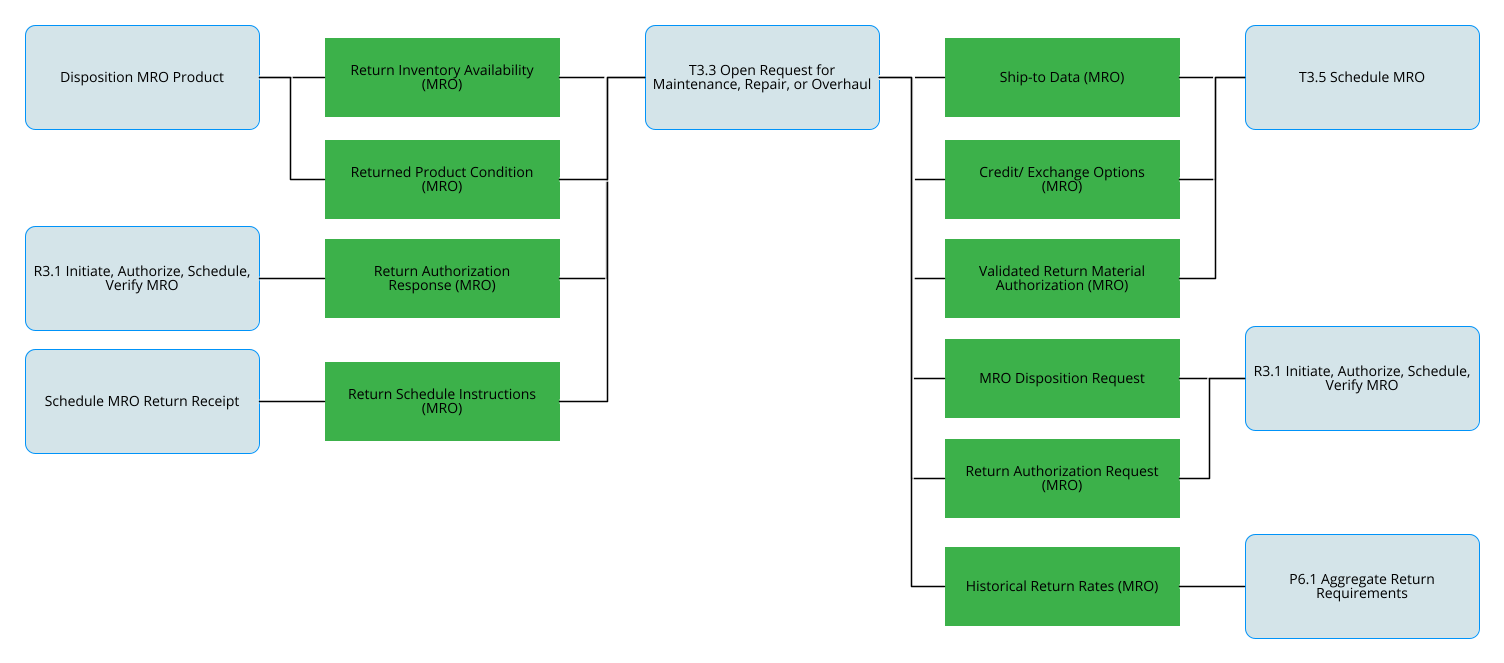
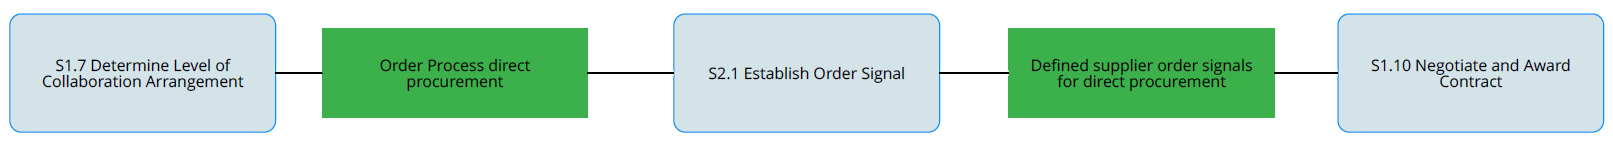
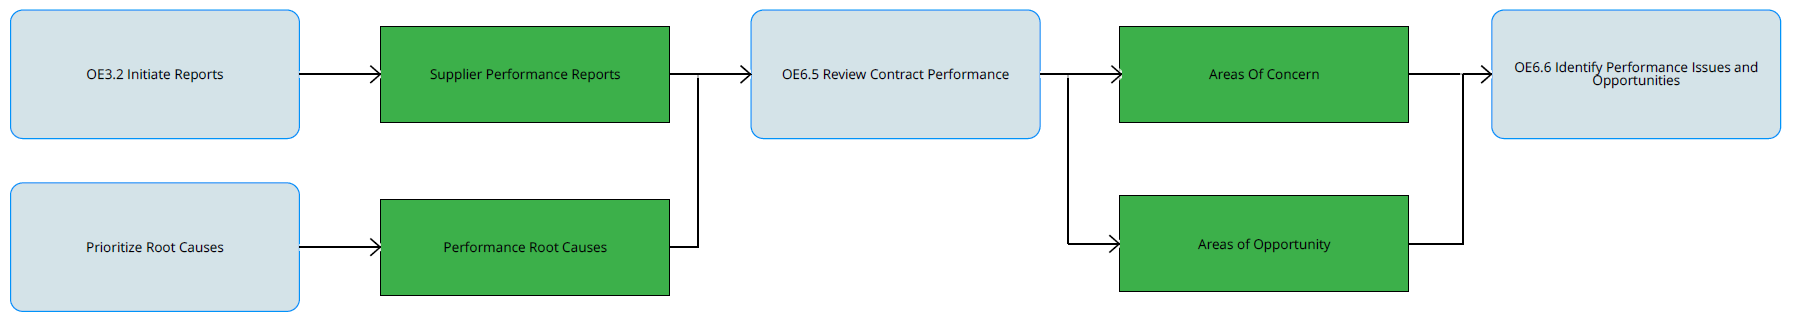
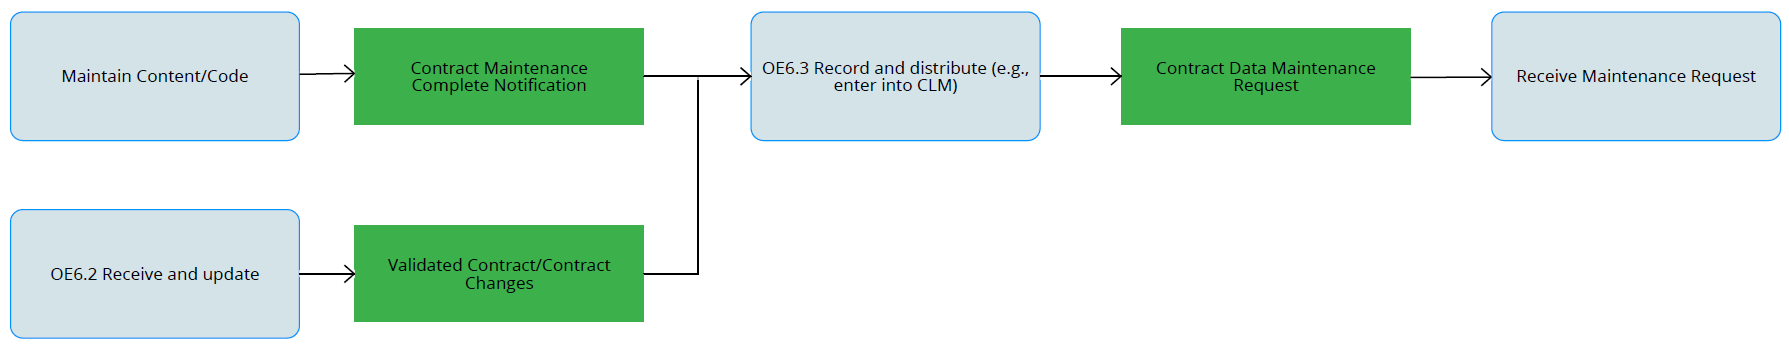
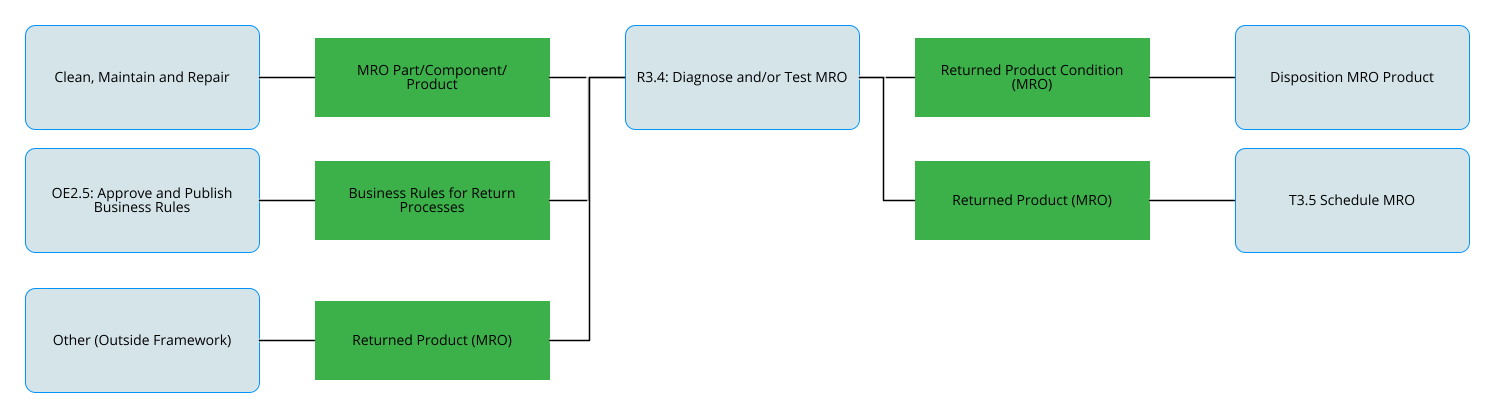
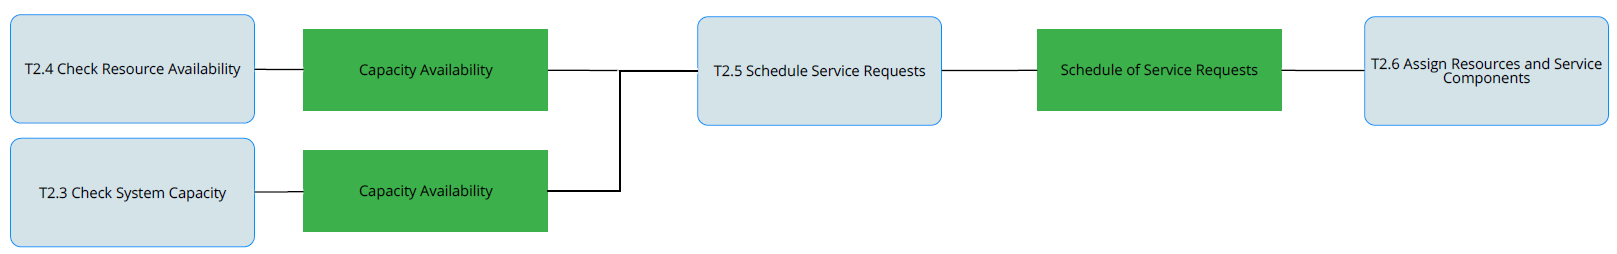
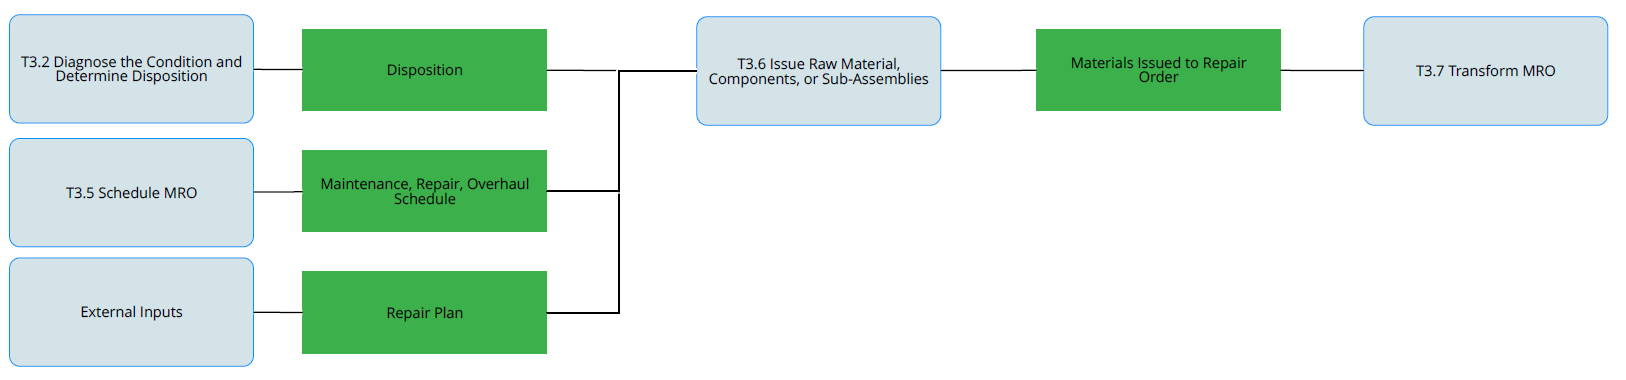
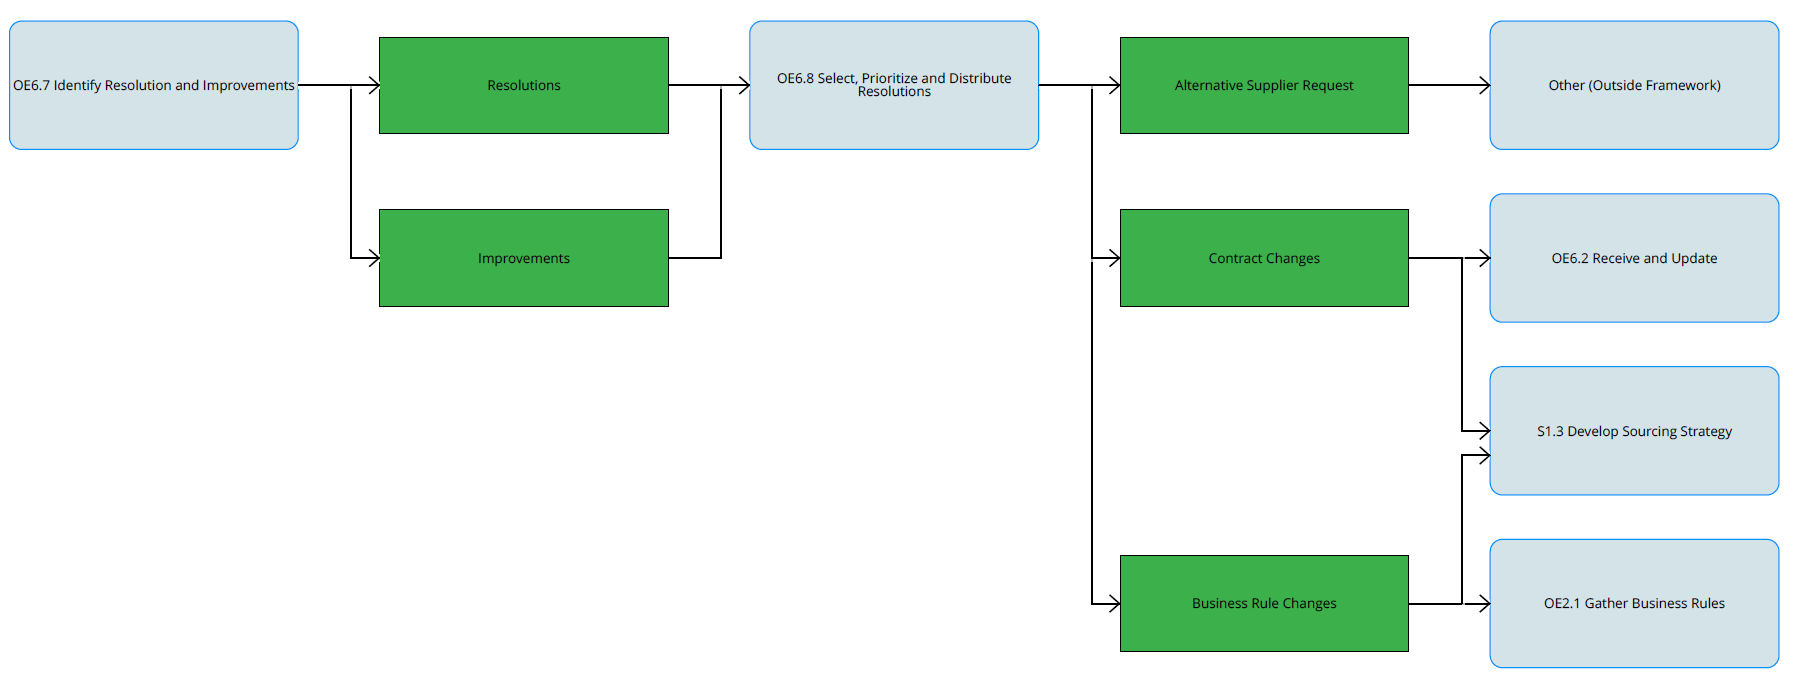
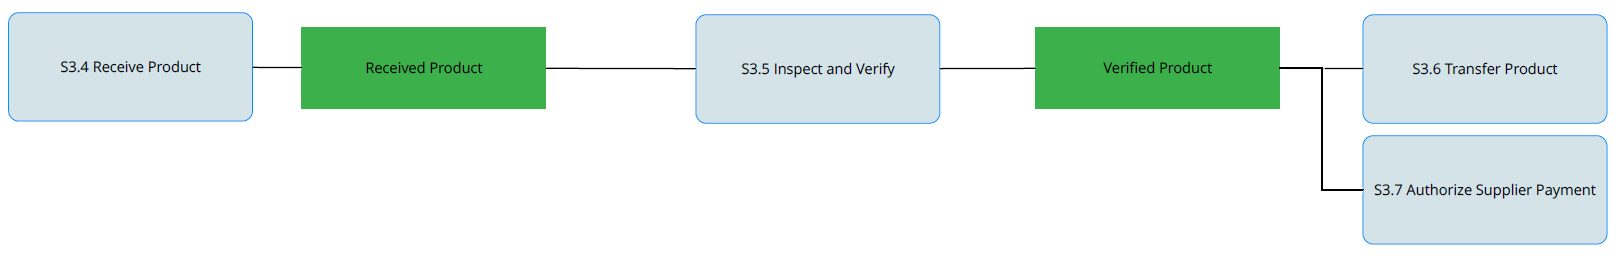
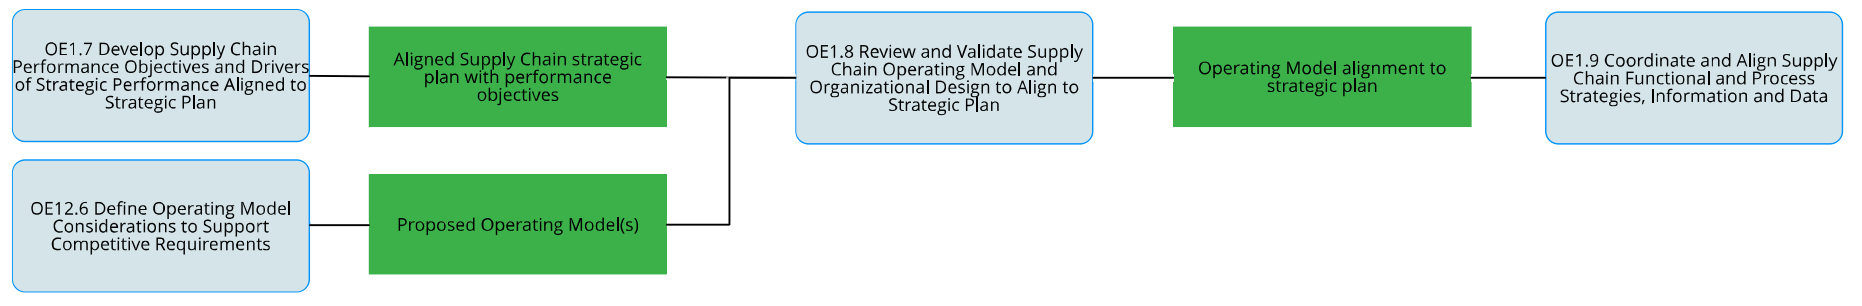
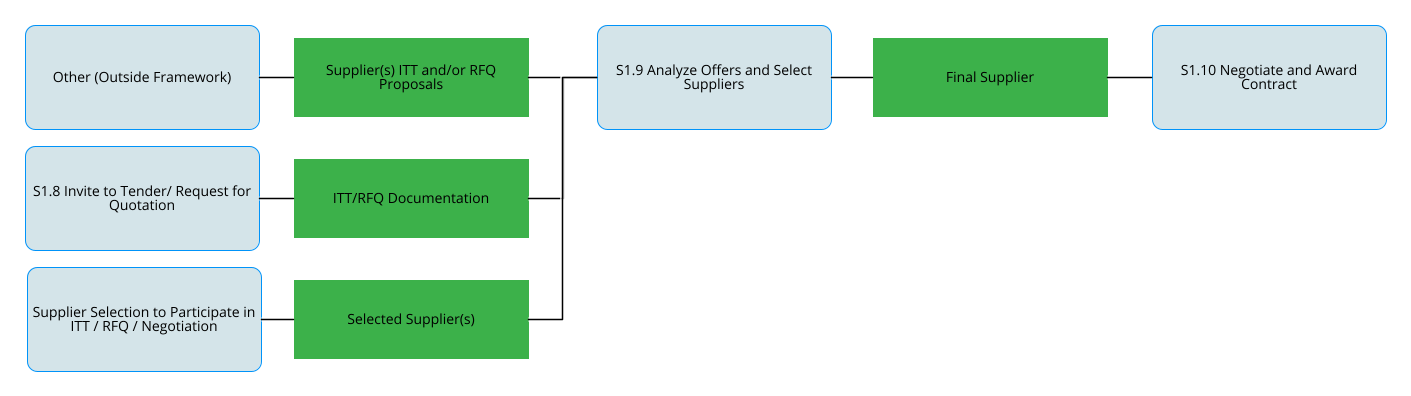
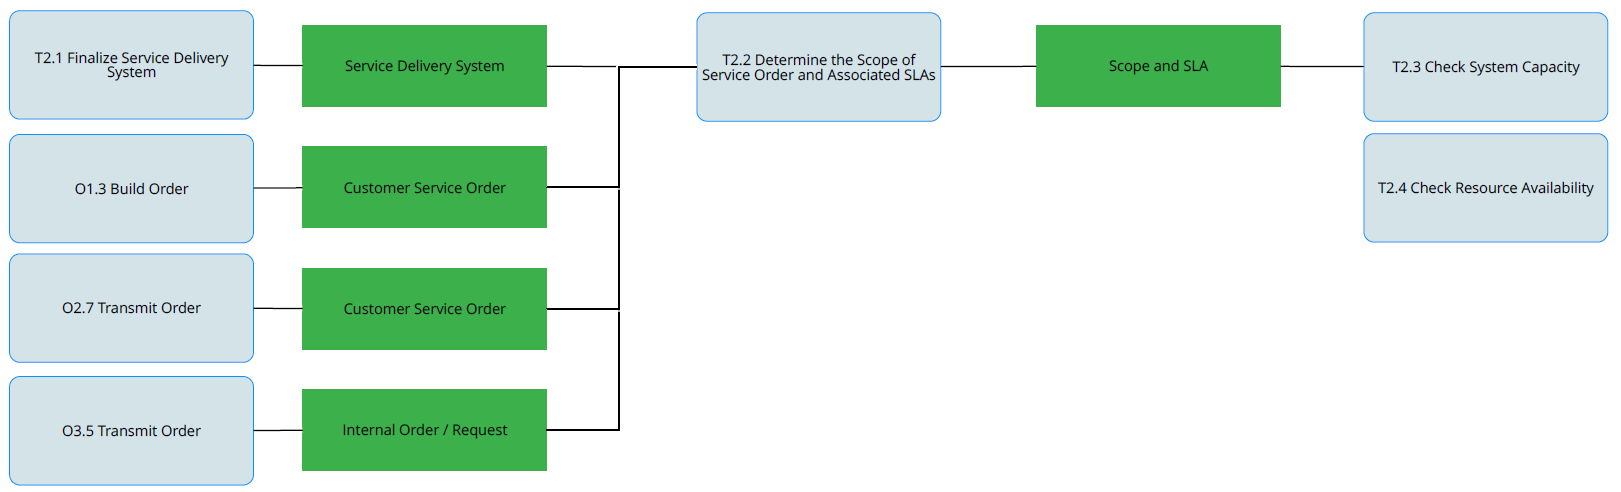
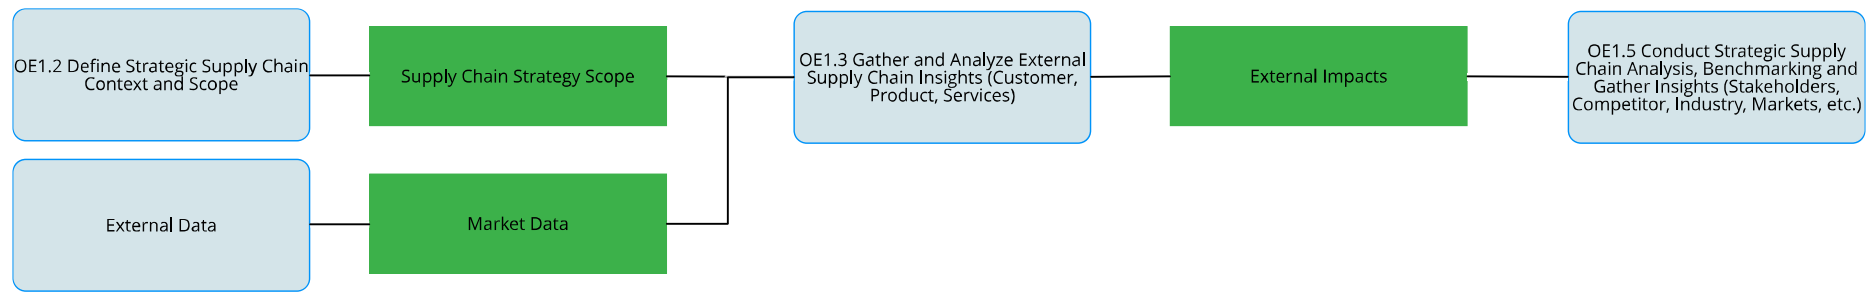
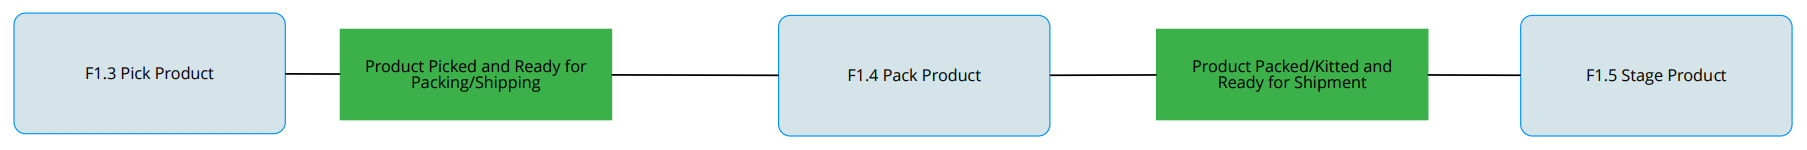
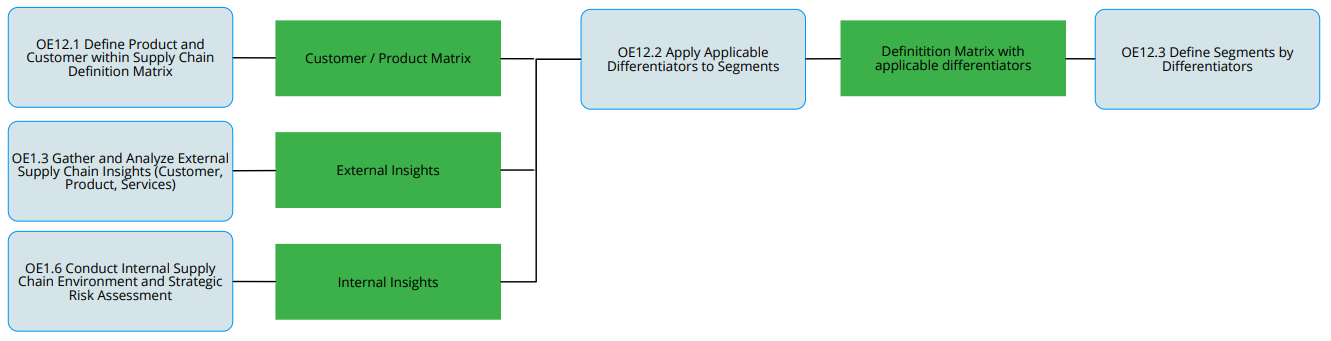
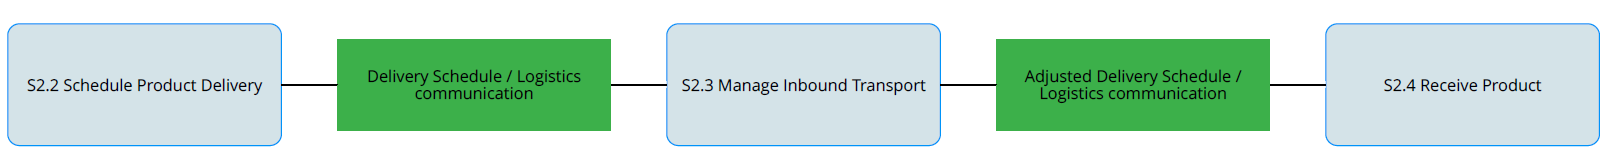
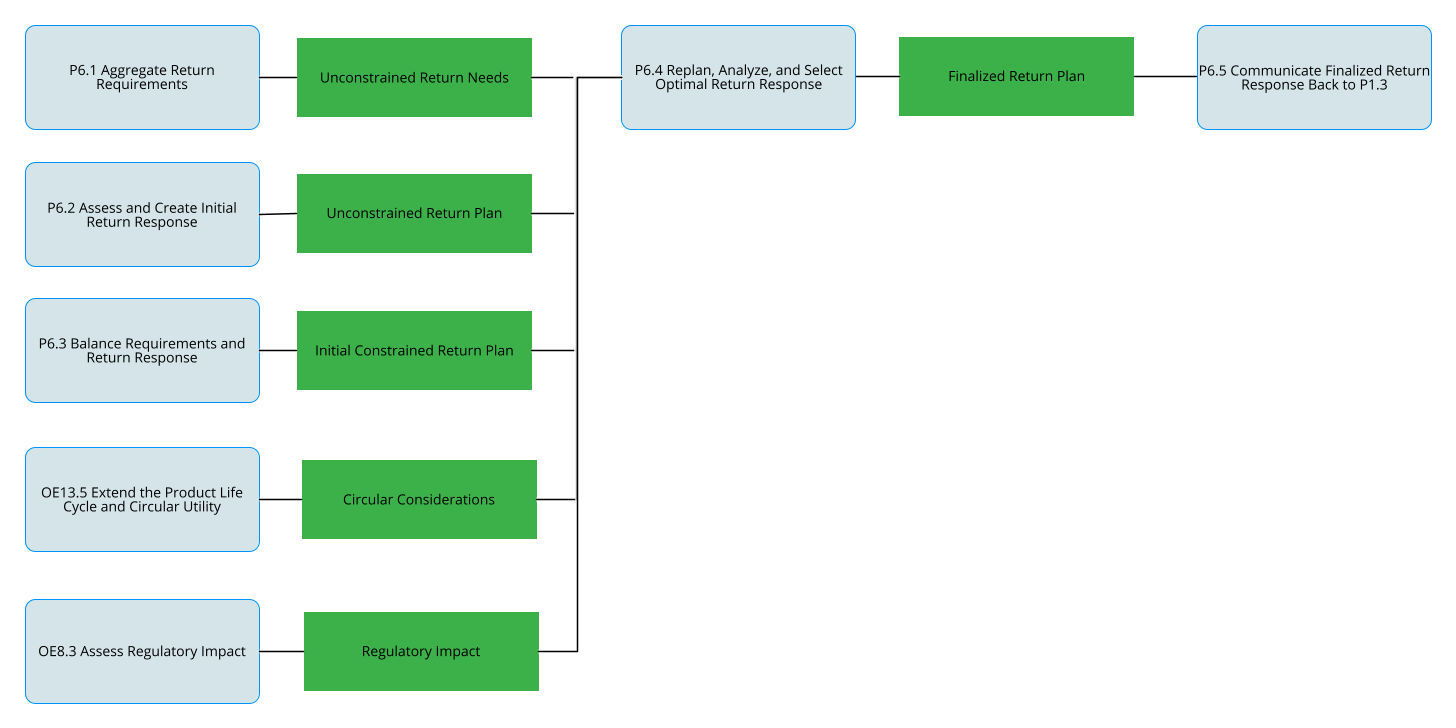
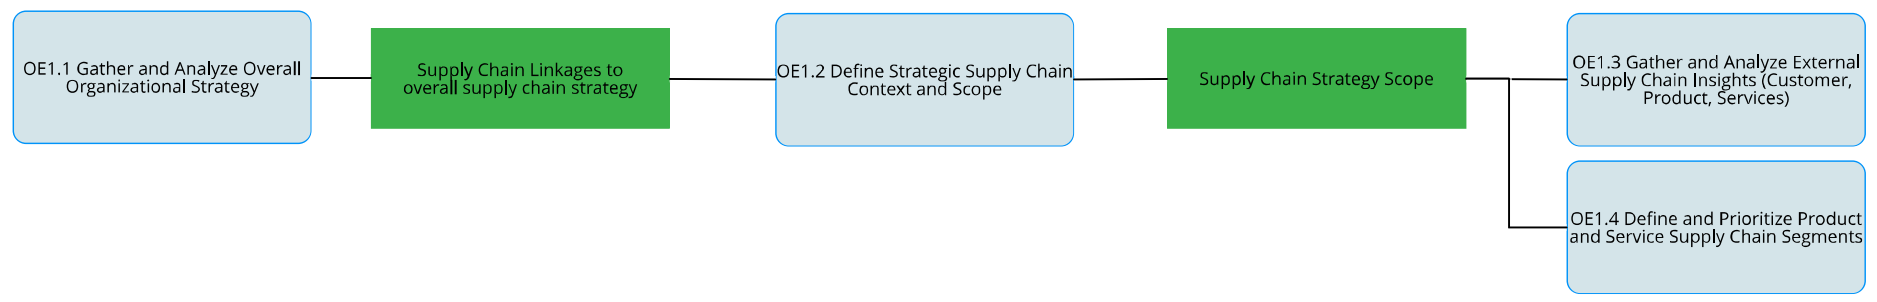
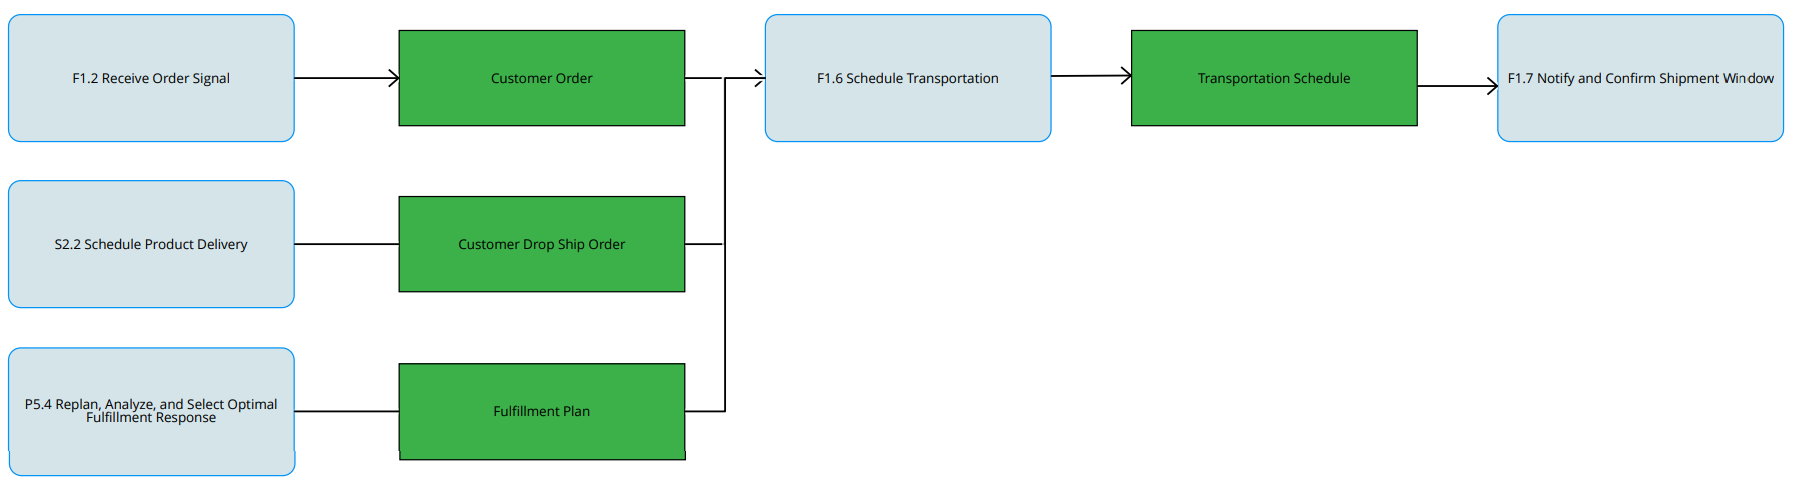
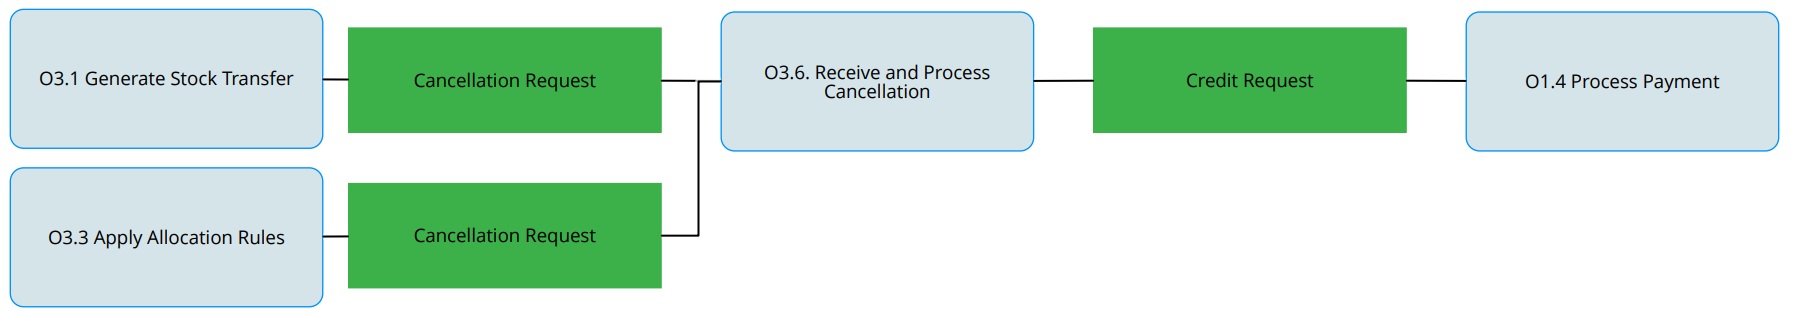
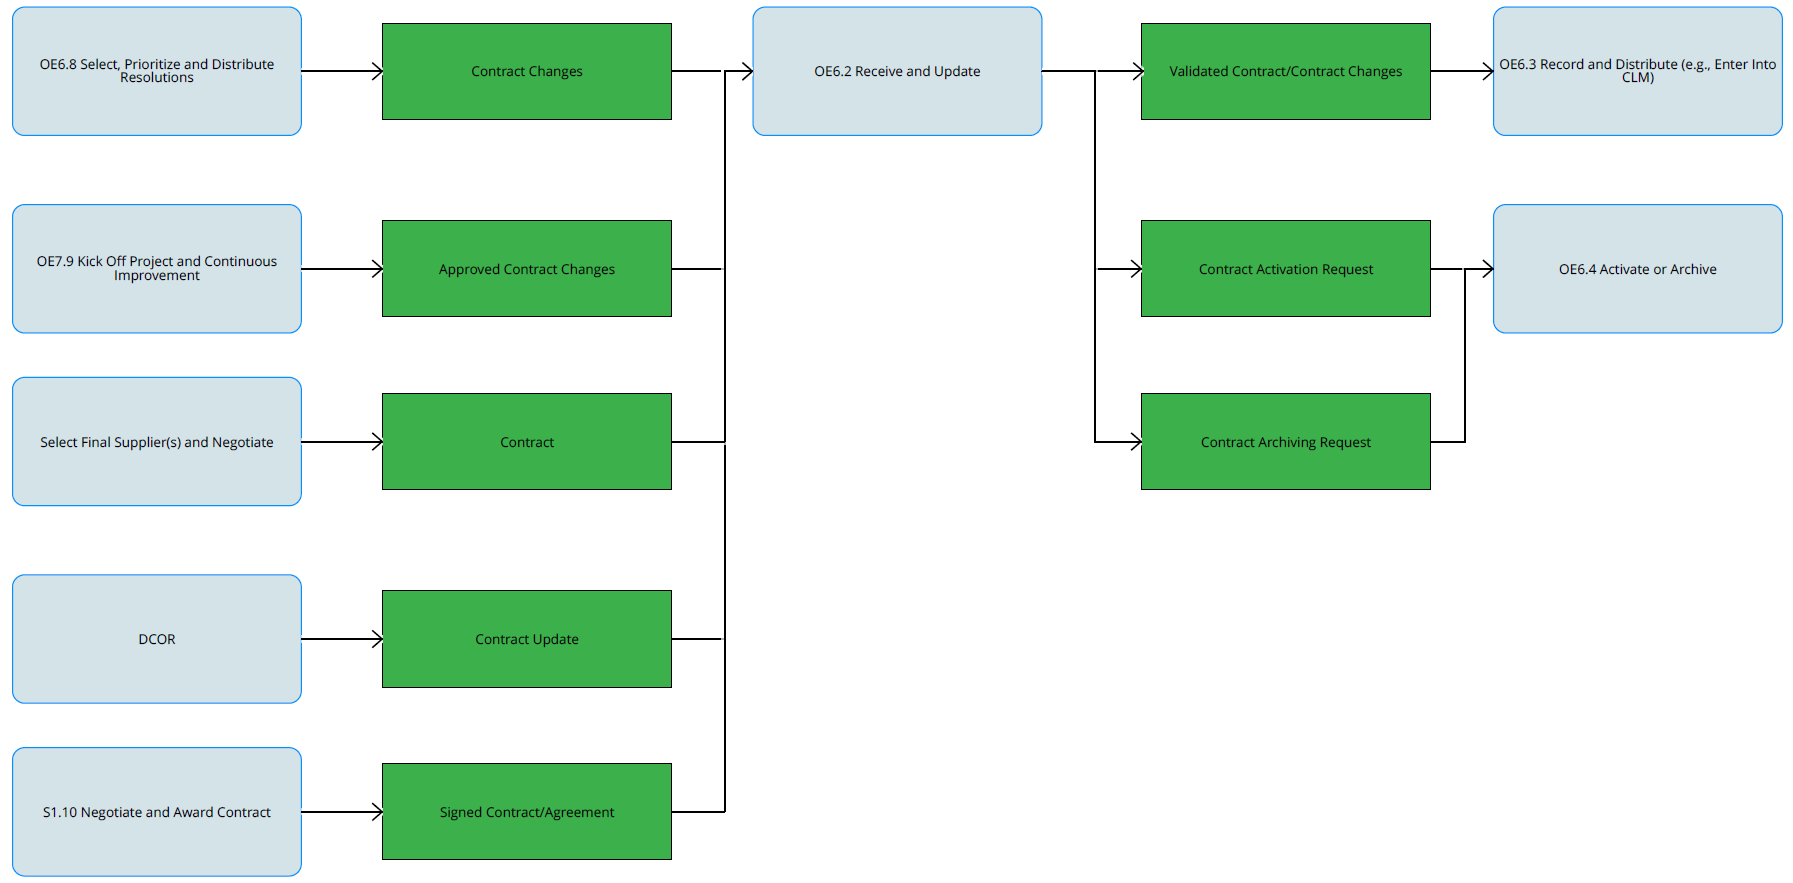
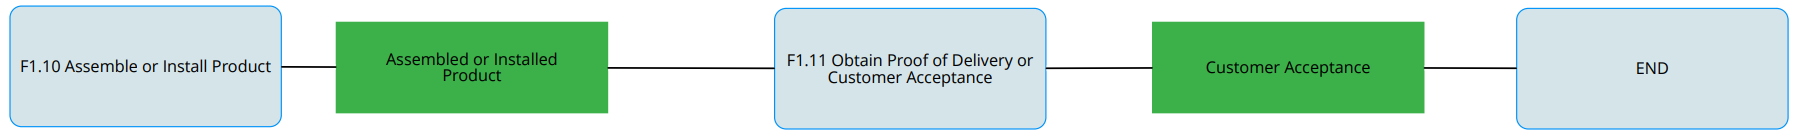

In [20]:
import requests
import re

js_url = "https://scor.ascm.org/scor/main.bd8cd64481d1f524223b.js"

js = requests.get(js_url).text

# استخراج أي URLs أو مسارات API موجودة داخل JavaScript
patterns = [
    r'https?://[^"\']+',
    r'["\'](/[^"\']*api[^"\']*)["\']',
    r'["\']([^"\']*api[^"\']*)["\']'
]

for pattern in patterns:
    results = re.findall(pattern, js, re.IGNORECASE)
    
    for result in results[:30]:
        print(result)

In [21]:
for pattern in patterns:
    results = re.findall(pattern, js, re.IGNORECASE)
    
    for result in results:
        if "api" in result.lower():
            print(result[:500])

https://angular.io/docs/ts/latest/api/common/index/NgFor-directive.html#!#change-propagation for more information.
https://angular.io/api/forms/
/api/user/current/permissions
/api/user/current/info
/api/files/
/api/scor/cache
































































ɵɵclassMapInterpolate1
ɵɵclassMapInterpolate2
ɵɵclassMapInterpolate3
ɵɵclassMapInterpolate4
ɵɵclassMapInterpolate5
ɵɵclassMapInterpolate6
ɵɵclassMapInterpolate7
ɵɵclassMapInterpolate8
ɵɵclassMapInterpolateV
ɵɵclassMapInterpolate1
ɵɵclassMapInterpolate2
ɵɵclassMapInterpolate3
ɵɵclassMapInterpolate4
ɵɵclassMapInterpolate5
ɵɵclassMapInterpolate6
ɵɵclassMapInterpolate7
ɵɵclassMapInterpolate8
ɵɵclassMapInterpolateV




































Locale data API: locale data undefined
. See https://angular.io/docs/ts/latest/api/common/index/NgFor-directive.html#!#change-propagation for more information.



















































































api
. \n    Suppo

In [22]:
api_results = []

for pattern in patterns:
    results = re.findall(pattern, js, re.IGNORECASE)
    
    for result in results:
        if "api" in result.lower():
            api_results.append(result)

for x in list(dict.fromkeys(api_results))[:20]:
    print(x[:500])

https://angular.io/docs/ts/latest/api/common/index/NgFor-directive.html#!#change-propagation for more information.
https://angular.io/api/forms/
/api/user/current/permissions
/api/user/current/info
/api/files/
/api/scor/cache
















In [23]:
import requests

api_url = "https://scor.ascm.org/api/scor/cache"

api_response = requests.get(api_url)

print("Status:", api_response.status_code)
print("Content-Type:", api_response.headers.get("Content-Type"))
print("Length:", len(api_response.text))
print(api_response.text[:1000])

Status: 200
Content-Type: application/json; charset=utf-8
Length: 7347451
{"chapters":[{"id":1,"name":"Processes","order":1,"tabs":[{"id":1,"name":"Introduction","order":1,"color":null,"hidden":false,"defaultSectionExternalId":null,"countItems":0},{"id":23,"name":"Orchestrate Supply Chain","order":2,"color":"#00558C","hidden":false,"defaultSectionExternalId":null,"countItems":13},{"id":5,"name":"Plan","order":3,"color":"#84BD00","hidden":false,"defaultSectionExternalId":null,"countItems":6},{"id":24,"name":"Order","order":4,"color":"#006B36","hidden":false,"defaultSectionExternalId":null,"countItems":3},{"id":6,"name":"Source","order":5,"color":"#5F259F","hidden":false,"defaultSectionExternalId":null,"countItems":4},{"id":25,"name":"Transform","order":6,"color":"#00A3AD","hidden":false,"defaultSectionExternalId":null,"countItems":3},{"id":26,"name":"Fulfill","order":7,"color":"#006B36","hidden":false,"defaultSectionExternalId":null,"countItems":3},{"id":9,"name":"Return","order":8,"col

In [24]:
data = api_response.json()

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['chapters', 'sections', 'sectionItems', 'sectionRelations', 'resources', 'broadcastMessages'])


In [25]:
for chapter in data["chapters"]:
    print(chapter["id"], "→", chapter["name"])

1 → Processes
2 → Performance
3 → People
4 → Practices


In [26]:
performance_chapters = [
    chapter 
    for chapter in data["chapters"]
    if "performance" in chapter["name"].lower()
]

print(performance_chapters)

[{'id': 2, 'name': 'Performance', 'order': 2, 'tabs': [{'id': 2, 'name': 'Introduction', 'order': 1, 'color': None, 'hidden': False, 'defaultSectionExternalId': None, 'countItems': 0}, {'id': 11, 'name': 'Reliability', 'order': 2, 'color': None, 'hidden': False, 'defaultSectionExternalId': 'RL.1.1', 'countItems': 0}, {'id': 12, 'name': 'Responsiveness', 'order': 3, 'color': None, 'hidden': False, 'defaultSectionExternalId': 'RS.1.1', 'countItems': 0}, {'id': 13, 'name': 'Agility', 'order': 4, 'color': None, 'hidden': False, 'defaultSectionExternalId': 'AG.1.1', 'countItems': 0}, {'id': 14, 'name': 'Cost', 'order': 5, 'color': None, 'hidden': False, 'defaultSectionExternalId': 'CO.1.1', 'countItems': 0}, {'id': 27, 'name': 'Profit', 'order': 6, 'color': None, 'hidden': False, 'defaultSectionExternalId': 'PR.1.1', 'countItems': 0}, {'id': 28, 'name': 'Assets', 'order': 7, 'color': None, 'hidden': False, 'defaultSectionExternalId': 'AM.1.1', 'countItems': 0}, {'id': 29, 'name': 'Environme

In [27]:
print(data.keys())

dict_keys(['chapters', 'sections', 'sectionItems', 'sectionRelations', 'resources', 'broadcastMessages'])


In [28]:
for key, value in data.items():
    if isinstance(value, list):
        print(key, "→ list →", len(value))
    elif isinstance(value, dict):
        print(key, "→ dict →", len(value))
    else:
        print(key, "→", type(value))

chapters → list → 4
sections → list → 1640
sectionItems → list → 4601
sectionRelations → list → 1561
resources → list → 2
broadcastMessages → list → 0


In [29]:
import json

text = json.dumps(data)

print("RL.1.1" in text)
print("RS.1.1" in text)
print("AG.1.1" in text)

True
True
True


In [30]:
reliability = [
    section
    for section in data["sections"]
    if section.get("externalId") == "RL.1.1"
]

print(reliability)

[{'id': 8296, 'externalId': 'RL.1.1', 'name': 'Perfect Customer Order Fulfillment', 'level': 1, 'menuItem': True, 'contentItem': False, 'emptyContent': False, 'generatedExternalId': False, 'tableOfContentsNeed': False, 'upperLevelSectionExternalIds': None, 'chapterTabId': 11, 'order': 8, 'url': '/performance/reliability/RL.1.1', 'absoluteUrl': None}]


In [31]:
responsiveness = [
    section
    for section in data["sections"]
    if section.get("externalId") == "RS.1.1"
]

print(responsiveness)

[{'id': 8372, 'externalId': 'RS.1.1', 'name': 'Customer Order Fulfillment Cycle Time', 'level': 1, 'menuItem': True, 'contentItem': False, 'emptyContent': False, 'generatedExternalId': False, 'tableOfContentsNeed': False, 'upperLevelSectionExternalIds': None, 'chapterTabId': 12, 'order': 16, 'url': '/performance/responsiveness/RS.1.1', 'absoluteUrl': None}]


In [32]:
print(data["sections"][0])

{'id': 7983, 'externalId': 'OE', 'name': 'Orchestrate Supply Chain', 'level': 0, 'menuItem': True, 'contentItem': False, 'emptyContent': False, 'generatedExternalId': False, 'tableOfContentsNeed': False, 'upperLevelSectionExternalIds': None, 'chapterTabId': 23, 'order': 0, 'url': '/processes/orchestrate supply chain/OE', 'absoluteUrl': None}


In [33]:
for section in data["sections"]:
    if "RL.1.1" in str(section):
        print(section)

{'id': 8296, 'externalId': 'RL.1.1', 'name': 'Perfect Customer Order Fulfillment', 'level': 1, 'menuItem': True, 'contentItem': False, 'emptyContent': False, 'generatedExternalId': False, 'tableOfContentsNeed': False, 'upperLevelSectionExternalIds': None, 'chapterTabId': 11, 'order': 8, 'url': '/performance/reliability/RL.1.1', 'absoluteUrl': None}


In [35]:
performance_tabs = {
    11: "Reliability",
    12: "Responsiveness",
    13: "Agility",
    14: "Cost",
    27: "Profit",
    28: "Assets",
    29: "Environmental",
    30: "Social"
}

In [36]:
performance_sections = [
    section
    for section in data["sections"]
    if section.get("chapterTabId") in performance_tabs
]

print("Number of Performance sections:", len(performance_sections))

Number of Performance sections: 366


In [37]:
for section in performance_sections[:20]:
    print(
        section["chapterTabId"],
        "|",
        performance_tabs[section["chapterTabId"]],
        "|",
        section["externalId"],
        "|",
        section["name"]
    )

11 | Reliability | RL.1.1 | Perfect Customer Order Fulfillment
11 | Reliability | RL.2.1 | Percentage of Orders Delivered In Full to the Customer
11 | Reliability | RL.2.2 | Delivery Performance to Original Customer Commit Date
11 | Reliability | RL.2.3 | Customer Order Documentation Accuracy
11 | Reliability | RL.2.4 | Customer Order Perfect Condition
11 | Reliability | RL.1.2 | Perfect Supplier Order Fulfillment
11 | Reliability | RL.2.5 | Percentage of Orders Delivered In Full from the Supplier
11 | Reliability | RL.2.6 | Delivery Performance to Original Supplier Commit Date
11 | Reliability | RL.2.7 | Supplier Order Documentation Accuracy
11 | Reliability | RL.2.8 | Supplier Order Perfect Condition
11 | Reliability | RL.1.3 | Perfect Return Order Fulfillment
11 | Reliability | RL.2.9 | On Time
11 | Reliability | RL.2.10 | In Full (Correct Product)
11 | Reliability | RL.2.11 | Correct Documentation
11 | Reliability | RL.2.12 | Perfect Condition
11 | Reliability | RL | Level-3 Metric

In [38]:
df_performance = pd.DataFrame([
    {
        "Performance_Attribute": performance_tabs[s["chapterTabId"]],
        "Metric_Code": s["externalId"],
        "Metric_Name": s["name"],
        "Level": s["level"],
        "URL": "https://scor.ascm.org" + s["url"]
    }
    for s in performance_sections
])

df_performance.head()

,Performance_Attribute,Metric_Code,Metric_Name,Level,URL
0,Reliability,RL.1.1,Perfect Customer Order Fulfillment,1,https://scor.ascm.org/performance/reliability/...
1,Reliability,RL.2.1,Percentage of Orders Delivered In Full to the ...,2,https://scor.ascm.org/performance/reliability/...
2,Reliability,RL.2.2,Delivery Performance to Original Customer Comm...,2,https://scor.ascm.org/performance/reliability/...
3,Reliability,RL.2.3,Customer Order Documentation Accuracy,2,https://scor.ascm.org/performance/reliability/...
4,Reliability,RL.2.4,Customer Order Perfect Condition,2,https://scor.ascm.org/performance/reliability/...


In [39]:
df_performance.to_csv(
    "SCOR_Performance_Metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

In [40]:
import requests
from bs4 import BeautifulSoup

url = "https://www.who.int/tools/quality-management-system-for-non-laboratory-settings/pillar-3--procurement-supply-chain-and-inventory-management"

response = requests.get(url)

print("Status:", response.status_code)
print("Length:", len(response.text))

Status: 200
Length: 90131


In [41]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.get_text(strip=True))

Pillar 3 - Procurement, supply chain and inventory management


In [42]:
print(soup.get_text(" ", strip=True)[:2000])

Pillar 3 - Procurement, supply chain and inventory management Skip to main content Global Regions WHO Regional websites Africa Americas South-East Asia Europe Eastern Mediterranean Western Pacific When autocomplete results are available use up and down arrows to review and enter to select. Select language Select language English Home Health Topics All topics A B C D E F G H I J K L M N O P Q R S T U V W X Y Z Resources Fact sheets Facts in pictures Multimedia Podcasts Publications Questions and answers Tools and toolkits Popular Dengue Endometriosis Excessive heat Herpes Mental disorders Mpox Countries All countries A B C D E F G H I J K L M N O P Q R S T U V W X Y Z Regions Africa Americas Europe Eastern Mediterranean South-East Asia Western Pacific WHO in countries Data by country Country presence Country cooperation strategies Country office profiles Strengthening country offices Newsroom Newsroom News releases Statements Campaigns Events Feature stories Speeches Commentaries Photo 

In [43]:
# البحث عن المحتوى الرئيسي
main = soup.find("main")

print(main is not None)

if main:
    print(main.get_text(" ", strip=True)[:3000])

False


In [44]:
for tag in soup.find_all(["div", "article", "section"]):
    text = tag.get_text(" ", strip=True)
    
    if "Procurement, supply chain and inventory management" in text:
        print("TAG:", tag.name)
        print("ID:", tag.get("id"))
        print("CLASS:", tag.get("class"))
        print("TEXT LENGTH:", len(text))
        print()

TAG: div
ID: None
CLASS: ['sf-main-site', 'main-site', 'main']
TEXT LENGTH: 9141

TAG: section
ID: content
CLASS: ['sf-content', 'content']
TEXT LENGTH: 6558

TAG: div
ID: PageContent_TA51A0481002_Col00
CLASS: ['sf_colsIn', 'container']
TEXT LENGTH: 144

TAG: div
ID: None
CLASS: ['row']
TEXT LENGTH: 6413

TAG: div
ID: PageContent_TA51A0481001_Col00
CLASS: ['sf_colsIn', 'col-md-12']
TEXT LENGTH: 6413

TAG: div
ID: PageContent_C001_Col00
CLASS: ['sf_colsIn', 'container']
TEXT LENGTH: 6413

TAG: div
ID: None
CLASS: ['section-heading']
TEXT LENGTH: 50

TAG: div
ID: None
CLASS: ['row']
TEXT LENGTH: 6362

TAG: div
ID: PageContent_C003_Col00
CLASS: ['sf_colsIn', 'col-md-3']
TEXT LENGTH: 405

TAG: div
ID: 9921bce00c144e15a6262364a4d346e6
CLASS: ['left-navigation--wrapper', 'accordion']
TEXT LENGTH: 405

TAG: div
ID: sidebar
CLASS: ['sf-sidebar', 'sidebar']
TEXT LENGTH: 386

TAG: div
ID: None
CLASS: ['sidebar__inner']
TEXT LENGTH: 386



In [45]:
content = soup.find("section", id="content")

print(content is not None)

True


In [46]:
content_text = content.get_text(" ", strip=True)

print(content_text[:4000])

Home / Tools and toolkits / Quality Management System for non-laboratory settings / Pillar 3: Procurement, supply chain and inventory management Procurement, supply chain and inventory management Section navigation Quality Management System for non-laboratory settings Pillar 3: Procurement, supply chain and inventory management Pillar 1: Organization, governance, planning Pillar 2: Worforce development QMS training modules Pillar 5: Documents and records Pillar 4: Process control, assessment and continuous quality improvement Pillar 6: Post-market surveillance of IVDs in non-laboratory settings Effective procurement, supply chain, and inventory management, from central level to testing sites, is essential to ensure that quality assured products are available when and where needed, preventing interruptions in testing services and wastage of tests and other testing materials. A well-managed supply chain can quickly adapt to changes in demand, such as during an outbreak, ensuring a rapid 

In [47]:
paragraphs = content.find_all(["p", "li"])

demand_keywords = [
    "forecast",
    "forecasting",
    "quantification",
    "future needs",
    "historical usage",
    "seasonal trends",
    "health threats",
    "demand"
]

demand_paragraphs = []

for p in paragraphs:
    text = p.get_text(" ", strip=True)
    
    if any(keyword.lower() in text.lower() for keyword in demand_keywords):
        demand_paragraphs.append(text)

print("Number of relevant paragraphs:", len(demand_paragraphs))

Number of relevant paragraphs: 5


In [48]:
for i, text in enumerate(demand_paragraphs, 1):
    print(f"\n--- {i} ---")
    print(text)


--- 1 ---
Effective procurement, supply chain, and inventory management, from central level to testing sites, is essential to ensure that quality assured products are available when and where needed, preventing interruptions in testing services and wastage of tests and other testing materials. A well-managed supply chain can quickly adapt to changes in demand, such as during an outbreak, ensuring a rapid response.

--- 2 ---
At the central level, supply chain management involves identification of country needs (forecasting, quantification), supplier selection, ordering, and inventory management (see also Pillar 1: Organization, governance, planning ).

--- 3 ---
National forecasting, quantification, and distribution : The central level calculates/anticipates future needs based on historical usage patterns, seasonal trends, and emerging health threats, allowing for proactive procurement and planning. The central level develops procurement and distribution plans. It includes a logistics

In [49]:
import pandas as pd

who_demand_benchmark = pd.DataFrame([
    {
        "Benchmark_ID": "WHO_DP_01",
        "Process_Area": "Forecasting",
        "Best_Practice": "Calculate and anticipate future needs",
        "Required_Data": "Historical usage patterns",
        "Source": "WHO"
    },
    {
        "Benchmark_ID": "WHO_DP_02",
        "Process_Area": "Forecasting",
        "Best_Practice": "Consider seasonal trends when forecasting",
        "Required_Data": "Seasonal trends",
        "Source": "WHO"
    },
    {
        "Benchmark_ID": "WHO_DP_03",
        "Process_Area": "Forecasting",
        "Best_Practice": "Consider emerging health threats when forecasting",
        "Required_Data": "Emerging health threats",
        "Source": "WHO"
    },
    {
        "Benchmark_ID": "WHO_DP_04",
        "Process_Area": "Quantification",
        "Best_Practice": "Estimate quantities required to meet needs",
        "Required_Data": "Historical data, population needs, consumption patterns",
        "Source": "WHO"
    },
    {
        "Benchmark_ID": "WHO_DP_05",
        "Process_Area": "Quantification",
        "Best_Practice": "Forecast and quantify site needs",
        "Required_Data": "Site needs, consumption and stock information",
        "Source": "WHO"
    }
])

who_demand_benchmark

,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Source
0,WHO_DP_01,Forecasting,Calculate and anticipate future needs,Historical usage patterns,WHO
1,WHO_DP_02,Forecasting,Consider seasonal trends when forecasting,Seasonal trends,WHO
2,WHO_DP_03,Forecasting,Consider emerging health threats when forecasting,Emerging health threats,WHO
3,WHO_DP_04,Quantification,Estimate quantities required to meet needs,"Historical data, population needs, consumption...",WHO
4,WHO_DP_05,Quantification,Forecast and quantify site needs,"Site needs, consumption and stock information",WHO


In [50]:
who_demand_benchmark["Source_URL"] = url

In [51]:
evidence = [
    "The central level calculates/anticipates future needs based on historical usage patterns.",
    "The central level calculates/anticipates future needs based on seasonal trends.",
    "The central level calculates/anticipates future needs based on emerging health threats.",
    "Estimate the quantities of commodities required based on historical data, population needs, and consumption pattern.",
    "The testing site must forecast and quantify its needs."
]

who_demand_benchmark["Evidence"] = evidence

In [52]:
who_demand_benchmark

,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Source,Source_URL,Evidence
0,WHO_DP_01,Forecasting,Calculate and anticipate future needs,Historical usage patterns,WHO,https://www.who.int/tools/quality-management-s...,The central level calculates/anticipates futur...
1,WHO_DP_02,Forecasting,Consider seasonal trends when forecasting,Seasonal trends,WHO,https://www.who.int/tools/quality-management-s...,The central level calculates/anticipates futur...
2,WHO_DP_03,Forecasting,Consider emerging health threats when forecasting,Emerging health threats,WHO,https://www.who.int/tools/quality-management-s...,The central level calculates/anticipates futur...
3,WHO_DP_04,Quantification,Estimate quantities required to meet needs,"Historical data, population needs, consumption...",WHO,https://www.who.int/tools/quality-management-s...,Estimate the quantities of commodities require...
4,WHO_DP_05,Quantification,Forecast and quantify site needs,"Site needs, consumption and stock information",WHO,https://www.who.int/tools/quality-management-s...,The testing site must forecast and quantify it...


In [53]:
who_demand_benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Benchmark_ID   5 non-null      str  
 1   Process_Area   5 non-null      str  
 2   Best_Practice  5 non-null      str  
 3   Required_Data  5 non-null      str  
 4   Source         5 non-null      str  
 5   Source_URL     5 non-null      str  
 6   Evidence       5 non-null      str  
dtypes: str(7)
memory usage: 412.0 bytes


In [54]:
who_demand_benchmark.to_csv(
    "WHO_Demand_Planning_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

In [55]:
import requests

pdf_url = "https://cdn.who.int/media/docs/default-source/hq-hiv-hepatitis-and-stis-library/qms-toolkit/3.1-define-site-needs--buffer-and-alert-stocks-and-calculate-quantity-to-order.pdf"

pdf_response = requests.get(pdf_url)

print("Status:", pdf_response.status_code)
print("Size:", len(pdf_response.content))

Status: 200
Size: 230774


In [56]:
with open("WHO_Demand_Planning_Order_Quantity.pdf", "wb") as f:
    f.write(pdf_response.content)

print("PDF downloaded successfully")

PDF downloaded successfully


In [58]:
from pypdf import PdfReader

reader = PdfReader("WHO_Demand_Planning_Order_Quantity.pdf")

print("Pages:", len(reader.pages))

Pages: 3


In [59]:
pdf_text = ""

for page in reader.pages:
    text = page.extract_text()
    
    if text:
        pdf_text += text + "\n"

print(pdf_text[:5000])

 
  
_______________________________________________________ 
 
Quality Management Systems for  
non-laboratory settings – Toolkit 
 
 
Define site needs, buffer and alert stocks and 
calculate quantity to order 

Define site needs, buffer and alert stocks and calculate quantity to 
order 
Quantification involves estimating the quantities of tests and other materials needed to satisfy 
demand over a specified period.  
The required quantities of testing commodities are influenced by factors such as population 
size, disease prevalence, health programs, and the nature of the intervention. To assess these 
requirements, the site supervisor works together with various site staff members (testing 
providers, pharmacists, stock managers) to review historical data, population needs (including 
population size and disease prevalence), past consumption trends, and both current and 
anticipated types of activities. To note that when quantifying commodities for seasonal disease, 
for example mal

In [60]:
print("Pages:", len(reader.pages))

Pages: 3


In [61]:
pdf_text = ""

for i, page in enumerate(reader.pages, 1):
    text = page.extract_text()
    
    print(f"\n===== PAGE {i} =====")
    print(text[:3000])
    
    if text:
        pdf_text += text + "\n"


===== PAGE 1 =====
 
  
_______________________________________________________ 
 
Quality Management Systems for  
non-laboratory settings – Toolkit 
 
 
Define site needs, buffer and alert stocks and 
calculate quantity to order 


===== PAGE 2 =====
Define site needs, buffer and alert stocks and calculate quantity to 
order 
Quantification involves estimating the quantities of tests and other materials needed to satisfy 
demand over a specified period.  
The required quantities of testing commodities are influenced by factors such as population 
size, disease prevalence, health programs, and the nature of the intervention. To assess these 
requirements, the site supervisor works together with various site staff members (testing 
providers, pharmacists, stock managers) to review historical data, population needs (including 
population size and disease prevalence), past consumption trends, and both current and 
anticipated types of activities. To note that when quantifying commoditie

In [62]:
who_pdf_benchmark = pd.DataFrame([
    {
        "Benchmark_ID": "WHO_DP_06",
        "Process_Area": "Quantification",
        "Best_Practice": "Use historical data, population needs and consumption trends to estimate required quantities",
        "Required_Data": "Historical data; population size; disease prevalence; consumption trends",
        "Metric": "Forecast/Quantification",
        "Formula": None,
        "Source": "WHO QMS Toolkit"
    },
    
    {
        "Benchmark_ID": "WHO_DP_07",
        "Process_Area": "Forecasting",
        "Best_Practice": "Consider seasonal disease patterns when estimating demand",
        "Required_Data": "Peak-season and non-peak consumption",
        "Metric": "Seasonal AMC",
        "Formula": None,
        "Source": "WHO QMS Toolkit"
    },
    
    {
        "Benchmark_ID": "WHO_DP_08",
        "Process_Area": "Consumption",
        "Best_Practice": "Calculate Average Monthly Consumption using a representative period",
        "Required_Data": "Total consumption; number of months",
        "Metric": "AMC",
        "Formula": "Total Consumption / Number of Months",
        "Source": "WHO QMS Toolkit"
    },
    
    {
        "Benchmark_ID": "WHO_DP_09",
        "Process_Area": "Inventory Planning",
        "Best_Practice": "Maintain buffer stock to protect against demand fluctuations and supply disruptions",
        "Required_Data": "Average lead time; AMC",
        "Metric": "Buffer Stock",
        "Formula": "Average Lead Time × AMC",
        "Source": "WHO QMS Toolkit"
    },
    
    {
        "Benchmark_ID": "WHO_DP_10",
        "Process_Area": "Reordering",
        "Best_Practice": "Define an alert stock level that triggers an emergency order",
        "Required_Data": "AMC; lead time; buffer stock",
        "Metric": "Alert Stock Level",
        "Formula": "AMC × Lead Time + Buffer Stock",
        "Source": "WHO QMS Toolkit"
    },
    
    {
        "Benchmark_ID": "WHO_DP_11",
        "Process_Area": "Ordering",
        "Best_Practice": "Calculate quantity to order based on expected coverage, lead time, buffer stock and current stock",
        "Required_Data": "AMC; months to cover; lead time; buffer stock; current stock",
        "Metric": "Quantity to Order",
        "Formula": "AMC × (Months to Cover + Lead Time) + Buffer Stock - Current Stock",
        "Source": "WHO QMS Toolkit"
    },
    
    {
        "Benchmark_ID": "WHO_DP_12",
        "Process_Area": "Expiry Management",
        "Best_Practice": "Review shelf life and AMC to ensure products are used before expiry",
        "Required_Data": "Shelf life; AMC; current stock",
        "Metric": "Expiry Risk",
        "Formula": None,
        "Source": "WHO QMS Toolkit"
    }
])

In [63]:
who_pdf_benchmark

,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Metric,Formula,Source
0,WHO_DP_06,Quantification,"Use historical data, population needs and cons...",Historical data; population size; disease prev...,Forecast/Quantification,NaN,WHO QMS Toolkit
1,WHO_DP_07,Forecasting,Consider seasonal disease patterns when estima...,Peak-season and non-peak consumption,Seasonal AMC,NaN,WHO QMS Toolkit
2,WHO_DP_08,Consumption,Calculate Average Monthly Consumption using a ...,Total consumption; number of months,AMC,Total Consumption / Number of Months,WHO QMS Toolkit
3,WHO_DP_09,Inventory Planning,Maintain buffer stock to protect against deman...,Average lead time; AMC,Buffer Stock,Average Lead Time × AMC,WHO QMS Toolkit
4,WHO_DP_10,Reordering,Define an alert stock level that triggers an e...,AMC; lead time; buffer stock,Alert Stock Level,AMC × Lead Time + Buffer Stock,WHO QMS Toolkit
5,WHO_DP_11,Ordering,Calculate quantity to order based on expected ...,AMC; months to cover; lead time; buffer stock;...,Quantity to Order,AMC × (Months to Cover + Lead Time) + Buffer S...,WHO QMS Toolkit
6,WHO_DP_12,Expiry Management,Review shelf life and AMC to ensure products a...,Shelf life; AMC; current stock,Expiry Risk,NaN,WHO QMS Toolkit


In [64]:
print("Rows:", len(who_pdf_benchmark))
print("Columns:", who_pdf_benchmark.columns.tolist())

Rows: 7
Columns: ['Benchmark_ID', 'Process_Area', 'Best_Practice', 'Required_Data', 'Metric', 'Formula', 'Source']


In [65]:
who_demand_benchmark

,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Source,Source_URL,Evidence
0,WHO_DP_01,Forecasting,Calculate and anticipate future needs,Historical usage patterns,WHO,https://www.who.int/tools/quality-management-s...,The central level calculates/anticipates futur...
1,WHO_DP_02,Forecasting,Consider seasonal trends when forecasting,Seasonal trends,WHO,https://www.who.int/tools/quality-management-s...,The central level calculates/anticipates futur...
2,WHO_DP_03,Forecasting,Consider emerging health threats when forecasting,Emerging health threats,WHO,https://www.who.int/tools/quality-management-s...,The central level calculates/anticipates futur...
3,WHO_DP_04,Quantification,Estimate quantities required to meet needs,"Historical data, population needs, consumption...",WHO,https://www.who.int/tools/quality-management-s...,Estimate the quantities of commodities require...
4,WHO_DP_05,Quantification,Forecast and quantify site needs,"Site needs, consumption and stock information",WHO,https://www.who.int/tools/quality-management-s...,The testing site must forecast and quantify it...


In [66]:
who_pdf_benchmark

,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Metric,Formula,Source
0,WHO_DP_06,Quantification,"Use historical data, population needs and cons...",Historical data; population size; disease prev...,Forecast/Quantification,NaN,WHO QMS Toolkit
1,WHO_DP_07,Forecasting,Consider seasonal disease patterns when estima...,Peak-season and non-peak consumption,Seasonal AMC,NaN,WHO QMS Toolkit
2,WHO_DP_08,Consumption,Calculate Average Monthly Consumption using a ...,Total consumption; number of months,AMC,Total Consumption / Number of Months,WHO QMS Toolkit
3,WHO_DP_09,Inventory Planning,Maintain buffer stock to protect against deman...,Average lead time; AMC,Buffer Stock,Average Lead Time × AMC,WHO QMS Toolkit
4,WHO_DP_10,Reordering,Define an alert stock level that triggers an e...,AMC; lead time; buffer stock,Alert Stock Level,AMC × Lead Time + Buffer Stock,WHO QMS Toolkit
5,WHO_DP_11,Ordering,Calculate quantity to order based on expected ...,AMC; months to cover; lead time; buffer stock;...,Quantity to Order,AMC × (Months to Cover + Lead Time) + Buffer S...,WHO QMS Toolkit
6,WHO_DP_12,Expiry Management,Review shelf life and AMC to ensure products a...,Shelf life; AMC; current stock,Expiry Risk,NaN,WHO QMS Toolkit


In [67]:
who_demand_final = pd.concat(
    [who_demand_benchmark, who_pdf_benchmark],
    ignore_index=True
)

In [68]:
who_demand_final

,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Source,Source_URL,Evidence,Metric,Formula
0,WHO_DP_01,Forecasting,Calculate and anticipate future needs,Historical usage patterns,WHO,https://www.who.int/tools/quality-management-s...,The central level calculates/anticipates futur...,NaN,NaN
1,WHO_DP_02,Forecasting,Consider seasonal trends when forecasting,Seasonal trends,WHO,https://www.who.int/tools/quality-management-s...,The central level calculates/anticipates futur...,NaN,NaN
2,WHO_DP_03,Forecasting,Consider emerging health threats when forecasting,Emerging health threats,WHO,https://www.who.int/tools/quality-management-s...,The central level calculates/anticipates futur...,NaN,NaN
3,WHO_DP_04,Quantification,Estimate quantities required to meet needs,"Historical data, population needs, consumption...",WHO,https://www.who.int/tools/quality-management-s...,Estimate the quantities of commodities require...,NaN,NaN
4,WHO_DP_05,Quantification,Forecast and quantify site needs,"Site needs, consumption and stock information",WHO,https://www.who.int/tools/quality-management-s...,The testing site must forecast and quantify it...,NaN,NaN
5,WHO_DP_06,Quantification,"Use historical data, population needs and cons...",Historical data; population size; disease prev...,WHO QMS Toolkit,NaN,NaN,Forecast/Quantification,NaN
6,WHO_DP_07,Forecasting,Consider seasonal disease patterns when estima...,Peak-season and non-peak consumption,WHO QMS Toolkit,NaN,NaN,Seasonal AMC,NaN
7,WHO_DP_08,Consumption,Calculate Average Monthly Consumption using a ...,Total consumption; number of months,WHO QMS Toolkit,NaN,NaN,AMC,Total Consumption / Number of Months
8,WHO_DP_09,Inventory Planning,Maintain buffer stock to protect against deman...,Average lead time; AMC,WHO QMS Toolkit,NaN,NaN,Buffer Stock,Average Lead Time × AMC
9,WHO_DP_10,Reordering,Define an alert stock level that triggers an e...,AMC; lead time; buffer stock,WHO QMS Toolkit,NaN,NaN,Alert Stock Level,AMC × Lead Time + Buffer Stock


In [69]:
who_demand_final["Source_Type"] = "WHO"

In [70]:
who_demand_final.loc[
    who_demand_final["Benchmark_ID"].isin(
        ["WHO_DP_01", "WHO_DP_02", "WHO_DP_03", "WHO_DP_04", "WHO_DP_05"]
    ),
    "Source_Type"
] = "WHO Web Page"

who_demand_final.loc[
    who_demand_final["Benchmark_ID"].isin(
        ["WHO_DP_06", "WHO_DP_07", "WHO_DP_08",
         "WHO_DP_09", "WHO_DP_10", "WHO_DP_11", "WHO_DP_12"]
    ),
    "Source_Type"
] = "WHO QMS Toolkit"

In [71]:
who_demand_final["Source_URL"] = url

In [72]:
pdf_url = "https://cdn.who.int/media/docs/default-source/hq-hiv-hepatitis-and-stis-library/qms-toolkit/3.1-define-site-needs--buffer-and-alert-stocks-and-calculate-quantity-to-order.pdf"

In [73]:
who_demand_final.loc[
    who_demand_final["Source_Type"] == "WHO QMS Toolkit",
    "Source_URL"
] = pdf_url

In [74]:
who_demand_final.to_csv(
    "WHO_Demand_Planning_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [75]:
who_demand_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Benchmark_ID   12 non-null     str  
 1   Process_Area   12 non-null     str  
 2   Best_Practice  12 non-null     str  
 3   Required_Data  12 non-null     str  
 4   Source         12 non-null     str  
 5   Source_URL     12 non-null     str  
 6   Evidence       5 non-null      str  
 7   Metric         7 non-null      str  
 8   Formula        4 non-null      str  
 9   Source_Type    12 non-null     str  
dtypes: str(10)
memory usage: 1.1 KB


In [76]:
who_demand_final.isnull().sum()


Benchmark_ID     0
Process_Area     0
Best_Practice    0
Required_Data    0
Source           0
Source_URL       0
Evidence         7
Metric           5
Formula          8
Source_Type      0
dtype: int64

In [77]:
who_demand_final[["Benchmark_ID", "Process_Area", "Best_Practice", "Metric", "Formula"]]

,Benchmark_ID,Process_Area,Best_Practice,Metric,Formula
0,WHO_DP_01,Forecasting,Calculate and anticipate future needs,NaN,NaN
1,WHO_DP_02,Forecasting,Consider seasonal trends when forecasting,NaN,NaN
2,WHO_DP_03,Forecasting,Consider emerging health threats when forecasting,NaN,NaN
3,WHO_DP_04,Quantification,Estimate quantities required to meet needs,NaN,NaN
4,WHO_DP_05,Quantification,Forecast and quantify site needs,NaN,NaN
5,WHO_DP_06,Quantification,"Use historical data, population needs and cons...",Forecast/Quantification,NaN
6,WHO_DP_07,Forecasting,Consider seasonal disease patterns when estima...,Seasonal AMC,NaN
7,WHO_DP_08,Consumption,Calculate Average Monthly Consumption using a ...,AMC,Total Consumption / Number of Months
8,WHO_DP_09,Inventory Planning,Maintain buffer stock to protect against deman...,Buffer Stock,Average Lead Time × AMC
9,WHO_DP_10,Reordering,Define an alert stock level that triggers an e...,Alert Stock Level,AMC × Lead Time + Buffer Stock


In [78]:
who_demand_final["Benchmark_Type"] = None

In [79]:
who_demand_final.loc[
    who_demand_final["Benchmark_ID"].isin(
        ["WHO_DP_01", "WHO_DP_02", "WHO_DP_03",
         "WHO_DP_04", "WHO_DP_05"]
    ),
    "Benchmark_Type"
] = "Principle"

In [80]:
who_demand_final.loc[
    who_demand_final["Benchmark_ID"].isin(
        ["WHO_DP_06", "WHO_DP_07", "WHO_DP_12"]
    ),
    "Benchmark_Type"
] = "Practice"

In [81]:
who_demand_final.loc[
    who_demand_final["Benchmark_ID"].isin(
        ["WHO_DP_08", "WHO_DP_09",
         "WHO_DP_10", "WHO_DP_11"]
    ),
    "Benchmark_Type"
] = "Metric"

In [82]:
priority_map = {
    "WHO_DP_01": "High",
    "WHO_DP_02": "High",
    "WHO_DP_03": "Medium",
    "WHO_DP_04": "High",
    "WHO_DP_05": "High",
    "WHO_DP_06": "High",
    "WHO_DP_07": "High",
    "WHO_DP_08": "Critical",
    "WHO_DP_09": "Critical",
    "WHO_DP_10": "Critical",
    "WHO_DP_11": "Critical",
    "WHO_DP_12": "High"
}

who_demand_final["Priority"] = who_demand_final["Benchmark_ID"].map(priority_map)

In [83]:
who_demand_final[
    [
        "Benchmark_ID",
        "Process_Area",
        "Benchmark_Type",
        "Priority",
        "Metric",
        "Formula"
    ]
]

,Benchmark_ID,Process_Area,Benchmark_Type,Priority,Metric,Formula
0,WHO_DP_01,Forecasting,Principle,High,NaN,NaN
1,WHO_DP_02,Forecasting,Principle,High,NaN,NaN
2,WHO_DP_03,Forecasting,Principle,Medium,NaN,NaN
3,WHO_DP_04,Quantification,Principle,High,NaN,NaN
4,WHO_DP_05,Quantification,Principle,High,NaN,NaN
5,WHO_DP_06,Quantification,Practice,High,Forecast/Quantification,NaN
6,WHO_DP_07,Forecasting,Practice,High,Seasonal AMC,NaN
7,WHO_DP_08,Consumption,Metric,Critical,AMC,Total Consumption / Number of Months
8,WHO_DP_09,Inventory Planning,Metric,Critical,Buffer Stock,Average Lead Time × AMC
9,WHO_DP_10,Reordering,Metric,Critical,Alert Stock Level,AMC × Lead Time + Buffer Stock


In [84]:
who_demand_final.to_csv(
    "WHO_Demand_Planning_Benchmark_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("WHO Benchmark v2 saved successfully!")

WHO Benchmark v2 saved successfully!


In [85]:
import requests
from bs4 import BeautifulSoup

who_url = "https://www.who.int/teams/health-product-policy-and-standards/medicines-selection-ip-and-affordability/medicines-policy/medicines-supply/procurement-of-medicines"

response = requests.get(who_url)

print("Status:", response.status_code)
print("Length:", len(response.text))

Status: 200
Length: 246940


In [86]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.get_text(strip=True))

Health products policy and standards


In [87]:
for tag in soup.find_all(["div", "section"]):
    text = tag.get_text(" ", strip=True)

    if "Procurement of medicines" in text:
        print("TAG:", tag.name)
        print("ID:", tag.get("id"))
        print("CLASS:", tag.get("class"))
        print("TEXT LENGTH:", len(text))

TAG: div
ID: None
CLASS: ['sf-main-site', 'main-site', 'main']
TEXT LENGTH: 4577
TAG: section
ID: content
CLASS: ['sf-content', 'content']
TEXT LENGTH: 1994
TAG: div
ID: PageContent_TD76DC2B8003_Col00
CLASS: ['sf_colsIn', 'container']
TEXT LENGTH: 1595
TAG: div
ID: None
CLASS: ['row']
TEXT LENGTH: 1595
TAG: div
ID: PageContent_TA60FDAEF017_Col00
CLASS: ['sf_colsIn', 'col-md-3']
TEXT LENGTH: 24
TAG: div
ID: None
CLASS: None
TEXT LENGTH: 24
TAG: div
ID: None
CLASS: ['nav-item-wrap', 'active']
TEXT LENGTH: 24
TAG: div
ID: PageContent_TA60FDAEF017_Col01
CLASS: ['sf_colsIn', 'col-md-9']
TEXT LENGTH: 1570
TAG: div
ID: None
CLASS: ['row']
TEXT LENGTH: 1570
TAG: div
ID: PageContent_C002_Col00
CLASS: ['sf_colsIn', 'col-md-12']
TEXT LENGTH: 1570
TAG: div
ID: None
CLASS: ['section-heading']
TEXT LENGTH: 24


In [88]:
procurement_keywords = [
    "procurement",
    "supplier",
    "selection",
    "qualification",
    "tender",
    "competitive",
    "price",
    "quality",
    "quantity",
    "delivery",
    "contract",
    "purchase",
    "order"
]

In [89]:
paragraphs = content.find_all(["p", "li"])

procurement_paragraphs = []

for p in paragraphs:
    text = p.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in procurement_keywords
    ):
        procurement_paragraphs.append(text)

print("Relevant paragraphs:", len(procurement_paragraphs))

Relevant paragraphs: 17


In [90]:
for i, text in enumerate(procurement_paragraphs, 1):
    print(f"\n--- {i} ---")
    print(text)


--- 1 ---
Quality Management System for non-laboratory settings /

--- 2 ---
Pillar 3: Procurement, supply chain and inventory management

--- 3 ---
Quality Management System for non-laboratory settings

--- 4 ---
Pillar 3: Procurement, supply chain and inventory management

--- 5 ---
Pillar 4: Process control, assessment and continuous quality improvement

--- 6 ---
Effective procurement, supply chain, and inventory management, from central level to testing sites, is essential to ensure that quality assured products are available when and where needed, preventing interruptions in testing services and wastage of tests and other testing materials. A well-managed supply chain can quickly adapt to changes in demand, such as during an outbreak, ensuring a rapid response.

--- 7 ---
At the central level, supply chain management involves identification of country needs (forecasting, quantification), supplier selection, ordering, and inventory management (see also Pillar 1: Organization, gov

In [91]:
data

{'chapters': [{'id': 1,
   'name': 'Processes',
   'order': 1,
   'tabs': [{'id': 1,
     'name': 'Introduction',
     'order': 1,
     'color': None,
     'hidden': False,
     'defaultSectionExternalId': None,
     'countItems': 0},
    {'id': 23,
     'name': 'Orchestrate Supply Chain',
     'order': 2,
     'color': '#00558C',
     'hidden': False,
     'defaultSectionExternalId': None,
     'countItems': 13},
    {'id': 5,
     'name': 'Plan',
     'order': 3,
     'color': '#84BD00',
     'hidden': False,
     'defaultSectionExternalId': None,
     'countItems': 6},
    {'id': 24,
     'name': 'Order',
     'order': 4,
     'color': '#006B36',
     'hidden': False,
     'defaultSectionExternalId': None,
     'countItems': 3},
    {'id': 6,
     'name': 'Source',
     'order': 5,
     'color': '#5F259F',
     'hidden': False,
     'defaultSectionExternalId': None,
     'countItems': 4},
    {'id': 25,
     'name': 'Transform',
     'order': 6,
     'color': '#00A3AD',
     'hidden

In [92]:
search_words = [
    "procurement",
    "supplier",
    "selection",
    "ordering",
    "purchase",
    "delivery",
    "receipt"
]

matches = []

for section in data["sections"]:
    text = str(section).lower()

    if any(word in text for word in search_words):
        matches.append(section)

print("Matches:", len(matches))

Matches: 132


In [93]:
for item in matches[:20]:
    print(item)

{'id': 8137, 'externalId': 'O1.5', 'name': 'Generate Receipt and Shipping Date', 'level': 2, 'menuItem': True, 'contentItem': False, 'emptyContent': False, 'generatedExternalId': False, 'tableOfContentsNeed': False, 'upperLevelSectionExternalIds': None, 'chapterTabId': 24, 'order': 3, 'url': '/processes/order/O1.5', 'absoluteUrl': None}
{'id': 8138, 'externalId': 'O1.6', 'name': 'Receipt and Process Cancellation', 'level': 2, 'menuItem': True, 'contentItem': False, 'emptyContent': False, 'generatedExternalId': False, 'tableOfContentsNeed': False, 'upperLevelSectionExternalIds': None, 'chapterTabId': 24, 'order': 3, 'url': '/processes/order/O1.6', 'absoluteUrl': None}
{'id': 8160, 'externalId': 'S1.4', 'name': 'Pre-procurement Market Testing', 'level': 2, 'menuItem': True, 'contentItem': False, 'emptyContent': False, 'generatedExternalId': False, 'tableOfContentsNeed': False, 'upperLevelSectionExternalIds': None, 'chapterTabId': 6, 'order': 3, 'url': '/processes/source/S1.4', 'absoluteU

In [94]:
source_sections = [
    s for s in data["sections"]
    if s.get("chapterTabId") == 6
]

print("Source sections:", len(source_sections))

Source sections: 34


In [95]:
for s in source_sections:
    print(
        s.get("externalId"),
        "|",
        s.get("name"),
        "|",
        s.get("url")
    )

S | Source | /processes/source/S
S1 | Strategic Source | /processes/source/S1
S1.1 | Define Business Need | /processes/source/S1.1
S1.2 | Conduct Supply Market Analysis | /processes/source/S1.2
S1.3 | Develop Sourcing Strategy | /processes/source/S1.3
S1.4 | Pre-procurement Market Testing | /processes/source/S1.4
S1.5 | Source the Supply Market | /processes/source/S1.5
S1.6 | Prequalify Suppliers | /processes/source/S1.6
S1.7 | Determine Level of Collaboration Arrangement | /processes/source/S1.7
S1.8 | Invite to Tender/Request for Quotation | /processes/source/S1.8
S1.9 | Analyze Offers and Select Suppliers | /processes/source/S1.9
S1.10 | Negotiate and Award Contract | /processes/source/S1.10
S2 | Direct Procure | /processes/source/S2
S2.1 | Establish Order Signal | /processes/source/S2.1
S2.2 | Schedule Product Delivery | /processes/source/S2.2
S2.3 | Manage Inbound Transport | /processes/source/S2.3
S2.4 | Receive Product | /processes/source/S2.4
S2.5 | Inspect and Verify | /proces

In [96]:
print("Status:", response.status_code)
print("Length:", len(response.text))

Status: 200
Length: 246940


In [97]:
for tag in soup.find_all(["div", "section", "article"]):
    text = tag.get_text(" ", strip=True)

    if "Procurement of medicines" in text:
        print("TAG:", tag.name)
        print("ID:", tag.get("id"))
        print("CLASS:", tag.get("class"))
        print("TEXT LENGTH:", len(text))
        print("-" * 60)

TAG: div
ID: None
CLASS: ['sf-main-site', 'main-site', 'main']
TEXT LENGTH: 4577
------------------------------------------------------------
TAG: section
ID: content
CLASS: ['sf-content', 'content']
TEXT LENGTH: 1994
------------------------------------------------------------
TAG: div
ID: PageContent_TD76DC2B8003_Col00
CLASS: ['sf_colsIn', 'container']
TEXT LENGTH: 1595
------------------------------------------------------------
TAG: div
ID: None
CLASS: ['row']
TEXT LENGTH: 1595
------------------------------------------------------------
TAG: div
ID: PageContent_TA60FDAEF017_Col00
CLASS: ['sf_colsIn', 'col-md-3']
TEXT LENGTH: 24
------------------------------------------------------------
TAG: div
ID: None
CLASS: None
TEXT LENGTH: 24
------------------------------------------------------------
TAG: div
ID: None
CLASS: ['nav-item-wrap', 'active']
TEXT LENGTH: 24
------------------------------------------------------------
TAG: div
ID: PageContent_TA60FDAEF017_Col01
CLASS: ['sf_colsI

In [98]:
content = soup.find("section", id="content")

print(content is not None)
print(content.get_text(" ", strip=True))

True
Health products policy and standards Our team provides authoritative guidance and standards on quality, safety and efficacy of health products and supports countries to formulate evidence-based policies and ensure good practice throughout the value chain. About us Home / Teams / Health products policy and standards / Selection, IP & Affordability / Medicines policy / Medicines Supply / < go back Procurement of medicines Procurement of medicines Consumption data is an important factor in determining quantification needs. Some procurement agents use distribution data, but this can be inaccurate as not all medicines distributed from the Central Medical Stores (CMS) to the health facilities
are put into use. Other factors used are seasonal variations when disease pattern vary throughout the year. Morbidity data is often used to do forecasting when setting up a new procurement office. In a study completed in Tanzania, only 51% of respondents
stated that available finances were taken in

In [99]:
paragraphs = content.find_all(["p", "li"])

print("Number of paragraphs/items:", len(paragraphs))

for i, p in enumerate(paragraphs, 1):
    text = p.get_text(" ", strip=True)
    
    if text:
        print(f"\n--- {i} ---")
        print(text)

Number of paragraphs/items: 16

--- 1 ---
Home /

--- 2 ---
Teams /

--- 3 ---
Health products policy and standards /

--- 4 ---
Selection, IP & Affordability /

--- 5 ---
Medicines policy /

--- 6 ---
Medicines Supply /

--- 7 ---
Procurement of medicines

--- 8 ---
Consumption data is an important factor in determining quantification needs. Some procurement agents use distribution data, but this can be inaccurate as not all medicines distributed from the Central Medical Stores (CMS) to the health facilities
are put into use. Other factors used are seasonal variations when disease pattern vary throughout the year. Morbidity data is often used to do forecasting when setting up a new procurement office. In a study completed in Tanzania, only 51% of respondents
stated that available finances were taken into account when forecasting was done.

--- 9 ---
Many parameters have to be taken into consideration to avoid cash being tied to stock or out of stock situations. When procuring for a CM

In [100]:
who_procurement_raw = []

for i, p in enumerate(paragraphs, 1):
    text = p.get_text(" ", strip=True)
    
    if i >= 8 and text:
        who_procurement_raw.append({
            "Source": "WHO",
            "Page": "Procurement of medicines",
            "Paragraph_ID": i,
            "Source_Text": text
        })

who_procurement_raw

[{'Source': 'WHO',
  'Page': 'Procurement of medicines',
  'Paragraph_ID': 8,
  'Source_Text': 'Consumption data is an important factor in determining quantification needs. Some procurement agents use distribution data, but this can be inaccurate as not all medicines distributed from the Central Medical Stores (CMS) to the health facilities\r\nare put into use. Other factors used are seasonal variations when disease pattern vary throughout the year. Morbidity data is often used to do forecasting when setting up a new procurement office. In a study completed in Tanzania, only 51% of respondents\r\nstated that available finances were taken into account when forecasting was done.'},
 {'Source': 'WHO',
  'Page': 'Procurement of medicines',
  'Paragraph_ID': 9,
  'Source_Text': 'Many parameters have to be taken into consideration to avoid cash being tied to stock or out of stock situations. When procuring for a CMS to be distributed to health facilities, the following have to be considered:

In [101]:
import pandas as pd

who_procurement_raw_df = pd.DataFrame(who_procurement_raw)

who_procurement_raw_df

,Source,Page,Paragraph_ID,Source_Text
0,WHO,Procurement of medicines,8,Consumption data is an important factor in det...
1,WHO,Procurement of medicines,9,Many parameters have to be taken into consider...
2,WHO,Procurement of medicines,10,Available financing
3,WHO,Procurement of medicines,11,Stock on hand at all levels of distribution sy...
4,WHO,Procurement of medicines,12,Orders that are expected to be delivered
5,WHO,Procurement of medicines,13,Expected losses through expiry or damage
6,WHO,Procurement of medicines,14,Medicines donations
7,WHO,Procurement of medicines,15,Desired stock at end of each planning period (...
8,WHO,Procurement of medicines,16,Forecast information should form the basis of ...


In [102]:
procurement_keywords = [
    "procurement",
    "forecast",
    "forecasting",
    "consumption",
    "seasonal",
    "morbidity",
    "financing",
    "stock",
    "delivery",
    "expiry",
    "damage",
    "donation",
    "planning",
    "purchase"
]

In [103]:
relevant_rows = []

for _, row in who_procurement_raw_df.iterrows():
    text = row["Source_Text"].lower()
    
    if any(keyword in text for keyword in procurement_keywords):
        relevant_rows.append(row)

who_procurement_relevant = pd.DataFrame(relevant_rows)

who_procurement_relevant

,Source,Page,Paragraph_ID,Source_Text
0,WHO,Procurement of medicines,8,Consumption data is an important factor in det...
1,WHO,Procurement of medicines,9,Many parameters have to be taken into consider...
2,WHO,Procurement of medicines,10,Available financing
3,WHO,Procurement of medicines,11,Stock on hand at all levels of distribution sy...
5,WHO,Procurement of medicines,13,Expected losses through expiry or damage
6,WHO,Procurement of medicines,14,Medicines donations
7,WHO,Procurement of medicines,15,Desired stock at end of each planning period (...
8,WHO,Procurement of medicines,16,Forecast information should form the basis of ...


In [104]:
benchmark_data = [
    {
        "Benchmark_ID": "WHO_PR_01",
        "Process_Area": "Procurement Planning",
        "Best_Practice": "Use consumption data to determine quantification needs",
        "Metric": "Consumption Data Used",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_02",
        "Process_Area": "Forecasting",
        "Best_Practice": "Consider seasonal variations when forecasting",
        "Metric": "Seasonal Forecasting",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_03",
        "Process_Area": "Forecasting",
        "Best_Practice": "Use morbidity data for forecasting where appropriate",
        "Metric": "Morbidity Data Used",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_04",
        "Process_Area": "Financial Planning",
        "Best_Practice": "Consider available financing when forecasting procurement needs",
        "Metric": "Financing Considered",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_05",
        "Process_Area": "Inventory",
        "Best_Practice": "Consider stock on hand at all distribution levels",
        "Metric": "Stock on Hand Considered",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_06",
        "Process_Area": "Procurement Planning",
        "Best_Practice": "Consider orders expected to be delivered",
        "Metric": "Expected Deliveries Considered",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_07",
        "Process_Area": "Inventory",
        "Best_Practice": "Account for expected losses through expiry or damage",
        "Metric": "Expected Losses Considered",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_08",
        "Process_Area": "Procurement Planning",
        "Best_Practice": "Consider medicines donations in procurement planning",
        "Metric": "Donations Considered",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_09",
        "Process_Area": "Inventory Planning",
        "Best_Practice": "Define desired stock at the end of each planning period",
        "Metric": "Desired Ending Stock",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_10",
        "Process_Area": "Procurement Planning",
        "Best_Practice": "Use forecast information as the basis for the procurement plan",
        "Metric": "Forecast-Based Procurement Plan",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_11",
        "Process_Area": "Procurement Planning",
        "Best_Practice": "Coordinate forecast data to reduce over-purchasing and under-purchasing",
        "Metric": "Forecast Coordination",
        "Source": "WHO"
    },
    
    {
        "Benchmark_ID": "WHO_PR_12",
        "Process_Area": "Procurement Governance",
        "Best_Practice": "Avoid fragmentation of forecasting across disease programmes",
        "Metric": "Forecast Integration",
        "Source": "WHO"
    }
]

who_procurement_benchmark = pd.DataFrame(benchmark_data)

who_procurement_benchmark

,Benchmark_ID,Process_Area,Best_Practice,Metric,Source
0,WHO_PR_01,Procurement Planning,Use consumption data to determine quantificati...,Consumption Data Used,WHO
1,WHO_PR_02,Forecasting,Consider seasonal variations when forecasting,Seasonal Forecasting,WHO
2,WHO_PR_03,Forecasting,Use morbidity data for forecasting where appro...,Morbidity Data Used,WHO
3,WHO_PR_04,Financial Planning,Consider available financing when forecasting ...,Financing Considered,WHO
4,WHO_PR_05,Inventory,Consider stock on hand at all distribution levels,Stock on Hand Considered,WHO
5,WHO_PR_06,Procurement Planning,Consider orders expected to be delivered,Expected Deliveries Considered,WHO
6,WHO_PR_07,Inventory,Account for expected losses through expiry or ...,Expected Losses Considered,WHO
7,WHO_PR_08,Procurement Planning,Consider medicines donations in procurement pl...,Donations Considered,WHO
8,WHO_PR_09,Inventory Planning,Define desired stock at the end of each planni...,Desired Ending Stock,WHO
9,WHO_PR_10,Procurement Planning,Use forecast information as the basis for the ...,Forecast-Based Procurement Plan,WHO


In [105]:
who_procurement_benchmark.to_csv(
    "WHO_Procurement_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

print("WHO Procurement Benchmark saved successfully!")

WHO Procurement Benchmark saved successfully!


In [106]:
who_procurement_benchmark["Benchmark_Type"] = None

In [107]:
who_procurement_benchmark.loc[
    who_procurement_benchmark["Process_Area"].isin(
        ["Forecasting", "Procurement Planning"]
    ),
    "Benchmark_Type"
] = "Practice"

In [108]:
who_procurement_benchmark.loc[
    who_procurement_benchmark["Process_Area"].isin(
        ["Inventory", "Inventory Planning"]
    ),
    "Benchmark_Type"
] = "Practice"

In [109]:
who_procurement_benchmark.loc[
    who_procurement_benchmark["Process_Area"].isin(
        ["Financial Planning", "Procurement Governance"]
    ),
    "Benchmark_Type"
] = "Governance"

In [110]:
priority_map = {
    "WHO_PR_01": "Critical",
    "WHO_PR_02": "High",
    "WHO_PR_03": "High",
    "WHO_PR_04": "High",
    "WHO_PR_05": "Critical",
    "WHO_PR_06": "High",
    "WHO_PR_07": "High",
    "WHO_PR_08": "Medium",
    "WHO_PR_09": "Critical",
    "WHO_PR_10": "Critical",
    "WHO_PR_11": "Critical",
    "WHO_PR_12": "High"
}

who_procurement_benchmark["Priority"] = (
    who_procurement_benchmark["Benchmark_ID"].map(priority_map)
)

In [111]:
who_procurement_benchmark[
    [
        "Benchmark_ID",
        "Process_Area",
        "Benchmark_Type",
        "Priority",
        "Metric"
    ]
]

,Benchmark_ID,Process_Area,Benchmark_Type,Priority,Metric
0,WHO_PR_01,Procurement Planning,Practice,Critical,Consumption Data Used
1,WHO_PR_02,Forecasting,Practice,High,Seasonal Forecasting
2,WHO_PR_03,Forecasting,Practice,High,Morbidity Data Used
3,WHO_PR_04,Financial Planning,Governance,High,Financing Considered
4,WHO_PR_05,Inventory,Practice,Critical,Stock on Hand Considered
5,WHO_PR_06,Procurement Planning,Practice,High,Expected Deliveries Considered
6,WHO_PR_07,Inventory,Practice,High,Expected Losses Considered
7,WHO_PR_08,Procurement Planning,Practice,Medium,Donations Considered
8,WHO_PR_09,Inventory Planning,Practice,Critical,Desired Ending Stock
9,WHO_PR_10,Procurement Planning,Practice,Critical,Forecast-Based Procurement Plan


In [112]:
who_procurement_benchmark.to_csv(
    "WHO_Procurement_Benchmark_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("WHO Procurement Benchmark v2 saved successfully!")

WHO Procurement Benchmark v2 saved successfully!


In [113]:
source_sections = [
    s for s in data["sections"]
    if s.get("chapterTabId") == 6
]

print("Source sections:", len(source_sections))

Source sections: 34


In [114]:
for s in source_sections:
    print(
        s.get("externalId"),
        "|",
        s.get("name"),
        "|",
        s.get("level")
    )

S | Source | 0
S1 | Strategic Source | 1
S1.1 | Define Business Need | 2
S1.2 | Conduct Supply Market Analysis | 2
S1.3 | Develop Sourcing Strategy | 2
S1.4 | Pre-procurement Market Testing | 2
S1.5 | Source the Supply Market | 2
S1.6 | Prequalify Suppliers | 2
S1.7 | Determine Level of Collaboration Arrangement | 2
S1.8 | Invite to Tender/Request for Quotation | 2
S1.9 | Analyze Offers and Select Suppliers | 2
S1.10 | Negotiate and Award Contract | 2
S2 | Direct Procure | 1
S2.1 | Establish Order Signal | 2
S2.2 | Schedule Product Delivery | 2
S2.3 | Manage Inbound Transport | 2
S2.4 | Receive Product | 2
S2.5 | Inspect and Verify | 2
S2.6 | Transfer Product | 2
S2.7 | Authorize Supplier Payment | 2
S3 | Indirect Procure | 1
S3.1 | Establish Order Signal | 2
S3.2 | Schedule Product Delivery | 2
S3.3 | Manage Inbound Transport | 2
S3.4 | Receive Product | 2
S3.5 | Inspect and Verify | 2
S3.6 | Transfer Product | 2
S3.7 | Authorize Supplier Payment | 2
S4 | Source Return | 1
S4.1 | Init

In [115]:
performance_sections = [
    s for s in data["sections"]
    if s.get("chapterTabId") in [11, 12, 13, 14, 27, 28, 29, 30]
]

print("Performance sections:", len(performance_sections))

Performance sections: 366


In [116]:
performance_tabs = [
    tab
    for chapter in data["chapters"]
    for tab in chapter.get("tabs", [])
    if tab.get("name") in [
        "Reliability",
        "Responsiveness",
        "Agility",
        "Cost",
        "Profit",
        "Assets",
        "Environmental",
        "Social"
    ]
]

for tab in performance_tabs:
    print(
        tab["id"],
        "|",
        tab["name"],
        "|",
        tab.get("defaultSectionExternalId")
    )

11 | Reliability | RL.1.1
12 | Responsiveness | RS.1.1
13 | Agility | AG.1.1
14 | Cost | CO.1.1
27 | Profit | PR.1.1
28 | Assets | AM.1.1
29 | Environmental | EV.1.1
30 | Social | SC.1.1


In [117]:
performance_tab_ids = {
    tab["id"]: tab["name"]
    for tab in performance_tabs
}

performance_sections = [
    s for s in data["sections"]
    if s.get("chapterTabId") in performance_tab_ids
]

print("Performance sections:", len(performance_sections))

Performance sections: 366


In [118]:
for s in performance_sections[:100]:
    print(
        s.get("externalId"),
        "|",
        s.get("name"),
        "|",
        s.get("level"),
        "|",
        performance_tab_ids.get(s.get("chapterTabId"))
    )

RL.1.1 | Perfect Customer Order Fulfillment | 1 | Reliability
RL.2.1 | Percentage of Orders Delivered In Full to the Customer | 2 | Reliability
RL.2.2 | Delivery Performance to Original Customer Commit Date | 2 | Reliability
RL.2.3 | Customer Order Documentation Accuracy | 2 | Reliability
RL.2.4 | Customer Order Perfect Condition | 2 | Reliability
RL.1.2 | Perfect Supplier Order Fulfillment | 1 | Reliability
RL.2.5 | Percentage of Orders Delivered In Full from the Supplier | 2 | Reliability
RL.2.6 | Delivery Performance to Original Supplier Commit Date | 2 | Reliability
RL.2.7 | Supplier Order Documentation Accuracy | 2 | Reliability
RL.2.8 | Supplier Order Perfect Condition | 2 | Reliability
RL.1.3 | Perfect Return Order Fulfillment | 1 | Reliability
RL.2.9 | On Time | 2 | Reliability
RL.2.10 | In Full (Correct Product) | 2 | Reliability
RL.2.11 | Correct Documentation | 2 | Reliability
RL.2.12 | Perfect Condition | 2 | Reliability
RL | Level-3 Metrics | 1 | Reliability
RL.3.1 | Deliv

In [119]:
scor_procurement_metrics = [
    {
        "SCOR_ID": "RL.2.5",
        "Performance_Attribute": "Reliability",
        "Metric": "Percentage of Orders Delivered In Full from the Supplier"
    },
    {
        "SCOR_ID": "RL.2.6",
        "Performance_Attribute": "Reliability",
        "Metric": "Delivery Performance to Original Supplier Commit Date"
    },
    {
        "SCOR_ID": "RL.2.7",
        "Performance_Attribute": "Reliability",
        "Metric": "Supplier Order Documentation Accuracy"
    },
    {
        "SCOR_ID": "RL.2.8",
        "Performance_Attribute": "Reliability",
        "Metric": "Supplier Order Perfect Condition"
    },
    {
        "SCOR_ID": "RL.3.13",
        "Performance_Attribute": "Reliability",
        "Metric": "Delivery Item Accuracy from the Supplier"
    },
    {
        "SCOR_ID": "RL.3.14",
        "Performance_Attribute": "Reliability",
        "Metric": "Delivery Quantity Accuracy from the Supplier"
    },
    {
        "SCOR_ID": "RL.3.15",
        "Performance_Attribute": "Reliability",
        "Metric": "Supplier Achievement to Original Organization Commit Date"
    },
    {
        "SCOR_ID": "RL.3.16",
        "Performance_Attribute": "Reliability",
        "Metric": "Delivery Organization Location Accuracy"
    },
    {
        "SCOR_ID": "RL.3.17",
        "Performance_Attribute": "Reliability",
        "Metric": "Supplier Order Compliance Documentation Accuracy"
    },
    {
        "SCOR_ID": "RL.3.22",
        "Performance_Attribute": "Reliability",
        "Metric": "Percentage of Supplier Orders or Lines Received Damage Free"
    },
    {
        "SCOR_ID": "RL.3.24",
        "Performance_Attribute": "Reliability",
        "Metric": "Supplier Orders Delivered Defect Free Conformance"
    },
    {
        "SCOR_ID": "RS.2.2",
        "Performance_Attribute": "Responsiveness",
        "Metric": "Source Cycle Time"
    },
    {
        "SCOR_ID": "RS.3.6",
        "Performance_Attribute": "Responsiveness",
        "Metric": "Authorize Supplier Payment Cycle Time"
    },
    {
        "SCOR_ID": "RS.3.7",
        "Performance_Attribute": "Responsiveness",
        "Metric": "Identify Sources of Supply Cycle Time"
    },
    {
        "SCOR_ID": "RS.3.8",
        "Performance_Attribute": "Responsiveness",
        "Metric": "Receive Product Cycle Time"
    },
    {
        "SCOR_ID": "RS.3.10",
        "Performance_Attribute": "Responsiveness",
        "Metric": "Select Supplier and Negotiate Cycle Time"
    }
]

In [120]:
scor_procurement_metrics_df = pd.DataFrame(
    scor_procurement_metrics
)

scor_procurement_metrics_df

,SCOR_ID,Performance_Attribute,Metric
0,RL.2.5,Reliability,Percentage of Orders Delivered In Full from th...
1,RL.2.6,Reliability,Delivery Performance to Original Supplier Comm...
2,RL.2.7,Reliability,Supplier Order Documentation Accuracy
3,RL.2.8,Reliability,Supplier Order Perfect Condition
4,RL.3.13,Reliability,Delivery Item Accuracy from the Supplier
5,RL.3.14,Reliability,Delivery Quantity Accuracy from the Supplier
6,RL.3.15,Reliability,Supplier Achievement to Original Organization ...
7,RL.3.16,Reliability,Delivery Organization Location Accuracy
8,RL.3.17,Reliability,Supplier Order Compliance Documentation Accuracy
9,RL.3.22,Reliability,Percentage of Supplier Orders or Lines Receive...


In [121]:
process_mapping = {
    "RL.2.5": "Supplier Performance",
    "RL.2.6": "Delivery",
    "RL.2.7": "Documentation",
    "RL.2.8": "Delivery",
    "RL.3.13": "Delivery",
    "RL.3.14": "Delivery",
    "RL.3.15": "Delivery",
    "RL.3.16": "Delivery",
    "RL.3.17": "Documentation",
    "RL.3.22": "Delivery",
    "RL.3.24": "Quality",
    "RS.2.2": "Procurement Cycle",
    "RS.3.6": "Payment",
    "RS.3.7": "Supplier Selection",
    "RS.3.8": "Receiving",
    "RS.3.10": "Supplier Selection"
}

scor_procurement_metrics_df["Process_Area"] = (
    scor_procurement_metrics_df["SCOR_ID"]
    .map(process_mapping)
)

scor_procurement_metrics_df

,SCOR_ID,Performance_Attribute,Metric,Process_Area
0,RL.2.5,Reliability,Percentage of Orders Delivered In Full from th...,Supplier Performance
1,RL.2.6,Reliability,Delivery Performance to Original Supplier Comm...,Delivery
2,RL.2.7,Reliability,Supplier Order Documentation Accuracy,Documentation
3,RL.2.8,Reliability,Supplier Order Perfect Condition,Delivery
4,RL.3.13,Reliability,Delivery Item Accuracy from the Supplier,Delivery
5,RL.3.14,Reliability,Delivery Quantity Accuracy from the Supplier,Delivery
6,RL.3.15,Reliability,Supplier Achievement to Original Organization ...,Delivery
7,RL.3.16,Reliability,Delivery Organization Location Accuracy,Delivery
8,RL.3.17,Reliability,Supplier Order Compliance Documentation Accuracy,Documentation
9,RL.3.22,Reliability,Percentage of Supplier Orders or Lines Receive...,Delivery


In [122]:
scor_process_mapping = {
    "RL.2.5": ("S2.4", "Receive Product"),
    "RL.2.6": ("S2.2", "Schedule Product Delivery"),
    "RL.2.7": ("S2.5", "Inspect and Verify"),
    "RL.2.8": ("S2.5", "Inspect and Verify"),
    "RL.3.13": ("S2.4", "Receive Product"),
    "RL.3.14": ("S2.4", "Receive Product"),
    "RL.3.15": ("S2.2", "Schedule Product Delivery"),
    "RL.3.16": ("S2.4", "Receive Product"),
    "RL.3.17": ("S2.5", "Inspect and Verify"),
    "RL.3.22": ("S2.4", "Receive Product"),
    "RL.3.24": ("S2.5", "Inspect and Verify"),
    "RS.2.2": ("S2", "Direct Procure"),
    "RS.3.6": ("S2.7", "Authorize Supplier Payment"),
    "RS.3.7": ("S1.5", "Source the Supply Market"),
    "RS.3.8": ("S2.4", "Receive Product"),
    "RS.3.10": ("S1.9", "Analyze Offers and Select Suppliers")
}

scor_procurement_metrics_df["SCOR_Process_ID"] = (
    scor_procurement_metrics_df["SCOR_ID"]
    .map(lambda x: scor_process_mapping[x][0])
)

scor_procurement_metrics_df["SCOR_Process"] = (
    scor_procurement_metrics_df["SCOR_ID"]
    .map(lambda x: scor_process_mapping[x][1])
)

scor_procurement_metrics_df

,SCOR_ID,Performance_Attribute,Metric,Process_Area,SCOR_Process_ID,SCOR_Process
0,RL.2.5,Reliability,Percentage of Orders Delivered In Full from th...,Supplier Performance,S2.4,Receive Product
1,RL.2.6,Reliability,Delivery Performance to Original Supplier Comm...,Delivery,S2.2,Schedule Product Delivery
2,RL.2.7,Reliability,Supplier Order Documentation Accuracy,Documentation,S2.5,Inspect and Verify
3,RL.2.8,Reliability,Supplier Order Perfect Condition,Delivery,S2.5,Inspect and Verify
4,RL.3.13,Reliability,Delivery Item Accuracy from the Supplier,Delivery,S2.4,Receive Product
5,RL.3.14,Reliability,Delivery Quantity Accuracy from the Supplier,Delivery,S2.4,Receive Product
6,RL.3.15,Reliability,Supplier Achievement to Original Organization ...,Delivery,S2.2,Schedule Product Delivery
7,RL.3.16,Reliability,Delivery Organization Location Accuracy,Delivery,S2.4,Receive Product
8,RL.3.17,Reliability,Supplier Order Compliance Documentation Accuracy,Documentation,S2.5,Inspect and Verify
9,RL.3.22,Reliability,Percentage of Supplier Orders or Lines Receive...,Delivery,S2.4,Receive Product


In [123]:
scor_procurement_metrics_df[
    [
        "SCOR_ID",
        "Performance_Attribute",
        "Process_Area",
        "SCOR_Process_ID",
        "SCOR_Process",
        "Metric"
    ]
]

,SCOR_ID,Performance_Attribute,Process_Area,SCOR_Process_ID,SCOR_Process,Metric
0,RL.2.5,Reliability,Supplier Performance,S2.4,Receive Product,Percentage of Orders Delivered In Full from th...
1,RL.2.6,Reliability,Delivery,S2.2,Schedule Product Delivery,Delivery Performance to Original Supplier Comm...
2,RL.2.7,Reliability,Documentation,S2.5,Inspect and Verify,Supplier Order Documentation Accuracy
3,RL.2.8,Reliability,Delivery,S2.5,Inspect and Verify,Supplier Order Perfect Condition
4,RL.3.13,Reliability,Delivery,S2.4,Receive Product,Delivery Item Accuracy from the Supplier
5,RL.3.14,Reliability,Delivery,S2.4,Receive Product,Delivery Quantity Accuracy from the Supplier
6,RL.3.15,Reliability,Delivery,S2.2,Schedule Product Delivery,Supplier Achievement to Original Organization ...
7,RL.3.16,Reliability,Delivery,S2.4,Receive Product,Delivery Organization Location Accuracy
8,RL.3.17,Reliability,Documentation,S2.5,Inspect and Verify,Supplier Order Compliance Documentation Accuracy
9,RL.3.22,Reliability,Delivery,S2.4,Receive Product,Percentage of Supplier Orders or Lines Receive...


In [124]:
scor_procurement_metrics_df.to_csv(
    "SCOR_Procurement_Performance.csv",
    index=False,
    encoding="utf-8-sig"
)

print("SCOR Procurement dataset saved!")

SCOR Procurement dataset saved!


In [125]:
scor_procurement_process = pd.DataFrame([
    {
        "SCOR_Process_ID": "S1",
        "Process_Name": "Strategic Source",
        "Process_Level": 1
    },
    {
        "SCOR_Process_ID": "S2",
        "Process_Name": "Direct Procure",
        "Process_Level": 1
    }
])

scor_procurement_process

,SCOR_Process_ID,Process_Name,Process_Level
0,S1,Strategic Source,1
1,S2,Direct Procure,1


In [126]:
unified_columns = [
    "Benchmark_ID",
    "Source",
    "Process_Area",
    "Benchmark_Type",
    "Best_Practice",
    "SCOR_Process_ID",
    "SCOR_Process",
    "Performance_Attribute",
    "Metric",
    "Formula",
    "Priority"
]

In [127]:
who_unified = who_procurement_benchmark.copy()

who_unified["Source"] = "WHO"
who_unified["SCOR_Process_ID"] = None
who_unified["SCOR_Process"] = None
who_unified["Performance_Attribute"] = None
who_unified["Formula"] = None

who_unified["Best_Practice"] = who_unified["Best_Practice"]
who_unified["Metric"] = who_unified["Metric"]

In [128]:
who_unified = who_unified[
    [
        "Benchmark_ID",
        "Source",
        "Process_Area",
        "Benchmark_Type",
        "Best_Practice",
        "SCOR_Process_ID",
        "SCOR_Process",
        "Performance_Attribute",
        "Metric",
        "Formula",
        "Priority"
    ]
]

In [130]:
scor_unified = scor_procurement_metrics_df.copy()

scor_unified["Benchmark_ID"] = (
    "SCOR_PR_" +
    (scor_unified.index + 1).astype(str).str.zfill(2)
)

scor_unified["Source"] = "SCOR"
scor_unified["Benchmark_Type"] = "Performance Metric"
scor_unified["Best_Practice"] = (
    "Measure procurement performance using the SCOR metric"
)
scor_unified["Formula"] = None
scor_unified["Priority"] = "High"

scor_unified = scor_unified[
    [
        "Benchmark_ID",
        "Source",
        "Process_Area",
        "Benchmark_Type",
        "Best_Practice",
        "SCOR_Process_ID",
        "SCOR_Process",
        "Performance_Attribute",
        "Metric",
        "Formula",
        "Priority"
    ]
]

scor_unified.head()

,Benchmark_ID,Source,Process_Area,Benchmark_Type,Best_Practice,SCOR_Process_ID,SCOR_Process,Performance_Attribute,Metric,Formula,Priority
0,SCOR_PR_01,SCOR,Supplier Performance,Performance Metric,Measure procurement performance using the SCOR...,S2.4,Receive Product,Reliability,Percentage of Orders Delivered In Full from th...,None,High
1,SCOR_PR_02,SCOR,Delivery,Performance Metric,Measure procurement performance using the SCOR...,S2.2,Schedule Product Delivery,Reliability,Delivery Performance to Original Supplier Comm...,None,High
2,SCOR_PR_03,SCOR,Documentation,Performance Metric,Measure procurement performance using the SCOR...,S2.5,Inspect and Verify,Reliability,Supplier Order Documentation Accuracy,None,High
3,SCOR_PR_04,SCOR,Delivery,Performance Metric,Measure procurement performance using the SCOR...,S2.5,Inspect and Verify,Reliability,Supplier Order Perfect Condition,None,High
4,SCOR_PR_05,SCOR,Delivery,Performance Metric,Measure procurement performance using the SCOR...,S2.4,Receive Product,Reliability,Delivery Item Accuracy from the Supplier,None,High


In [131]:
procurement_unified = pd.concat(
    [who_unified, scor_unified],
    ignore_index=True
)

print("Total benchmark rows:", len(procurement_unified))

Total benchmark rows: 28


In [132]:
procurement_unified.head(20)

,Benchmark_ID,Source,Process_Area,Benchmark_Type,Best_Practice,SCOR_Process_ID,SCOR_Process,Performance_Attribute,Metric,Formula,Priority
0,WHO_PR_01,WHO,Procurement Planning,Practice,Use consumption data to determine quantificati...,None,None,None,Consumption Data Used,None,Critical
1,WHO_PR_02,WHO,Forecasting,Practice,Consider seasonal variations when forecasting,None,None,None,Seasonal Forecasting,None,High
2,WHO_PR_03,WHO,Forecasting,Practice,Use morbidity data for forecasting where appro...,None,None,None,Morbidity Data Used,None,High
3,WHO_PR_04,WHO,Financial Planning,Governance,Consider available financing when forecasting ...,None,None,None,Financing Considered,None,High
4,WHO_PR_05,WHO,Inventory,Practice,Consider stock on hand at all distribution levels,None,None,None,Stock on Hand Considered,None,Critical
5,WHO_PR_06,WHO,Procurement Planning,Practice,Consider orders expected to be delivered,None,None,None,Expected Deliveries Considered,None,High
6,WHO_PR_07,WHO,Inventory,Practice,Account for expected losses through expiry or ...,None,None,None,Expected Losses Considered,None,High
7,WHO_PR_08,WHO,Procurement Planning,Practice,Consider medicines donations in procurement pl...,None,None,None,Donations Considered,None,Medium
8,WHO_PR_09,WHO,Inventory Planning,Practice,Define desired stock at the end of each planni...,None,None,None,Desired Ending Stock,None,Critical
9,WHO_PR_10,WHO,Procurement Planning,Practice,Use forecast information as the basis for the ...,None,None,None,Forecast-Based Procurement Plan,None,Critical


In [133]:
print(scor_unified.shape)
print(scor_unified.head())

(16, 11)
  Benchmark_ID Source          Process_Area      Benchmark_Type  \
0   SCOR_PR_01   SCOR  Supplier Performance  Performance Metric   
1   SCOR_PR_02   SCOR              Delivery  Performance Metric   
2   SCOR_PR_03   SCOR         Documentation  Performance Metric   
3   SCOR_PR_04   SCOR              Delivery  Performance Metric   
4   SCOR_PR_05   SCOR              Delivery  Performance Metric   

                                       Best_Practice SCOR_Process_ID  \
0  Measure procurement performance using the SCOR...            S2.4   
1  Measure procurement performance using the SCOR...            S2.2   
2  Measure procurement performance using the SCOR...            S2.5   
3  Measure procurement performance using the SCOR...            S2.5   
4  Measure procurement performance using the SCOR...            S2.4   

                SCOR_Process Performance_Attribute  \
0            Receive Product           Reliability   
1  Schedule Product Delivery           Reliabil

In [134]:
who_unified.head()

,Benchmark_ID,Source,Process_Area,Benchmark_Type,Best_Practice,SCOR_Process_ID,SCOR_Process,Performance_Attribute,Metric,Formula,Priority
0,WHO_PR_01,WHO,Procurement Planning,Practice,Use consumption data to determine quantificati...,None,None,None,Consumption Data Used,None,Critical
1,WHO_PR_02,WHO,Forecasting,Practice,Consider seasonal variations when forecasting,None,None,None,Seasonal Forecasting,None,High
2,WHO_PR_03,WHO,Forecasting,Practice,Use morbidity data for forecasting where appro...,None,None,None,Morbidity Data Used,None,High
3,WHO_PR_04,WHO,Financial Planning,Governance,Consider available financing when forecasting ...,None,None,None,Financing Considered,None,High
4,WHO_PR_05,WHO,Inventory,Practice,Consider stock on hand at all distribution levels,None,None,None,Stock on Hand Considered,None,Critical


In [135]:
who_unified = who_procurement_benchmark.copy()

who_unified["Source"] = "WHO"
who_unified["SCOR_Process_ID"] = None
who_unified["SCOR_Process"] = None
who_unified["Performance_Attribute"] = None
who_unified["Formula"] = None

who_unified = who_unified[
    [
        "Benchmark_ID",
        "Source",
        "Process_Area",
        "Benchmark_Type",
        "Best_Practice",
        "SCOR_Process_ID",
        "SCOR_Process",
        "Performance_Attribute",
        "Metric",
        "Formula",
        "Priority"
    ]
]

In [136]:
procurement_unified = pd.concat(
    [who_unified, scor_unified],
    ignore_index=True
)

print("Total rows:", len(procurement_unified))
print("WHO rows:", (procurement_unified["Source"] == "WHO").sum())
print("SCOR rows:", (procurement_unified["Source"] == "SCOR").sum())

Total rows: 28
WHO rows: 12
SCOR rows: 16


In [137]:
who_url = "https://www.who.int/teams/health-product-policy-and-standards/medicines-selection-ip-and-affordability/medicines-policy/medicines-supply/procurement-of-medicines"

scor_url = "https://scor.ascm.org/"

procurement_unified["Source_URL"] = None

procurement_unified.loc[
    procurement_unified["Source"] == "WHO",
    "Source_URL"
] = who_url

procurement_unified.loc[
    procurement_unified["Source"] == "SCOR",
    "Source_URL"
] = scor_url

In [138]:
procurement_unified["Evidence"] = None

In [139]:
who_evidence = {
    "WHO_PR_01": "Consumption data is an important factor in determining quantification needs.",
    "WHO_PR_02": "Seasonal variations should be considered when disease patterns vary throughout the year.",
    "WHO_PR_03": "Morbidity data is often used to do forecasting.",
    "WHO_PR_04": "Available finances should be taken into account when forecasting.",
    "WHO_PR_05": "Stock on hand at all levels of the distribution system should be considered.",
    "WHO_PR_06": "Orders that are expected to be delivered should be considered.",
    "WHO_PR_07": "Expected losses through expiry or damage should be considered.",
    "WHO_PR_08": "Medicines donations should be considered.",
    "WHO_PR_09": "Desired stock at the end of each planning period should be considered.",
    "WHO_PR_10": "Forecast information should form the basis of a procurement plan.",
    "WHO_PR_11": "Forecasted data should be coordinated to reduce over- or under-purchase.",
    "WHO_PR_12": "Fragmentation of forecasting across disease programmes should be avoided."
}

for benchmark_id, evidence in who_evidence.items():
    procurement_unified.loc[
        procurement_unified["Benchmark_ID"] == benchmark_id,
        "Evidence"
    ] = evidence

In [140]:
procurement_unified.loc[
    procurement_unified["Source"] == "SCOR",
    "Evidence"
] = procurement_unified.loc[
    procurement_unified["Source"] == "SCOR",
    "Metric"
]

In [141]:
procurement_unified.rename(
    columns={
        "SCOR_Process_ID": "Project_Mapped_SCOR_Process_ID",
        "SCOR_Process": "Project_Mapped_SCOR_Process"
    },
    inplace=True
)

In [142]:
procurement_unified = procurement_unified[
    [
        "Benchmark_ID",
        "Source",
        "Process_Area",
        "Benchmark_Type",
        "Best_Practice",
        "Project_Mapped_SCOR_Process_ID",
        "Project_Mapped_SCOR_Process",
        "Performance_Attribute",
        "Metric",
        "Formula",
        "Priority",
        "Evidence",
        "Source_URL"
    ]
]

In [143]:
print(procurement_unified.shape)
print()
print(procurement_unified.isnull().sum())

(28, 13)

Benchmark_ID                       0
Source                             0
Process_Area                       0
Benchmark_Type                     0
Best_Practice                      0
Project_Mapped_SCOR_Process_ID    12
Project_Mapped_SCOR_Process       12
Performance_Attribute             12
Metric                             0
Formula                           28
Priority                           0
Evidence                           0
Source_URL                         0
dtype: int64


In [144]:
procurement_unified["Source"].value_counts()

Source
SCOR    16
WHO     12
Name: count, dtype: int64

In [145]:
procurement_unified["Process_Area"].value_counts()

Process_Area
Delivery                  7
Procurement Planning      5
Forecasting               2
Inventory                 2
Documentation             2
Supplier Selection        2
Financial Planning        1
Inventory Planning        1
Procurement Governance    1
Supplier Performance      1
Quality                   1
Procurement Cycle         1
Payment                   1
Receiving                 1
Name: count, dtype: int64

In [146]:
procurement_unified.to_csv(
    "Healthcare_Procurement_Unified_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Healthcare Procurement Unified Benchmark saved successfully!")

Healthcare Procurement Unified Benchmark saved successfully!


In [147]:
procurement_unified.to_excel(
    "Healthcare_Procurement_Unified_Benchmark.xlsx",
    index=False
)

print("Excel file saved successfully!")

Excel file saved successfully!


In [1]:
import requests
from bs4 import BeautifulSoup

unicef_url = "https://www.unicef.org/supply/strategic-procurement"

response = requests.get(
    unicef_url,
    headers={
        "User-Agent": "Mozilla/5.0"
    },
    timeout=30
)

print("Status:", response.status_code)
print("Length:", len(response.text))

Status: 200
Length: 213727


In [2]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.get_text(" ", strip=True))

Strategic procurement | UNICEF Supply Division


In [3]:
for tag in soup.find_all(["div", "section", "article"]):
    text = tag.get_text(" ", strip=True)

    if "Strategic procurement" in text:
        print("TAG:", tag.name)
        print("ID:", tag.get("id"))
        print("CLASS:", tag.get("class"))
        print("TEXT LENGTH:", len(text))
        print("-" * 60)

TAG: div
ID: None
CLASS: ['dialog-off-canvas-main-canvas']
TEXT LENGTH: 6835
------------------------------------------------------------
TAG: div
ID: None
CLASS: ['main-header-wrapper', 'header-bg']
TEXT LENGTH: 1783
------------------------------------------------------------
TAG: div
ID: navbar-collapse
CLASS: ['navbar-collapse', 'collapse', 'header-bg']
TEXT LENGTH: 1749
------------------------------------------------------------
TAG: div
ID: None
CLASS: ['nav-collapse__wrapper']
TEXT LENGTH: 1749
------------------------------------------------------------
TAG: div
ID: None
CLASS: ['white-bg', 'nav-collapsible']
TEXT LENGTH: 1693
------------------------------------------------------------
TAG: section
ID: None
CLASS: ['region', 'primary-bc', 'primary-bg', 'region--navigation-collapsible']
TEXT LENGTH: 1693
------------------------------------------------------------
TAG: div
ID: block-meganavigation
CLASS: None
TEXT LENGTH: 1616
--------------------------------------------------

In [4]:
target = "Strategic procurement"

matches = []

for tag in soup.find_all(["main", "article", "div", "section"]):
    text = tag.get_text(" ", strip=True)

    if target.lower() in text.lower():
        matches.append(tag)

for tag in matches:
    print(
        tag.name,
        "| ID:", tag.get("id"),
        "| CLASS:", tag.get("class"),
        "| LENGTH:", len(tag.get_text(" ", strip=True))
    )

div | ID: None | CLASS: ['dialog-off-canvas-main-canvas'] | LENGTH: 6835
div | ID: None | CLASS: ['main-header-wrapper', 'header-bg'] | LENGTH: 1783
div | ID: navbar-collapse | CLASS: ['navbar-collapse', 'collapse', 'header-bg'] | LENGTH: 1749
div | ID: None | CLASS: ['nav-collapse__wrapper'] | LENGTH: 1749
div | ID: None | CLASS: ['white-bg', 'nav-collapsible'] | LENGTH: 1693
section | ID: None | CLASS: ['region', 'primary-bc', 'primary-bg', 'region--navigation-collapsible'] | LENGTH: 1693
div | ID: block-meganavigation | CLASS: None | LENGTH: 1616
div | ID: None | CLASS: ['mega-nav-background', 'primary-bc', 'white-bg', 'breakout'] | LENGTH: 556
main | ID: None | CLASS: ['main-container', 'js-quickedit-main-content'] | LENGTH: 5051
div | ID: None | CLASS: None | LENGTH: 5051
section | ID: None | CLASS: ['region', 'region--content'] | LENGTH: 4787
div | ID: block-unicef-base-mainpagecontent | CLASS: ['block', 'block-system', 'block-system-main-block', 'clearfix'] | LENGTH: 4787
articl

In [5]:
main_tags = soup.find_all("main")

print("Number of main tags:", len(main_tags))

for tag in main_tags:
    print("ID:", tag.get("id"))
    print("CLASS:", tag.get("class"))
    print("TEXT LENGTH:", len(tag.get_text(" ", strip=True)))

Number of main tags: 1
ID: None
CLASS: ['main-container', 'js-quickedit-main-content']
TEXT LENGTH: 5051


In [6]:
content = soup.find("main", class_="main-container")

print(content is not None)
print(content.get_text(" ", strip=True)[:5000])

True
Search form Search Clear search input Search for result Hide filters Show filters Selecting a value will cause the page to reload with filter applied.
                Show results from: Clear search input Search for result Max Clear search input Search for result Page Strategic procurement UNICEF’s procurement is competitive and follows public procurement principles with a commitment to the highest levels of integrity, transparency and accountability. Home What we do Strategic procurement Warehouses and logistics Shipping vaccines by sea Drones to reach the last mile Education Early Childhood Development (ECD) Kit Recreation Kit School-in-a-Box Health technologies Assistive technologies Diagnostics Oxygen and respiratory care Oxygen market dashboard Vector control What is a cold chain? Vaccine carriers Safe injection equipment Medicines Interagency Emergency Health Kit Oral rehydration salts and zinc Nutrition MUAC tapes Nutrition Market Dashboard RUTF Vaccines Immunization Market

In [7]:
paragraphs = content.find_all(["p", "li"])

print("Number of paragraphs/items:", len(paragraphs))

for i, p in enumerate(paragraphs, 1):
    text = p.get_text(" ", strip=True)
    
    if text:
        print(f"\n--- {i} ---")
        print(text)

Number of paragraphs/items: 72

--- 1 ---
Search form

--- 2 ---
UNICEF’s procurement is competitive and follows public procurement principles with a commitment to the highest levels of integrity, transparency and accountability.

--- 3 ---
Home

--- 4 ---
What we do Strategic procurement Warehouses and logistics Shipping vaccines by sea Drones to reach the last mile Education Early Childhood Development (ECD) Kit Recreation Kit School-in-a-Box Health technologies Assistive technologies Diagnostics Oxygen and respiratory care Oxygen market dashboard Vector control What is a cold chain? Vaccine carriers Safe injection equipment Medicines Interagency Emergency Health Kit Oral rehydration salts and zinc Nutrition MUAC tapes Nutrition Market Dashboard RUTF Vaccines Immunization Market Dashboard Water, sanitation, hygiene Menstrual hygiene products Pre-packed kits Construction services Building climate and disaster-resilient schools Financing instruments The Vaccine Independence Initiative 

In [8]:
procurement_keywords = [
    "procurement",
    "supplier",
    "quality",
    "cost",
    "delivery",
    "competition",
    "transparency",
    "selection",
    "tender",
    "contract",
    "forecast",
    "planning",
    "risk",
    "value for money"
]

unicef_procurement_paragraphs = []

for p in paragraphs:
    text = p.get_text(" ", strip=True)
    
    if any(
        keyword.lower() in text.lower()
        for keyword in procurement_keywords
    ):
        unicef_procurement_paragraphs.append(text)

print("Relevant paragraphs:", len(unicef_procurement_paragraphs))

for i, text in enumerate(unicef_procurement_paragraphs, 1):
    print(f"\n--- {i} ---")
    print(text)

Relevant paragraphs: 16

--- 1 ---
UNICEF’s procurement is competitive and follows public procurement principles with a commitment to the highest levels of integrity, transparency and accountability.

--- 2 ---
What we do Strategic procurement Warehouses and logistics Shipping vaccines by sea Drones to reach the last mile Education Early Childhood Development (ECD) Kit Recreation Kit School-in-a-Box Health technologies Assistive technologies Diagnostics Oxygen and respiratory care Oxygen market dashboard Vector control What is a cold chain? Vaccine carriers Safe injection equipment Medicines Interagency Emergency Health Kit Oral rehydration salts and zinc Nutrition MUAC tapes Nutrition Market Dashboard RUTF Vaccines Immunization Market Dashboard Water, sanitation, hygiene Menstrual hygiene products Pre-packed kits Construction services Building climate and disaster-resilient schools Financing instruments The Vaccine Independence Initiative Middle-Income Countries' Financing Facility Pr

In [9]:
unicef_benchmark_data = [
    {
        "Benchmark_ID": "UNICEF_PR_01",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Procurement Governance",
        "Best_Practice": "Maintain high levels of integrity, transparency and accountability in procurement",
        "Metric": "Procurement Transparency & Accountability"
    },
    {
        "Benchmark_ID": "UNICEF_PR_02",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Procurement Planning",
        "Best_Practice": "Use advanced planning and forecasting to ensure supplies are available when needed",
        "Metric": "Forecast-Based Procurement"
    },
    {
        "Benchmark_ID": "UNICEF_PR_03",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Market Analysis",
        "Best_Practice": "Consider market conditions when planning procurement",
        "Metric": "Market Conditions Considered"
    },
    {
        "Benchmark_ID": "UNICEF_PR_04",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Emergency Procurement",
        "Best_Practice": "Consider emergency preparedness and response in procurement processes",
        "Metric": "Emergency Preparedness"
    },
    {
        "Benchmark_ID": "UNICEF_PR_05",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Sustainability",
        "Best_Practice": "Consider sustainability in procurement decisions",
        "Metric": "Sustainability Consideration"
    },
    {
        "Benchmark_ID": "UNICEF_PR_06",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Contracting",
        "Best_Practice": "Consider contracting requirements during procurement planning",
        "Metric": "Contracting Requirements"
    },
    {
        "Benchmark_ID": "UNICEF_PR_07",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Logistics Planning",
        "Best_Practice": "Consider international transport, warehousing and in-country distribution",
        "Metric": "Logistics Planning Integration"
    },
    {
        "Benchmark_ID": "UNICEF_PR_08",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Value for Money",
        "Best_Practice": "Select offers using the optimal combination of quality, cost, delivery times and social/environmental aspects",
        "Metric": "Best Value for Money"
    },
    {
        "Benchmark_ID": "UNICEF_PR_09",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Professional Ethics",
        "Best_Practice": "Ensure procurement is conducted with professionalism and ethical conduct",
        "Metric": "Ethical Procurement"
    },
    {
        "Benchmark_ID": "UNICEF_PR_10",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Competition",
        "Best_Practice": "Apply fair and transparent competition consistently to suppliers",
        "Metric": "Fair Competition"
    },
    {
        "Benchmark_ID": "UNICEF_PR_11",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Solicitation",
        "Best_Practice": "Use standardized solicitation documents and unbiased specifications",
        "Metric": "Standardized Solicitation"
    },
    {
        "Benchmark_ID": "UNICEF_PR_12",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Supplier Selection",
        "Best_Practice": "Use fair selection of invited suppliers",
        "Metric": "Supplier Selection Fairness"
    },
    {
        "Benchmark_ID": "UNICEF_PR_13",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Evaluation",
        "Best_Practice": "Use objective evaluation criteria",
        "Metric": "Objective Evaluation"
    },
    {
        "Benchmark_ID": "UNICEF_PR_14",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Information Management",
        "Best_Practice": "Provide equal access to procurement information",
        "Metric": "Equal Information Access"
    },
    {
        "Benchmark_ID": "UNICEF_PR_15",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Confidentiality",
        "Best_Practice": "Maintain confidentiality of supplier offers",
        "Metric": "Offer Confidentiality"
    },
    {
        "Benchmark_ID": "UNICEF_PR_16",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Contract Award",
        "Best_Practice": "Publish contract awards",
        "Metric": "Contract Award Transparency"
    },
    {
        "Benchmark_ID": "UNICEF_PR_17",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Quality Assurance",
        "Best_Practice": "Maintain robust quality assurance policies and procedures",
        "Metric": "Quality Assurance Compliance"
    },
    {
        "Benchmark_ID": "UNICEF_PR_18",
        "Source": "UNICEF",
        "Source_Page": "Strategic Procurement",
        "Process_Area": "Supplier Compliance",
        "Best_Practice": "Require suppliers to comply with procurement policies",
        "Metric": "Supplier Policy Compliance"
    }
]

unicef_procurement_benchmark = pd.DataFrame(unicef_benchmark_data)

print("Rows:", len(unicef_procurement_benchmark))
unicef_procurement_benchmark

NameError: name 'pd' is not defined

In [10]:
import pandas as pd

In [11]:
unicef_procurement_benchmark = pd.DataFrame(unicef_benchmark_data)

print("Rows:", len(unicef_procurement_benchmark))
unicef_procurement_benchmark

Rows: 18


,Benchmark_ID,Source,Source_Page,Process_Area,Best_Practice,Metric
0,UNICEF_PR_01,UNICEF,Strategic Procurement,Procurement Governance,"Maintain high levels of integrity, transparenc...",Procurement Transparency & Accountability
1,UNICEF_PR_02,UNICEF,Strategic Procurement,Procurement Planning,Use advanced planning and forecasting to ensur...,Forecast-Based Procurement
2,UNICEF_PR_03,UNICEF,Strategic Procurement,Market Analysis,Consider market conditions when planning procu...,Market Conditions Considered
3,UNICEF_PR_04,UNICEF,Strategic Procurement,Emergency Procurement,Consider emergency preparedness and response i...,Emergency Preparedness
4,UNICEF_PR_05,UNICEF,Strategic Procurement,Sustainability,Consider sustainability in procurement decisions,Sustainability Consideration
5,UNICEF_PR_06,UNICEF,Strategic Procurement,Contracting,Consider contracting requirements during procu...,Contracting Requirements
6,UNICEF_PR_07,UNICEF,Strategic Procurement,Logistics Planning,"Consider international transport, warehousing ...",Logistics Planning Integration
7,UNICEF_PR_08,UNICEF,Strategic Procurement,Value for Money,Select offers using the optimal combination of...,Best Value for Money
8,UNICEF_PR_09,UNICEF,Strategic Procurement,Professional Ethics,Ensure procurement is conducted with professio...,Ethical Procurement
9,UNICEF_PR_10,UNICEF,Strategic Procurement,Competition,Apply fair and transparent competition consist...,Fair Competition


In [12]:
unicef_strategy_url = "https://www.unicef.org/supply/procurement-strategy"

response_strategy = requests.get(
    unicef_strategy_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_strategy.status_code)
print("Length:", len(response_strategy.text))

Status: 200
Length: 190766


In [13]:
soup_strategy = BeautifulSoup(response_strategy.text, "html.parser")

main_tags = soup_strategy.find_all("main")

print("Number of main tags:", len(main_tags))

for tag in main_tags:
    print(
        "CLASS:", tag.get("class"),
        "| LENGTH:", len(tag.get_text(" ", strip=True))
    )

Number of main tags: 1
CLASS: ['main-container', 'js-quickedit-main-content'] | LENGTH: 2658


In [14]:
strategy_content = main_tags[0]

paragraphs_strategy = strategy_content.find_all(["p", "li"])

for i, p in enumerate(paragraphs_strategy, 1):
    text = p.get_text(" ", strip=True)
    if text:
        print(f"\n--- {i} ---")
        print(text)


--- 1 ---
Search form

--- 2 ---
The preparation of a procurement strategy is the first step in the process that leads to the selection of suppliers and terms of contract and the final execution of the contracts until these are fulfilled.

--- 3 ---
Home

--- 4 ---
For partners Procurement services home FAQ - UNICEF procurement services Request and registration forms Standard MOU texts Handling fees Supply and Service Catalogue Cold chain technical support Cold chain frequently asked questions Education technical resources HIV treatment and diagnosis technical resources Health kits technical resources Health technologies technical resources Medicines technical resources Nutrition technical guidelines, resources and reports Vaccines technical resources Emergency vaccine stockpile Vaccines product menu Vaccine procurement strengthening Vaccine Procurement Forum Vaccine Procurement Practitioners Network Strategic vaccine procurement assessment toolbox Overview of the process UNICEF SCMM 

In [15]:
strategy_benchmark_data = [
    {
        "Benchmark_ID": "UNICEF_PR_19",
        "Source": "UNICEF",
        "Source_Page": "Procurement Strategy",
        "Process_Area": "Procurement Strategy",
        "Best_Practice": "Define procurement objectives and the best approach for achieving them",
        "Metric": "Procurement Objectives Defined",
        "Evidence": "The procurement strategy establishes the objectives and best approach to achieve the objectives."
    },
    {
        "Benchmark_ID": "UNICEF_PR_20",
        "Source": "UNICEF",
        "Source_Page": "Procurement Strategy",
        "Process_Area": "Market Analysis",
        "Best_Practice": "Consider the market situation when developing the procurement strategy",
        "Metric": "Market Situation Considered",
        "Evidence": "The procurement strategy takes into consideration the market situation."
    },
    {
        "Benchmark_ID": "UNICEF_PR_21",
        "Source": "UNICEF",
        "Source_Page": "Procurement Strategy",
        "Process_Area": "Risk Management",
        "Best_Practice": "Consider procurement risks when developing the strategy",
        "Metric": "Procurement Risk Assessment",
        "Evidence": "The procurement strategy takes into consideration risks."
    },
    {
        "Benchmark_ID": "UNICEF_PR_22",
        "Source": "UNICEF",
        "Source_Page": "Procurement Strategy",
        "Process_Area": "Regulatory Compliance",
        "Best_Practice": "Consider available options within the regulatory and institutional framework",
        "Metric": "Regulatory Framework Considered",
        "Evidence": "The procurement strategy considers options available within the regulatory and institutional framework."
    },
    {
        "Benchmark_ID": "UNICEF_PR_23",
        "Source": "UNICEF",
        "Source_Page": "Procurement Strategy",
        "Process_Area": "Organizational Capacity",
        "Best_Practice": "Consider the capacity to manage the procurement process",
        "Metric": "Procurement Management Capacity",
        "Evidence": "The procurement strategy considers the capacity to manage the process."
    }
]

In [16]:
strategy_benchmark = pd.DataFrame(strategy_benchmark_data)

strategy_benchmark["Source_URL"] = unicef_strategy_url
strategy_benchmark["Benchmark_Type"] = "Practice"

strategy_priority = {
    "UNICEF_PR_19": "High",
    "UNICEF_PR_20": "High",
    "UNICEF_PR_21": "Critical",
    "UNICEF_PR_22": "Critical",
    "UNICEF_PR_23": "High"
}

strategy_benchmark["Priority"] = (
    strategy_benchmark["Benchmark_ID"].map(strategy_priority)
)

strategy_benchmark

,Benchmark_ID,Source,Source_Page,Process_Area,Best_Practice,Metric,Evidence,Source_URL,Benchmark_Type,Priority
0,UNICEF_PR_19,UNICEF,Procurement Strategy,Procurement Strategy,Define procurement objectives and the best app...,Procurement Objectives Defined,The procurement strategy establishes the objec...,https://www.unicef.org/supply/procurement-stra...,Practice,High
1,UNICEF_PR_20,UNICEF,Procurement Strategy,Market Analysis,Consider the market situation when developing ...,Market Situation Considered,The procurement strategy takes into considerat...,https://www.unicef.org/supply/procurement-stra...,Practice,High
2,UNICEF_PR_21,UNICEF,Procurement Strategy,Risk Management,Consider procurement risks when developing the...,Procurement Risk Assessment,The procurement strategy takes into considerat...,https://www.unicef.org/supply/procurement-stra...,Practice,Critical
3,UNICEF_PR_22,UNICEF,Procurement Strategy,Regulatory Compliance,Consider available options within the regulato...,Regulatory Framework Considered,The procurement strategy considers options ava...,https://www.unicef.org/supply/procurement-stra...,Practice,Critical
4,UNICEF_PR_23,UNICEF,Procurement Strategy,Organizational Capacity,Consider the capacity to manage the procuremen...,Procurement Management Capacity,The procurement strategy considers the capacit...,https://www.unicef.org/supply/procurement-stra...,Practice,High


In [17]:
unicef_procurement_complete = pd.concat(
    [
        unicef_procurement_benchmark,
        strategy_benchmark
    ],
    ignore_index=True
)

print("UNICEF Procurement Benchmark rows:",
      len(unicef_procurement_complete))

UNICEF Procurement Benchmark rows: 23


In [18]:

unicef_procurement_complete[
    [
        "Benchmark_ID",
        "Source_Page",
        "Process_Area",
        "Best_Practice",
        "Metric",
        "Priority"
    ]
]

,Benchmark_ID,Source_Page,Process_Area,Best_Practice,Metric,Priority
0,UNICEF_PR_01,Strategic Procurement,Procurement Governance,"Maintain high levels of integrity, transparenc...",Procurement Transparency & Accountability,NaN
1,UNICEF_PR_02,Strategic Procurement,Procurement Planning,Use advanced planning and forecasting to ensur...,Forecast-Based Procurement,NaN
2,UNICEF_PR_03,Strategic Procurement,Market Analysis,Consider market conditions when planning procu...,Market Conditions Considered,NaN
3,UNICEF_PR_04,Strategic Procurement,Emergency Procurement,Consider emergency preparedness and response i...,Emergency Preparedness,NaN
4,UNICEF_PR_05,Strategic Procurement,Sustainability,Consider sustainability in procurement decisions,Sustainability Consideration,NaN
5,UNICEF_PR_06,Strategic Procurement,Contracting,Consider contracting requirements during procu...,Contracting Requirements,NaN
6,UNICEF_PR_07,Strategic Procurement,Logistics Planning,"Consider international transport, warehousing ...",Logistics Planning Integration,NaN
7,UNICEF_PR_08,Strategic Procurement,Value for Money,Select offers using the optimal combination of...,Best Value for Money,NaN
8,UNICEF_PR_09,Strategic Procurement,Professional Ethics,Ensure procurement is conducted with professio...,Ethical Procurement,NaN
9,UNICEF_PR_10,Strategic Procurement,Competition,Apply fair and transparent competition consist...,Fair Competition,NaN


In [19]:
unicef_solicitation_url = "https://www.unicef.org/supply/solicitation-and-award"

response_solicitation = requests.get(
    unicef_solicitation_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_solicitation.status_code)
print("Length:", len(response_solicitation.text))

Status: 200
Length: 204193


In [20]:
soup_solicitation = BeautifulSoup(
    response_solicitation.text,
    "html.parser"
)

main_tags = soup_solicitation.find_all("main")

print("Number of main tags:", len(main_tags))

for tag in main_tags:
    print(
        "CLASS:", tag.get("class"),
        "| LENGTH:", len(tag.get_text(" ", strip=True))
    )

Number of main tags: 1
CLASS: ['main-container', 'js-quickedit-main-content'] | LENGTH: 3843


In [22]:
solicitation_content = main_tags[0]

In [23]:
paragraphs_solicitation = solicitation_content.find_all(["p", "li"])

for i, p in enumerate(paragraphs_solicitation, 1):
    text = p.get_text(" ", strip=True)

    if text:
        print(f"\n--- {i} ---")
        print(text)


--- 1 ---
Search form

--- 2 ---
The solicitation process is the first phase of implementation of the procurement strategy when a tender is the procurement method selected.

--- 3 ---
Home

--- 4 ---
For partners Procurement services home FAQ - UNICEF procurement services Request and registration forms Standard MOU texts Handling fees Supply and Service Catalogue Cold chain technical support Cold chain frequently asked questions Education technical resources HIV treatment and diagnosis technical resources Health kits technical resources Health technologies technical resources Medicines technical resources Nutrition technical guidelines, resources and reports Vaccines technical resources Emergency vaccine stockpile Vaccines product menu Vaccine procurement strengthening Vaccine Procurement Forum Vaccine Procurement Practitioners Network Strategic vaccine procurement assessment toolbox Overview of the process UNICEF SCMM tool Identify assessment tool Preparing for an assessment Validate

In [24]:
solicitation_keywords = [
    "solicitation",
    "tender",
    "bid",
    "publication",
    "timeline",
    "clarification",
    "submission",
    "receipt",
    "review",
    "offer",
    "award",
    "communication",
    "contract",
    "confidentiality",
    "integrity",
    "appeal",
    "challenge"
]

solicitation_relevant = []

for p in paragraphs_solicitation:
    text = p.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in solicitation_keywords
    ):
        solicitation_relevant.append(text)

print("Relevant paragraphs:", len(solicitation_relevant))

for i, text in enumerate(solicitation_relevant, 1):
    print(f"\n--- {i} ---")
    print(text)

Relevant paragraphs: 13

--- 1 ---
The solicitation process is the first phase of implementation of the procurement strategy when a tender is the procurement method selected.

--- 2 ---
For partners Procurement services home FAQ - UNICEF procurement services Request and registration forms Standard MOU texts Handling fees Supply and Service Catalogue Cold chain technical support Cold chain frequently asked questions Education technical resources HIV treatment and diagnosis technical resources Health kits technical resources Health technologies technical resources Medicines technical resources Nutrition technical guidelines, resources and reports Vaccines technical resources Emergency vaccine stockpile Vaccines product menu Vaccine procurement strengthening Vaccine Procurement Forum Vaccine Procurement Practitioners Network Strategic vaccine procurement assessment toolbox Overview of the process UNICEF SCMM tool Identify assessment tool Preparing for an assessment Validate results and de

In [25]:
solicitation_benchmark_data = [
    {
        "Benchmark_ID": "UNICEF_PR_24",
        "Source": "UNICEF",
        "Source_Page": "Solicitation and Award",
        "Process_Area": "Solicitation",
        "Best_Practice": "Prepare, approve and publish the bid",
        "Metric": "Bid Preparation and Publication",
        "Evidence": "The solicitation process includes the preparation, approval and publication of the bid."
    },
    {
        "Benchmark_ID": "UNICEF_PR_25",
        "Source": "UNICEF",
        "Source_Page": "Solicitation and Award",
        "Process_Area": "Timeline Management",
        "Best_Practice": "Define timelines for solicitation and bid submission",
        "Metric": "Bid Timeline Defined",
        "Evidence": "The process includes the definition of timelines for clarification and bid submission."
    },
    {
        "Benchmark_ID": "UNICEF_PR_26",
        "Source": "UNICEF",
        "Source_Page": "Solicitation and Award",
        "Process_Area": "Bidder Communication",
        "Best_Practice": "Provide mechanisms for clarification during solicitation",
        "Metric": "Clarification Mechanism",
        "Evidence": "The process includes mechanisms for clarification and bid submission."
    },
    {
        "Benchmark_ID": "UNICEF_PR_27",
        "Source": "UNICEF",
        "Source_Page": "Solicitation and Award",
        "Process_Area": "Bid Evaluation",
        "Best_Practice": "Receive and review submitted bids and offers",
        "Metric": "Bid Review and Evaluation",
        "Evidence": "The solicitation process includes receipt of bids and review of offers."
    },
    {
        "Benchmark_ID": "UNICEF_PR_28",
        "Source": "UNICEF",
        "Source_Page": "Solicitation and Award",
        "Process_Area": "Award and Communication",
        "Best_Practice": "Award the procurement and communicate results to bidders",
        "Metric": "Award and Results Communication",
        "Evidence": "The process includes award and communication of results."
    },
    {
        "Benchmark_ID": "UNICEF_PR_29",
        "Source": "UNICEF",
        "Source_Page": "Solicitation and Award",
        "Process_Area": "Contracting",
        "Best_Practice": "Issue the contract after the period allowed for challenges and appeals",
        "Metric": "Post-Award Contract Issuance",
        "Evidence": "Once the results have been communicated, a contract is issued after a period allowed for challenges and appeals."
    },
    {
        "Benchmark_ID": "UNICEF_PR_30",
        "Source": "UNICEF",
        "Source_Page": "Solicitation and Award",
        "Process_Area": "Process Integrity",
        "Best_Practice": "Maintain confidentiality and integrity through a controlled solicitation environment",
        "Metric": "Solicitation Confidentiality and Integrity",
        "Evidence": "The phase requires a highly controlled environment to ensure confidentiality and integrity."
    }
]

solicitation_benchmark = pd.DataFrame(solicitation_benchmark_data)

solicitation_benchmark

,Benchmark_ID,Source,Source_Page,Process_Area,Best_Practice,Metric,Evidence
0,UNICEF_PR_24,UNICEF,Solicitation and Award,Solicitation,"Prepare, approve and publish the bid",Bid Preparation and Publication,The solicitation process includes the preparat...
1,UNICEF_PR_25,UNICEF,Solicitation and Award,Timeline Management,Define timelines for solicitation and bid subm...,Bid Timeline Defined,The process includes the definition of timelin...
2,UNICEF_PR_26,UNICEF,Solicitation and Award,Bidder Communication,Provide mechanisms for clarification during so...,Clarification Mechanism,The process includes mechanisms for clarificat...
3,UNICEF_PR_27,UNICEF,Solicitation and Award,Bid Evaluation,Receive and review submitted bids and offers,Bid Review and Evaluation,The solicitation process includes receipt of b...
4,UNICEF_PR_28,UNICEF,Solicitation and Award,Award and Communication,Award the procurement and communicate results ...,Award and Results Communication,The process includes award and communication o...
5,UNICEF_PR_29,UNICEF,Solicitation and Award,Contracting,Issue the contract after the period allowed fo...,Post-Award Contract Issuance,"Once the results have been communicated, a con..."
6,UNICEF_PR_30,UNICEF,Solicitation and Award,Process Integrity,Maintain confidentiality and integrity through...,Solicitation Confidentiality and Integrity,The phase requires a highly controlled environ...


In [26]:
solicitation_benchmark["Source_URL"] = unicef_solicitation_url
solicitation_benchmark["Benchmark_Type"] = "Practice"

In [27]:
solicitation_priority = {
    "UNICEF_PR_24": "High",
    "UNICEF_PR_25": "High",
    "UNICEF_PR_26": "Medium",
    "UNICEF_PR_27": "Critical",
    "UNICEF_PR_28": "Critical",
    "UNICEF_PR_29": "High",
    "UNICEF_PR_30": "Critical"
}

solicitation_benchmark["Priority"] = (
    solicitation_benchmark["Benchmark_ID"].map(solicitation_priority)
)

In [28]:
unicef_procurement_final = pd.concat(
    [
        unicef_procurement_benchmark,
        strategy_benchmark,
        solicitation_benchmark
    ],
    ignore_index=True
)

print("Total UNICEF Procurement Benchmarks:",
      len(unicef_procurement_final))

Total UNICEF Procurement Benchmarks: 30


In [29]:
unicef_procurement_final["Process_Area"].value_counts()

Process_Area
Market Analysis            2
Contracting                2
Solicitation               2
Procurement Governance     1
Procurement Planning       1
Emergency Procurement      1
Sustainability             1
Logistics Planning         1
Value for Money            1
Professional Ethics        1
Competition                1
Supplier Selection         1
Evaluation                 1
Information Management     1
Confidentiality            1
Contract Award             1
Quality Assurance          1
Supplier Compliance        1
Procurement Strategy       1
Risk Management            1
Regulatory Compliance      1
Organizational Capacity    1
Timeline Management        1
Bidder Communication       1
Bid Evaluation             1
Award and Communication    1
Process Integrity          1
Name: count, dtype: int64

In [30]:
unicef_procurement_final.to_csv(
    "UNICEF_Procurement_Benchmark_Final.csv",
    index=False,
    encoding="utf-8-sig"
)

unicef_procurement_final.to_excel(
    "UNICEF_Procurement_Benchmark_Final.xlsx",
    index=False
)

print("UNICEF final Procurement Benchmark saved successfully!")

UNICEF final Procurement Benchmark saved successfully!


In [1]:
import requests
from bs4 import BeautifulSoup

who_inventory_url = "https://www.who.int/tools/quality-management-system-for-non-laboratory-settings/pillar-3--procurement-supply-chain-and-inventory-management"

response = requests.get(
    who_inventory_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response.status_code)
print("Length:", len(response.text))

Status: 200
Length: 90131


In [2]:
soup = BeautifulSoup(response.text, "html.parser")

for tag in soup.find_all(["div", "section", "article"]):
    text = tag.get_text(" ", strip=True)

    if "Inventory management" in text:
        print("TAG:", tag.name)
        print("ID:", tag.get("id"))
        print("CLASS:", tag.get("class"))
        print("TEXT LENGTH:", len(text))
        print("-" * 60)

TAG: div
ID: None
CLASS: ['sf-main-site', 'main-site', 'main']
TEXT LENGTH: 9141
------------------------------------------------------------
TAG: section
ID: content
CLASS: ['sf-content', 'content']
TEXT LENGTH: 6558
------------------------------------------------------------
TAG: div
ID: None
CLASS: ['row']
TEXT LENGTH: 6413
------------------------------------------------------------
TAG: div
ID: PageContent_TA51A0481001_Col00
CLASS: ['sf_colsIn', 'col-md-12']
TEXT LENGTH: 6413
------------------------------------------------------------
TAG: div
ID: PageContent_C001_Col00
CLASS: ['sf_colsIn', 'container']
TEXT LENGTH: 6413
------------------------------------------------------------
TAG: div
ID: None
CLASS: ['row']
TEXT LENGTH: 6362
------------------------------------------------------------
TAG: div
ID: PageContent_C003_Col01
CLASS: ['sf_colsIn', 'col-md-9']
TEXT LENGTH: 5956
------------------------------------------------------------
TAG: div
ID: None
CLASS: ['row']
TEXT LENGT

In [3]:
content = soup.find("section", id="content")

print(content is not None)
print(content.get_text(" ", strip=True)[:5000])

True
Home / Tools and toolkits / Quality Management System for non-laboratory settings / Pillar 3: Procurement, supply chain and inventory management Procurement, supply chain and inventory management Section navigation Quality Management System for non-laboratory settings Pillar 3: Procurement, supply chain and inventory management Pillar 1: Organization, governance, planning Pillar 2: Worforce development QMS training modules Pillar 5: Documents and records Pillar 4: Process control, assessment and continuous quality improvement Pillar 6: Post-market surveillance of IVDs in non-laboratory settings Effective procurement, supply chain, and inventory management, from central level to testing sites, is essential to ensure that quality assured products are available when and where needed, preventing interruptions in testing services and wastage of tests and other testing materials. A well-managed supply chain can quickly adapt to changes in demand, such as during an outbreak, ensuring a r

In [5]:
paragraphs = content.find_all(["p", "li"])

inventory_keywords = [
    "inventory",
    "stock",
    "stock levels",
    "stockouts",
    "expiry",
    "expiration",
    "reordering",
    "consumption",
    "wastage",
    "buffer",
    "alert stock",
    "stock management",
    "inventory management",
    "stock card",
    "inventory system"
]

inventory_paragraphs = []

for p in paragraphs:
    text = p.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in inventory_keywords
    ):
        inventory_paragraphs.append(text)

print("Relevant paragraphs:", len(inventory_paragraphs))

for i, text in enumerate(inventory_paragraphs, 1):
    print(f"\n--- {i} ---")
    print(text)

Relevant paragraphs: 13

--- 1 ---
Pillar 3: Procurement, supply chain and inventory management

--- 2 ---
Pillar 3: Procurement, supply chain and inventory management

--- 3 ---
Effective procurement, supply chain, and inventory management, from central level to testing sites, is essential to ensure that quality assured products are available when and where needed, preventing interruptions in testing services and wastage of tests and other testing materials. A well-managed supply chain can quickly adapt to changes in demand, such as during an outbreak, ensuring a rapid response.

--- 4 ---
At the central level, supply chain management involves identification of country needs (forecasting, quantification), supplier selection, ordering, and inventory management (see also Pillar 1: Organization, governance, planning ).

--- 5 ---
At the testing site level, testing providers have specific tasks in tracking the consumption and alerting the site manager about the stock level. In some sites,

In [11]:
who_inventory_benchmark_data = [
    {
        "Benchmark_ID": "WHO_INV_01",
        "Process_Area": "Inventory Management",
        "Best_Practice": "Track stock levels at the testing site",
        "Required_Data": "Stock levels",
        "Metric": "Stock Level Tracking",
        "Evidence": "Testing providers have specific tasks in tracking the consumption and alerting the site manager about the stock level."
    },
    {
        "Benchmark_ID": "WHO_INV_02",
        "Process_Area": "Inventory Management",
        "Best_Practice": "Track consumption and usage patterns",
        "Required_Data": "Consumption rates; usage patterns",
        "Metric": "Consumption Monitoring",
        "Evidence": "Proper inventory management provides stakeholders with real-time data on stock levels, consumption rates, and supply chain performance."
    },
    {
        "Benchmark_ID": "WHO_INV_03",
        "Process_Area": "Expiry Management",
        "Best_Practice": "Monitor expiration dates",
        "Required_Data": "Expiry dates",
        "Metric": "Expiry Monitoring",
        "Evidence": "An effective inventory management system should monitor expiration dates."
    },
    {
        "Benchmark_ID": "WHO_INV_04",
        "Process_Area": "Reordering",
        "Best_Practice": "Monitor reordering times",
        "Required_Data": "Reordering times",
        "Metric": "Reorder Time Monitoring",
        "Evidence": "An effective inventory management system should monitor reordering times."
    },
    {
        "Benchmark_ID": "WHO_INV_05",
        "Process_Area": "Stockout Prevention",
        "Best_Practice": "Minimize the risk of stockouts",
        "Required_Data": "Stock availability",
        "Metric": "Stockout Risk",
        "Evidence": "Effective inventory management should minimize the risk of stockouts."
    },
    {
        "Benchmark_ID": "WHO_INV_06",
        "Process_Area": "Wastage Prevention",
        "Best_Practice": "Minimize wastage due to expired products",
        "Required_Data": "Expiry data; wastage data",
        "Metric": "Expiry-Related Wastage",
        "Evidence": "Effective inventory management should minimize wastage due to expired products."
    },
    {
        "Benchmark_ID": "WHO_INV_07",
        "Process_Area": "Information Sharing",
        "Best_Practice": "Share stock levels and usage patterns across supply chain levels",
        "Required_Data": "Stock levels; usage patterns; emerging needs",
        "Metric": "Inventory Information Sharing",
        "Evidence": "Strong collaboration is needed from the national to site level to facilitate information sharing regarding stock levels, usage patterns, and emerging needs."
    },
    {
        "Benchmark_ID": "WHO_INV_08",
        "Process_Area": "Inventory Systems",
        "Best_Practice": "Maintain inventory data collection and management systems",
        "Required_Data": "Inventory records",
        "Metric": "Inventory System Availability",
        "Evidence": "Inventory data collection and management systems are included in the WHO training resources."
    },
    {
        "Benchmark_ID": "WHO_INV_09",
        "Process_Area": "Reordering",
        "Best_Practice": "Track and manage reordering processes",
        "Required_Data": "Reorder records; stock levels",
        "Metric": "Reordering Process Tracking",
        "Evidence": "Inventory systems help in tracking stock levels, expiry dates, distribution, and managing reordering processes."
    },
    {
        "Benchmark_ID": "WHO_INV_10",
        "Process_Area": "Inventory Visibility",
        "Best_Practice": "Provide real-time inventory data for informed decision-making",
        "Required_Data": "Stock levels; consumption rates; supply chain performance",
        "Metric": "Real-Time Inventory Visibility",
        "Evidence": "Proper inventory management provides stakeholders with real-time data on stock levels, consumption rates, and supply chain performance."
    }
]

In [13]:
import pandas as pd

In [14]:
who_inventory_benchmark = pd.DataFrame(
    who_inventory_benchmark_data
)

who_inventory_benchmark

,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Metric,Evidence
0,WHO_INV_01,Inventory Management,Track stock levels at the testing site,Stock levels,Stock Level Tracking,Testing providers have specific tasks in track...
1,WHO_INV_02,Inventory Management,Track consumption and usage patterns,Consumption rates; usage patterns,Consumption Monitoring,Proper inventory management provides stakehold...
2,WHO_INV_03,Expiry Management,Monitor expiration dates,Expiry dates,Expiry Monitoring,An effective inventory management system shoul...
3,WHO_INV_04,Reordering,Monitor reordering times,Reordering times,Reorder Time Monitoring,An effective inventory management system shoul...
4,WHO_INV_05,Stockout Prevention,Minimize the risk of stockouts,Stock availability,Stockout Risk,Effective inventory management should minimize...
5,WHO_INV_06,Wastage Prevention,Minimize wastage due to expired products,Expiry data; wastage data,Expiry-Related Wastage,Effective inventory management should minimize...
6,WHO_INV_07,Information Sharing,Share stock levels and usage patterns across s...,Stock levels; usage patterns; emerging needs,Inventory Information Sharing,Strong collaboration is needed from the nation...
7,WHO_INV_08,Inventory Systems,Maintain inventory data collection and managem...,Inventory records,Inventory System Availability,Inventory data collection and management syste...
8,WHO_INV_09,Reordering,Track and manage reordering processes,Reorder records; stock levels,Reordering Process Tracking,Inventory systems help in tracking stock level...
9,WHO_INV_10,Inventory Visibility,Provide real-time inventory data for informed ...,Stock levels; consumption rates; supply chain ...,Real-Time Inventory Visibility,Proper inventory management provides stakehold...


In [15]:
who_inventory_benchmark["Source"] = "WHO"
who_inventory_benchmark["Source_Page"] = (
    "Procurement, Supply Chain and Inventory Management"
)
who_inventory_benchmark["Source_URL"] = who_inventory_url
who_inventory_benchmark["Benchmark_Type"] = "Practice"

In [16]:
inventory_priority = {
    "WHO_INV_01": "Critical",
    "WHO_INV_02": "Critical",
    "WHO_INV_03": "Critical",
    "WHO_INV_04": "High",
    "WHO_INV_05": "Critical",
    "WHO_INV_06": "High",
    "WHO_INV_07": "High",
    "WHO_INV_08": "High",
    "WHO_INV_09": "Critical",
    "WHO_INV_10": "Critical"
}

who_inventory_benchmark["Priority"] = (
    who_inventory_benchmark["Benchmark_ID"].map(inventory_priority)
)

In [17]:
who_inventory_benchmark.to_csv(
    "WHO_Inventory_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

who_inventory_benchmark.to_excel(
    "WHO_Inventory_Benchmark.xlsx",
    index=False
)

print("WHO Inventory Benchmark saved successfully!")

WHO Inventory Benchmark saved successfully!


In [18]:
who_warehouse_url = "https://emanual.who.int/p17new/s09/Pages/9-3-4-Warehouse-and-Stock-Management.aspx"

response_warehouse = requests.get(
    who_warehouse_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_warehouse.status_code)
print("Length:", len(response_warehouse.text))

Status: 200
Length: 41470


In [19]:
soup_warehouse = BeautifulSoup(
    response_warehouse.text,
    "html.parser"
)

print(soup_warehouse.title.get_text(" ", strip=True))

Sign in to your account


In [20]:
for tag in soup_warehouse.find_all(["main", "article", "section", "div"]):
    text = tag.get_text(" ", strip=True)

    if "Warehouse and Stock Management" in text:
        print(
            tag.name,
            "| ID:", tag.get("id"),
            "| CLASS:", tag.get("class"),
            "| LENGTH:", len(text)
        )

In [21]:
import requests
from bs4 import BeautifulSoup

who_warehouse_url = (
    "https://emanual.who.int/"
    "p17new/s09/Pages/9-3-4-Warehouse-and-Stock-Management.aspx"
)

response_warehouse = requests.get(
    who_warehouse_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_warehouse.status_code)
print("Length:", len(response_warehouse.text))

Status: 200
Length: 41496


In [22]:
soup_warehouse = BeautifulSoup(
    response_warehouse.text,
    "html.parser"
)

print(soup_warehouse.title.get_text(" ", strip=True))

Sign in to your account


In [23]:
for tag in soup_warehouse.find_all(["main", "article", "section", "div"]):
    text = tag.get_text(" ", strip=True)

    if "Warehouse and Stock Management" in text:
        print(
            tag.name,
            "| ID:", tag.get("id"),
            "| CLASS:", tag.get("class"),
            "| LENGTH:", len(text)
        )

In [25]:
import requests
from bs4 import BeautifulSoup

who_warehouse_url = (
    "https://emanual.who.int/"
    "p17new/s09/Pages/9-3-4-Warehouse-and-Stock-Management.aspx"
)

response_warehouse = requests.get(
    who_warehouse_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_warehouse.status_code)
print("Length:", len(response_warehouse.text))

soup_warehouse = BeautifulSoup(
    response_warehouse.text,
    "html.parser"
)

print("Title:", soup_warehouse.title.get_text(" ", strip=True))

Status: 200
Length: 41600
Title: Sign in to your account


In [26]:
for tag in soup_warehouse.find_all(
    ["main", "article", "section", "div"]
):
    text = tag.get_text(" ", strip=True)

    if "Warehouse and Stock Management" in text:
        print(
            tag.name,
            "| ID:", tag.get("id"),
            "| CLASS:", tag.get("class"),
            "| LENGTH:", len(text)
        )

In [27]:
who_search_url = "https://www.who.int/search"

params = {
    "query": "WHO inventory stock management warehouse medicines stock levels expiry replenishment"
}

response_search = requests.get(
    who_search_url,
    params=params,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_search.status_code)
print("Length:", len(response_search.text))
print(response_search.url)

Status: 200
Length: 76959
https://www.who.int/home/search-results?query=WHO+inventory+stock+management+warehouse+medicines+stock+levels+expiry+replenishment


In [28]:
print(response_search.status_code)
print(response_search.url)
print(response_search.text[:1000])

200
https://www.who.int/home/search-results?query=WHO+inventory+stock+management+warehouse+medicines+stock+levels+expiry+replenishment
 <!DOCTYPE html> <html lang="en"> <head> <!-- head to scrape:on --> <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1" /> <meta charset="utf-8" /><meta name="viewport" content="width=device-width, initial-scale=1"><title>
	Search results
</title> <link rel="shortcut icon" href="/favicon.ico"> <link rel="manifest" href="/manifest.json"> <link rel="apple-touch-icon" href="/apple-touch-icon-precomposed.png"> <meta name="theme-color" content="#007eb4" /> <link rel="preconnect" href="https://fonts.googleapis.com" /> <link rel="preconnect" href="https://fonts.gstatic.com" crossorigin /> <link rel="preconnect" href="https://use.fontawesome.com" crossorigin /> <link rel="dns-prefetch" href="https://cdnjs.cloudflare.com" /> <link rel="dns-prefetch" href="https://kendo.cdn.telerik.com" /> <link rel="prefetch" href="https://kendo.cdn.telerik.com/2021.1.

In [29]:
soup_search = BeautifulSoup(
    response_search.text,
    "html.parser"
)

# استخراج كل الروابط التي ظهرت في نتائج البحث
results = []

for a in soup_search.find_all("a", href=True):
    text = a.get_text(" ", strip=True)
    href = a.get("href")

    if text and href:
        if any(
            word in text.lower()
            for word in [
                "inventory",
                "stock",
                "warehouse",
                "supply",
                "procurement",
                "medicine"
            ]
        ):
            results.append({
                "Title": text,
                "URL": href
            })

for item in results[:30]:
    print(item["Title"])
    print(item["URL"])
    print("-" * 80)

Procurement
/redirect-pages/footer/about-us/procurement
--------------------------------------------------------------------------------


In [30]:
for a in soup_search.find_all("a", href=True):
    text = a.get_text(" ", strip=True)
    href = a.get("href")

    if text:
        print(text[:200], "→", href)

Skip to main content → #content
Global → https://www.who.int/
Regions → #
Africa → https://www.afro.who.int/
Americas → https://www.paho.org/en
South-East Asia → https://www.who.int/southeastasia
Europe → https://www.who.int/europe/
Eastern Mediterranean → http://www.emro.who.int/index.html
Western Pacific → https://www.who.int/westernpacific/
Home → /
Health Topics → /mega-menu/health-topics
All topics → /health-topics/
A → /health-topics/#A
B → /health-topics/#B
C → /health-topics/#C
D → /health-topics/#D
E → /health-topics/#E
F → /health-topics/#F
G → /health-topics/#G
H → /health-topics/#H
I → /health-topics/#I
J → /health-topics/#J
K → /health-topics/#K
L → /health-topics/#L
M → /health-topics/#M
N → /health-topics/#N
O → /health-topics/#O
P → /health-topics/#P
Q → /health-topics/#Q
R → /health-topics/#R
S → /health-topics/#S
T → /health-topics/#T
U → /health-topics/#U
V → /health-topics/#V
W → /health-topics/#W
X → /health-topics/#X
Y → /health-topics/#Y
Z → /health-topics/#Z
Res

In [31]:
who_inventory_indicators_url = (
    "https://www.who.int/publications/i/item/9789241500814"
)

response_indicators = requests.get(
    who_inventory_indicators_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_indicators.status_code)
print("Length:", len(response_indicators.text))

Status: 200
Length: 88996


In [32]:
soup_indicators = BeautifulSoup(
    response_indicators.text,
    "html.parser"
)

print(soup_indicators.title.get_text(" ", strip=True))

Harmonized monitoring and evaluation indicators for procurement and supply management systems


In [33]:
page_text = soup_indicators.get_text(" ", strip=True)

keywords = [
    "stockout",
    "overstock",
    "stock records",
    "stock-on-hand",
    "inventory",
    "stock",
    "reorder",
    "expiry"
]

for keyword in keywords:
    print(
        keyword,
        "→",
        page_text.lower().count(keyword.lower())
    )

stockout → 0
overstock → 3
stock records → 0
stock-on-hand → 0
inventory → 0
stock → 6
reorder → 0
expiry → 0


In [34]:
soup_indicators = BeautifulSoup(
    response_indicators.text,
    "html.parser"
)

page_text = soup_indicators.get_text(" ", strip=True)

keywords = [
    "stockout",
    "overstock",
    "stock records",
    "stock-on-hand",
    "inventory",
    "stock",
    "reorder",
    "expiry"
]

for keyword in keywords:
    print(
        keyword,
        "→",
        page_text.lower().count(keyword.lower())
    )

stockout → 0
overstock → 3
stock records → 0
stock-on-hand → 0
inventory → 0
stock → 6
reorder → 0
expiry → 0


In [35]:
for a in soup_indicators.find_all("a", href=True):
    text = a.get_text(" ", strip=True)
    href = a["href"]

    if any(
        word in (text + " " + href).lower()
        for word in ["pdf", "download", "document", "report"]
    ):
        print(text[:150], "→", href)

Situation reports → /mega-menu/emergencies/news/situation-reports
Reports → /mega-menu/data/reports
World Health Statistics → /mega-menu/data/reports/world-health-statistics
UHC global monitoring report → /mega-menu/data/reports/uhc-global-monitoring-report
Results reports → /mega-menu/about-us/accountability/results-report
Download (907.5 kB) → https://iris.who.int/server/api/core/bitstreams/9758fe6b-250d-4f02-b610-39351ad4697c/content
Report misconduct → /about/office-of-internal-oversight-services/integrity-hotline


In [36]:
paragraphs = soup_indicators.find_all(["p", "li"])

inventory_related = []

inventory_keywords = [
    "stockout",
    "overstock",
    "inventory",
    "stock records",
    "stock-on-hand",
    "reorder",
    "expiry"
]

for p in paragraphs:
    text = p.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in inventory_keywords
    ):
        inventory_related.append(text)

print("Relevant items:", len(inventory_related))

for i, text in enumerate(inventory_related, 1):
    print(f"\n--- {i} ---")
    print(text)

Relevant items: 3

--- 1 ---
Early-warning indicators to prevent stock-outs and overstocking of antiretroviral, antituberculosis and antimalaria medicines

--- 2 ---
Tracking key aspects of procurement and supply management (PSM) and taking the necessary corrective actions result in continuous improvement of the system’s effectiveness. This document presents 12 core indicators for monitoring and evaluating PSM at national level. Six of the 12 indicators are defined as early-warning indicators of stock-outs and overstocking of medicines, which, in this document, are antiretroviral agents (ARVs) and medicines to treat tuberculosis and malaria.

--- 3 ---
This manual is recommended for use in tracking the performance of national PSM systems and for preventing frequent stock-outs and overstocking, for regular use and interpretation of early-warning indicators in PSM. The indicators will also alert managers to areas in which technical support is required to strengthen the national PSM syste

In [37]:
id="j7m4x1"
pdf_url = "https://iris.who.int/server/api/core/bitstreams/9758fe6b-250d-4f02-b610-39351ad4697c/content"

pdf_response = requests.get(
    pdf_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", pdf_response.status_code)
print("Size:", len(pdf_response.content))

Status: 200
Size: 929317


In [38]:
id="f2r9bc"
with open(
    "WHO_Inventory_Early_Warning_Indicators.pdf",
    "wb"
) as f:
    f.write(pdf_response.content)

print("PDF downloaded successfully")

PDF downloaded successfully


In [39]:
id="n8k2qs"
from pypdf import PdfReader

reader_inventory = PdfReader(
    "WHO_Inventory_Early_Warning_Indicators.pdf"
)

print("Pages:", len(reader_inventory.pages))

Pages: 50


In [40]:
id="v5x3qd"
inventory_pdf_text = ""

for i, page in enumerate(reader_inventory.pages, 1):
    text = page.extract_text()

    print(f"\n===== PAGE {i} =====")
    print(text[:2500] if text else "No text extracted")

    if text:
        inventory_pdf_text += text + "\n"


===== PAGE 1 =====
Harmonized
monitoring and
evaluation indicators
for procurement
and supply
management
systems
Early-warning indicators
to prevent stock-outs and
overstocking of antiretroviral,
antituberculosis and
antimalaria medicines


===== PAGE 2 =====
No text extracted

===== PAGE 3 =====
Harmonized
monitoring and
evaluation indicators
for procurement
and supply
management
systems
Early-warning indicators
to prevent stock-outs and
overstocking of antiretroviral,
antituberculosis and
antimalaria medicines


===== PAGE 4 =====
WHO Library Cataloguing-in-Publication Data
Harmonized monitoring and evaluation indicators for procurement and supply manage -
ment systems: early-warning indicators to prevent stock-outs and overstocking of antiret-
roviral, antituberculosis and antimalaria medicines.
“This document was prepared with the active involvement of many national and interna -
tional institutions over the past 3 years.” – Acknowledgements.
1.Anti-retroviral agents – supply and 

In [41]:
id="q1s7az"
inventory_metrics_keywords = [
    "stock-out",
    "stockout",
    "overstock",
    "stock level",
    "inventory",
    "availability",
    "lead time",
    "order",
    "expiry",
    "forecast",
    "consumption",
    "supplier"
]

for keyword in inventory_metrics_keywords:
    print(
        keyword,
        "→",
        inventory_pdf_text.lower().count(keyword.lower())
    )

stock-out → 126
stockout → 0
overstock → 47
stock level → 5
inventory → 35
availability → 19
lead time → 10
order → 108
expiry → 12
forecast → 11
consumption → 56
supplier → 23


In [42]:
id="m6d8kp"
lines = inventory_pdf_text.splitlines()

inventory_relevant_lines = []

for line in lines:
    line = line.strip()

    if line and any(
        keyword.lower() in line.lower()
        for keyword in inventory_metrics_keywords
    ):
        inventory_relevant_lines.append(line)

for i, line in enumerate(inventory_relevant_lines, 1):
    print(f"{i}. {line}")

1. to prevent stock-outs and
2. overstocking of antiretroviral,
3. to prevent stock-outs and
4. overstocking of antiretroviral,
5. ment systems: early-warning indicators to prevent stock-outs and overstocking of antiret-
6. e-mail: bookorders@who.int). Requests for permission to reproduce or translate WHO publications – whether
7. Dotted lines on maps represent approximate border lines for which there may not yet be full agreement.
8. 5.3 Quantification and forecasting 14
9. 5.7 Inventory control (manual or computerized) 23
10. 5.8 Availability of antiretroviral agents and medicines for tuberculosis
11. EARLY-WARNING INDICATORS TO PREVENT STOCK-OUTS AND OVERSTOCKING OF ANTIRETROVIRAL, ANTITUBERCULOSIS AND ANTIMALARIA MEDICINES    vii
12. warning indicators to prevent stock-outs and overstocking of antiretroviral, tuberculosis
13. level. Six of the 12 i ndicat ors a re defined as ea rly-wa rn i ng i ndicat ors1 of stock-outs and
14. overstocking of medicines, which, in this document, a

In [43]:
who_inventory_metrics_data = [
    {
        "Benchmark_ID": "WHO_INV_11",
        "Process_Area": "Supplier Performance",
        "Best_Practice": "Monitor the percentage of supplier orders delivered in full and on time",
        "Required_Data": "Supplier orders; order receipt records; agreed delivery date",
        "Metric": "Orders Delivered In Full and On Time",
        "Formula": "Number of orders delivered in full and on time / Total supplier orders × 100",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_12",
        "Process_Area": "Inventory Reporting",
        "Best_Practice": "Submit complete inventory control reports on time",
        "Required_Data": "Inventory reports; submission dates; required report fields",
        "Metric": "Inventory Reporting Compliance",
        "Formula": "Complete and on-time inventory reports / Total required reports × 100",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_13",
        "Process_Area": "Inventory Accuracy",
        "Best_Practice": "Ensure physical inventory counts match inventory records",
        "Required_Data": "Physical counts; stock cards/inventory records",
        "Metric": "Inventory Record Accuracy",
        "Formula": "Products with matching physical and recorded stock / Total products counted × 100",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_14",
        "Process_Area": "Reordering",
        "Best_Practice": "Place orders before stock falls below the minimum stock level",
        "Required_Data": "Stock in hand; minimum stock; order records",
        "Metric": "Orders Below Minimum Stock Level",
        "Formula": "Facilities placing orders below minimum stock / Total facilities placing orders × 100",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_15",
        "Process_Area": "Availability",
        "Best_Practice": "Monitor medicine availability and prevent stock-outs",
        "Required_Data": "Stock status by product and facility",
        "Metric": "Stockout Rate",
        "Formula": "Facilities with one or more required products out of stock / Total facilities × 100",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_16",
        "Process_Area": "Availability",
        "Best_Practice": "Monitor average product availability",
        "Required_Data": "Availability by product/facility",
        "Metric": "Average Availability",
        "Formula": "Average of product availability percentages",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_17",
        "Process_Area": "Stockout Management",
        "Best_Practice": "Monitor the duration of stock-outs",
        "Required_Data": "Stockout days by product/facility",
        "Metric": "Average Stockout Duration",
        "Formula": "Total stockout days / Relevant facilities or products",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_18",
        "Process_Area": "Consumption",
        "Best_Practice": "Calculate Average Monthly Consumption",
        "Required_Data": "Total consumption; period in months; stockout days",
        "Metric": "Average Monthly Consumption (AMC)",
        "Formula": "Total consumption / Number of months",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_19",
        "Process_Area": "Inventory Planning",
        "Best_Practice": "Maintain buffer stock above forecasted demand",
        "Required_Data": "Forecasted demand; safety stock requirement",
        "Metric": "Buffer Stock",
        "Formula": "Defined quantity above forecasted demand",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_20",
        "Process_Area": "Reordering",
        "Best_Practice": "Define minimum stock as an ordering warning level",
        "Required_Data": "Buffer stock; lead time; AMC",
        "Metric": "Minimum Stock",
        "Formula": "Buffer Stock + Lead-time Demand",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_21",
        "Process_Area": "Inventory Control",
        "Best_Practice": "Define and monitor maximum stock levels to prevent overstocking",
        "Required_Data": "AMC; ordering interval; inventory levels",
        "Metric": "Maximum Stock",
        "Formula": "Minimum Stock + Quantity required between consecutive orders",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_22",
        "Process_Area": "Inventory Monitoring",
        "Best_Practice": "Monitor stock in hand continuously",
        "Required_Data": "Current stock; AMC; consumption months",
        "Metric": "Stock in Hand",
        "Formula": "Current quantity available for consumption",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_23",
        "Process_Area": "Overstock Prevention",
        "Best_Practice": "Prevent excess stock that exceeds current demand",
        "Required_Data": "Stock in hand; consumption; maximum stock",
        "Metric": "Overstock Risk",
        "Formula": "Stock above defined maximum/current demand",
        "Benchmark_Type": "Metric"
    },
    {
        "Benchmark_ID": "WHO_INV_24",
        "Process_Area": "Expiry Management",
        "Best_Practice": "Monitor expiry dates and apply First-Expiry-First-Out",
        "Required_Data": "Expiry dates; stock quantities; consumption",
        "Metric": "Expiry / FEFO Compliance",
        "Formula": "Products managed according to FEFO requirements / Total applicable products × 100",
        "Benchmark_Type": "Metric"
    }
]

In [44]:
who_inventory_metrics = pd.DataFrame(
    who_inventory_metrics_data
)

who_inventory_metrics

,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Metric,Formula,Benchmark_Type
0,WHO_INV_11,Supplier Performance,Monitor the percentage of supplier orders deli...,Supplier orders; order receipt records; agreed...,Orders Delivered In Full and On Time,Number of orders delivered in full and on time...,Metric
1,WHO_INV_12,Inventory Reporting,Submit complete inventory control reports on time,Inventory reports; submission dates; required ...,Inventory Reporting Compliance,Complete and on-time inventory reports / Total...,Metric
2,WHO_INV_13,Inventory Accuracy,Ensure physical inventory counts match invento...,Physical counts; stock cards/inventory records,Inventory Record Accuracy,Products with matching physical and recorded s...,Metric
3,WHO_INV_14,Reordering,Place orders before stock falls below the mini...,Stock in hand; minimum stock; order records,Orders Below Minimum Stock Level,Facilities placing orders below minimum stock ...,Metric
4,WHO_INV_15,Availability,Monitor medicine availability and prevent stoc...,Stock status by product and facility,Stockout Rate,Facilities with one or more required products ...,Metric
5,WHO_INV_16,Availability,Monitor average product availability,Availability by product/facility,Average Availability,Average of product availability percentages,Metric
6,WHO_INV_17,Stockout Management,Monitor the duration of stock-outs,Stockout days by product/facility,Average Stockout Duration,Total stockout days / Relevant facilities or p...,Metric
7,WHO_INV_18,Consumption,Calculate Average Monthly Consumption,Total consumption; period in months; stockout ...,Average Monthly Consumption (AMC),Total consumption / Number of months,Metric
8,WHO_INV_19,Inventory Planning,Maintain buffer stock above forecasted demand,Forecasted demand; safety stock requirement,Buffer Stock,Defined quantity above forecasted demand,Metric
9,WHO_INV_20,Reordering,Define minimum stock as an ordering warning level,Buffer stock; lead time; AMC,Minimum Stock,Buffer Stock + Lead-time Demand,Metric


In [45]:
inventory_pdf_url = pdf_url

who_inventory_metrics["Source"] = "WHO"
who_inventory_metrics["Source_Page"] = (
    "Early-warning indicators to prevent stock-outs "
    "and overstocking of antiretroviral, antituberculosis "
    "and antimalaria medicines"
)
who_inventory_metrics["Source_URL"] = inventory_pdf_url

In [46]:
inventory_evidence = {
    "WHO_INV_11": "Percentage of orders delivered in full and on time per supplier.",
    "WHO_INV_12": "Percentage of treatment sites that submitted complete inventory control reports on time.",
    "WHO_INV_13": "Percentage of products for which physical counts and inventory records match.",
    "WHO_INV_14": "Percentage of treatment sites that placed orders while stock was below minimum stock level.",
    "WHO_INV_15": "Percentage of treatment sites that had a stock-out of one or more required medicines.",
    "WHO_INV_16": "Average availability of products.",
    "WHO_INV_17": "Average duration of stock-outs.",
    "WHO_INV_18": "Average Monthly Consumption based on consumption over a defined period.",
    "WHO_INV_19": "Buffer stock maintained above forecasted demand.",
    "WHO_INV_20": "Minimum stock serves as a warning level for placing a new order.",
    "WHO_INV_21": "Maximum stock is an upper inventory limit that should not be exceeded.",
    "WHO_INV_22": "Stock in hand includes all quantities available for consumption.",
    "WHO_INV_23": "Overstocking occurs when stock exceeds current demand.",
    "WHO_INV_24": "Expiry dates should be monitored and First-Expiry-First-Out applied."
}

who_inventory_metrics["Evidence"] = (
    who_inventory_metrics["Benchmark_ID"].map(inventory_evidence)
)

In [47]:
inventory_metric_priority = {
    "WHO_INV_11": "High",
    "WHO_INV_12": "High",
    "WHO_INV_13": "Critical",
    "WHO_INV_14": "Critical",
    "WHO_INV_15": "Critical",
    "WHO_INV_16": "Critical",
    "WHO_INV_17": "High",
    "WHO_INV_18": "Critical",
    "WHO_INV_19": "Critical",
    "WHO_INV_20": "Critical",
    "WHO_INV_21": "High",
    "WHO_INV_22": "Critical",
    "WHO_INV_23": "High",
    "WHO_INV_24": "Critical"
}

who_inventory_metrics["Priority"] = (
    who_inventory_metrics["Benchmark_ID"].map(
        inventory_metric_priority
    )
)

In [48]:
who_inventory_final = pd.concat(
    [
        who_inventory_benchmark,
        who_inventory_metrics
    ],
    ignore_index=True
)

print(
    "Total WHO Inventory Benchmark:",
    len(who_inventory_final)
)

Total WHO Inventory Benchmark: 24


In [49]:
who_inventory_final[
    ["Benchmark_ID", "Process_Area", "Best_Practice", "Metric"]
]

,Benchmark_ID,Process_Area,Best_Practice,Metric
0,WHO_INV_01,Inventory Management,Track stock levels at the testing site,Stock Level Tracking
1,WHO_INV_02,Inventory Management,Track consumption and usage patterns,Consumption Monitoring
2,WHO_INV_03,Expiry Management,Monitor expiration dates,Expiry Monitoring
3,WHO_INV_04,Reordering,Monitor reordering times,Reorder Time Monitoring
4,WHO_INV_05,Stockout Prevention,Minimize the risk of stockouts,Stockout Risk
5,WHO_INV_06,Wastage Prevention,Minimize wastage due to expired products,Expiry-Related Wastage
6,WHO_INV_07,Information Sharing,Share stock levels and usage patterns across s...,Inventory Information Sharing
7,WHO_INV_08,Inventory Systems,Maintain inventory data collection and managem...,Inventory System Availability
8,WHO_INV_09,Reordering,Track and manage reordering processes,Reordering Process Tracking
9,WHO_INV_10,Inventory Visibility,Provide real-time inventory data for informed ...,Real-Time Inventory Visibility


In [50]:
who_inventory_final["Metric"].value_counts()

Metric
Stock Level Tracking                    1
Consumption Monitoring                  1
Expiry Monitoring                       1
Reorder Time Monitoring                 1
Stockout Risk                           1
Expiry-Related Wastage                  1
Inventory Information Sharing           1
Inventory System Availability           1
Reordering Process Tracking             1
Real-Time Inventory Visibility          1
Orders Delivered In Full and On Time    1
Inventory Reporting Compliance          1
Inventory Record Accuracy               1
Orders Below Minimum Stock Level        1
Stockout Rate                           1
Average Availability                    1
Average Stockout Duration               1
Average Monthly Consumption (AMC)       1
Buffer Stock                            1
Minimum Stock                           1
Maximum Stock                           1
Stock in Hand                           1
Overstock Risk                          1
Expiry / FEFO Compliance   

In [51]:
who_inventory_final.to_csv(
    "WHO_Inventory_Benchmark_Final.csv",
    index=False,
    encoding="utf-8-sig"
)

who_inventory_final.to_excel(
    "WHO_Inventory_Benchmark_Final.xlsx",
    index=False
)

print("WHO Inventory Benchmark Final saved successfully!")

WHO Inventory Benchmark Final saved successfully!


In [3]:
import requests
from bs4 import BeautifulSoup

unicef_inventory_url = (
    "https://www.unicef.org/supply/vaccine-stock-management-tool"
)

response_inventory = requests.get(
    unicef_inventory_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_inventory.status_code)
print("Length:", len(response_inventory.text))

Status: 200
Length: 241993


In [2]:
soup_inventory = BeautifulSoup(
    response_inventory.text,
    "html.parser"
)

main_tags = soup_inventory.find_all("main")

print("Number of main tags:", len(main_tags))

for tag in main_tags:
    print(
        "CLASS:", tag.get("class"),
        "| LENGTH:", len(tag.get_text(" ", strip=True))
    )

Number of main tags: 1
CLASS: ['main-container', 'js-quickedit-main-content'] | LENGTH: 6722


In [4]:
inventory_content = main_tags[0]

In [5]:
inventory_paragraphs = inventory_content.find_all(["p", "li"])

for i, p in enumerate(inventory_paragraphs, 1):
    text = p.get_text(" ", strip=True)

    if text:
        print(f"\n--- {i} ---")
        print(text)


--- 1 ---
Search form

--- 2 ---
Your trusted free, ready-to-use, online solution for effective vaccine management.

--- 3 ---
Home

--- 4 ---
What we do Strategic procurement Warehouses and logistics Shipping vaccines by sea Drones to reach the last mile Education Early Childhood Development (ECD) Kit Recreation Kit School-in-a-Box Health technologies Assistive technologies Diagnostics Oxygen and respiratory care Oxygen market dashboard Vector control What is a cold chain? Vaccine carriers Safe injection equipment Medicines Interagency Emergency Health Kit Oral rehydration salts and zinc Nutrition MUAC tapes Nutrition Market Dashboard RUTF Vaccines Immunization Market Dashboard Water, sanitation, hygiene Menstrual hygiene products Pre-packed kits Construction services Building climate and disaster-resilient schools Financing instruments The Vaccine Independence Initiative Middle-Income Countries' Financing Facility Procurement services for partners Supply chain cooperation Traceabili

In [6]:
inventory_keywords_unicef = [
    "stock",
    "inventory",
    "stock-out",
    "stockout",
    "wastage",
    "visibility",
    "supply",
    "expiry",
    "cold chain",
    "data",
    "monitor",
    "warehouse",
    "forecast",
    "decision",
    "replenishment"
]

unicef_inventory_relevant = []

for p in inventory_paragraphs:
    text = p.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in inventory_keywords_unicef
    ):
        unicef_inventory_relevant.append(text)

print(
    "Relevant paragraphs:",
    len(unicef_inventory_relevant)
)

for i, text in enumerate(unicef_inventory_relevant, 1):
    print(f"\n--- {i} ---")
    print(text)

Relevant paragraphs: 24

--- 1 ---
What we do Strategic procurement Warehouses and logistics Shipping vaccines by sea Drones to reach the last mile Education Early Childhood Development (ECD) Kit Recreation Kit School-in-a-Box Health technologies Assistive technologies Diagnostics Oxygen and respiratory care Oxygen market dashboard Vector control What is a cold chain? Vaccine carriers Safe injection equipment Medicines Interagency Emergency Health Kit Oral rehydration salts and zinc Nutrition MUAC tapes Nutrition Market Dashboard RUTF Vaccines Immunization Market Dashboard Water, sanitation, hygiene Menstrual hygiene products Pre-packed kits Construction services Building climate and disaster-resilient schools Financing instruments The Vaccine Independence Initiative Middle-Income Countries' Financing Facility Procurement services for partners Supply chain cooperation Traceability and Verification System (TRVST) Vaccine Stock Management Tool Supply Chain Maturity Model Transforming dat

In [10]:
unicef_inventory_data = [
    {
        "Benchmark_ID": "UNICEF_INV_01",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Inventory Management",
        "Best_Practice": "Maintain a consistent and uninterrupted supply by effectively managing vaccine stocks",
        "Required_Data": "Stock status; supply data",
        "Metric": "Supply Availability",
        "Evidence": "The vaccine supply chain must be designed and effectively managed to ensure a consistent and uninterrupted supply."
    },
    {
        "Benchmark_ID": "UNICEF_INV_02",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Stockout Prevention",
        "Best_Practice": "Use stock management practices to prevent stockouts at health facilities",
        "Required_Data": "Stock availability; facility stock status",
        "Metric": "Stockout Prevention",
        "Evidence": "Inadequate vaccine stock management can result in shortages of vaccines at health facilities."
    },
    {
        "Benchmark_ID": "UNICEF_INV_03",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Wastage Prevention",
        "Best_Practice": "Use quality data and supply-chain visibility to prevent wastage",
        "Required_Data": "Stock data; wastage data",
        "Metric": "Inventory Wastage",
        "Evidence": "Unavailability of quality data and end-to-end visibility makes it difficult to prevent stock outs and wastage."
    },
    {
        "Benchmark_ID": "UNICEF_INV_04",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Inventory Visibility",
        "Best_Practice": "Provide end-to-end visibility of supplies and equipment",
        "Required_Data": "Inventory data across supply-chain levels",
        "Metric": "End-to-End Inventory Visibility",
        "Evidence": "Digitalization of the supply chain brings end-to-end visibility of supplies and equipment."
    },
    {
        "Benchmark_ID": "UNICEF_INV_05",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Digital Inventory",
        "Best_Practice": "Record day-to-day stock operations digitally",
        "Required_Data": "Daily stock transactions",
        "Metric": "Daily Inventory Transaction Recording",
        "Evidence": "The SMT is used to record day-to-day operations at vaccine stores."
    },
    {
        "Benchmark_ID": "UNICEF_INV_06",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Inventory Monitoring",
        "Best_Practice": "Monitor supplies and cold-chain equipment across supply-chain levels",
        "Required_Data": "Stock records; cold-chain equipment data",
        "Metric": "Inventory Monitoring Coverage",
        "Evidence": "The SMT facilitates stock visibility across levels and provides an effective way to monitor supplies and cold-chain equipment."
    },
    {
        "Benchmark_ID": "UNICEF_INV_07",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Inventory Data Integration",
        "Best_Practice": "Aggregate and visualize information from vaccine stores",
        "Required_Data": "Store-level inventory data",
        "Metric": "Inventory Data Aggregation",
        "Evidence": "The online SMT aggregates and visualizes information from all vaccine stores."
    },
    {
        "Benchmark_ID": "UNICEF_INV_08",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Decision Support",
        "Best_Practice": "Use inventory data to support operational decisions, planning and budgeting",
        "Required_Data": "Inventory data; operational data; planning data",
        "Metric": "Data-Driven Inventory Decisions",
        "Evidence": "The SMT makes it easier for vaccine managers to use data to support operational decisions, plan and budget."
    },
    {
        "Benchmark_ID": "UNICEF_INV_09",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Performance Monitoring",
        "Best_Practice": "Use key performance indicators to identify inventory and supply-chain gaps",
        "Required_Data": "Inventory KPIs",
        "Metric": "Inventory KPI Monitoring",
        "Evidence": "The SMT includes key performance indicators that enable vaccine managers to identify gaps and weaknesses."
    },
    {
        "Benchmark_ID": "UNICEF_INV_10",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Data Security",
        "Best_Practice": "Protect inventory data through controlled access and confidentiality",
        "Required_Data": "User access records; authorization data",
        "Metric": "Inventory Data Security",
        "Evidence": "All data is secured and confidential, with access limited to authorized users."
    },
    {
        "Benchmark_ID": "UNICEF_INV_11",
        "Source": "UNICEF",
        "Source_Page": "Vaccine Stock Management Tool",
        "Process_Area": "Accessibility",
        "Best_Practice": "Support inventory management in locations with unreliable internet access",
        "Required_Data": "Online/offline transaction data",
        "Metric": "Inventory System Accessibility",
        "Evidence": "The SMT can be used online and offline where internet access is unreliable."
    }
]

In [12]:
import pandas as pd

In [13]:
unicef_inventory_benchmark = pd.DataFrame(
    unicef_inventory_data
)

print("Rows:", len(unicef_inventory_benchmark))

unicef_inventory_benchmark

Rows: 11


,Benchmark_ID,Source,Source_Page,Process_Area,Best_Practice,Required_Data,Metric,Evidence
0,UNICEF_INV_01,UNICEF,Vaccine Stock Management Tool,Inventory Management,Maintain a consistent and uninterrupted supply...,Stock status; supply data,Supply Availability,The vaccine supply chain must be designed and ...
1,UNICEF_INV_02,UNICEF,Vaccine Stock Management Tool,Stockout Prevention,Use stock management practices to prevent stoc...,Stock availability; facility stock status,Stockout Prevention,Inadequate vaccine stock management can result...
2,UNICEF_INV_03,UNICEF,Vaccine Stock Management Tool,Wastage Prevention,Use quality data and supply-chain visibility t...,Stock data; wastage data,Inventory Wastage,Unavailability of quality data and end-to-end ...
3,UNICEF_INV_04,UNICEF,Vaccine Stock Management Tool,Inventory Visibility,Provide end-to-end visibility of supplies and ...,Inventory data across supply-chain levels,End-to-End Inventory Visibility,Digitalization of the supply chain brings end-...
4,UNICEF_INV_05,UNICEF,Vaccine Stock Management Tool,Digital Inventory,Record day-to-day stock operations digitally,Daily stock transactions,Daily Inventory Transaction Recording,The SMT is used to record day-to-day operation...
5,UNICEF_INV_06,UNICEF,Vaccine Stock Management Tool,Inventory Monitoring,Monitor supplies and cold-chain equipment acro...,Stock records; cold-chain equipment data,Inventory Monitoring Coverage,The SMT facilitates stock visibility across le...
6,UNICEF_INV_07,UNICEF,Vaccine Stock Management Tool,Inventory Data Integration,Aggregate and visualize information from vacci...,Store-level inventory data,Inventory Data Aggregation,The online SMT aggregates and visualizes infor...
7,UNICEF_INV_08,UNICEF,Vaccine Stock Management Tool,Decision Support,Use inventory data to support operational deci...,Inventory data; operational data; planning data,Data-Driven Inventory Decisions,The SMT makes it easier for vaccine managers t...
8,UNICEF_INV_09,UNICEF,Vaccine Stock Management Tool,Performance Monitoring,Use key performance indicators to identify inv...,Inventory KPIs,Inventory KPI Monitoring,The SMT includes key performance indicators th...
9,UNICEF_INV_10,UNICEF,Vaccine Stock Management Tool,Data Security,Protect inventory data through controlled acce...,User access records; authorization data,Inventory Data Security,"All data is secured and confidential, with acc..."


In [14]:
inventory_priority = {
    "UNICEF_INV_01": "Critical",
    "UNICEF_INV_02": "Critical",
    "UNICEF_INV_03": "High",
    "UNICEF_INV_04": "Critical",
    "UNICEF_INV_05": "High",
    "UNICEF_INV_06": "Critical",
    "UNICEF_INV_07": "High",
    "UNICEF_INV_08": "Critical",
    "UNICEF_INV_09": "Critical",
    "UNICEF_INV_10": "High",
    "UNICEF_INV_11": "Medium"
}

unicef_inventory_benchmark["Priority"] = (
    unicef_inventory_benchmark["Benchmark_ID"].map(
        inventory_priority
    )
)

In [15]:
unicef_inventory_benchmark["Benchmark_Type"] = "Practice"

unicef_inventory_benchmark["Source_URL"] = (
    unicef_inventory_url
)

In [16]:
unicef_inventory_benchmark[
    [
        "Benchmark_ID",
        "Process_Area",
        "Best_Practice",
        "Metric",
        "Priority"
    ]
]

,Benchmark_ID,Process_Area,Best_Practice,Metric,Priority
0,UNICEF_INV_01,Inventory Management,Maintain a consistent and uninterrupted supply...,Supply Availability,Critical
1,UNICEF_INV_02,Stockout Prevention,Use stock management practices to prevent stoc...,Stockout Prevention,Critical
2,UNICEF_INV_03,Wastage Prevention,Use quality data and supply-chain visibility t...,Inventory Wastage,High
3,UNICEF_INV_04,Inventory Visibility,Provide end-to-end visibility of supplies and ...,End-to-End Inventory Visibility,Critical
4,UNICEF_INV_05,Digital Inventory,Record day-to-day stock operations digitally,Daily Inventory Transaction Recording,High
5,UNICEF_INV_06,Inventory Monitoring,Monitor supplies and cold-chain equipment acro...,Inventory Monitoring Coverage,Critical
6,UNICEF_INV_07,Inventory Data Integration,Aggregate and visualize information from vacci...,Inventory Data Aggregation,High
7,UNICEF_INV_08,Decision Support,Use inventory data to support operational deci...,Data-Driven Inventory Decisions,Critical
8,UNICEF_INV_09,Performance Monitoring,Use key performance indicators to identify inv...,Inventory KPI Monitoring,Critical
9,UNICEF_INV_10,Data Security,Protect inventory data through controlled acce...,Inventory Data Security,High


In [17]:
unicef_inventory_benchmark.to_csv(
    "UNICEF_Inventory_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

unicef_inventory_benchmark.to_excel(
    "UNICEF_Inventory_Benchmark.xlsx",
    index=False
)

print("UNICEF Inventory Benchmark saved successfully!")

UNICEF Inventory Benchmark saved successfully!


In [20]:
import requests
from bs4 import BeautifulSoup

who_reorder_url = (
    "https://emanual.who.int/"
    "p17new/s09/Pages/9-3-4-Warehouse-and-Stock-Management.aspx"
)

response_reorder = requests.get(
    who_reorder_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_reorder.status_code)
print("Length:", len(response_reorder.text))

soup_reorder = BeautifulSoup(
    response_reorder.text,
    "html.parser"
)

print("Soup created successfully")

Status: 200
Length: 41597
Soup created successfully


In [21]:
reorder_keywords = [
    "replenishment",
    "reorder point",
    "re-order point",
    "reordering",
    "minimum stock",
    "buffer stock",
    "lead time",
    "stock level",
    "monthly consumption"
]

reorder_matches = []

for tag in soup_reorder.find_all(
    ["p", "li", "div", "section", "article"]
):
    text = tag.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in reorder_keywords
    ):
        reorder_matches.append(text)

print("Matches:", len(reorder_matches))

Matches: 0


In [24]:
import requests

reorder_pdf_url = (
    "https://cdn.who.int/media/docs/default-source/"
    "hq-hiv-hepatitis-and-stis-library/qms-toolkit/"
    "3.1-define-site-needs--buffer-and-alert-stocks-and-calculate-quantity-to-order.pdf"
)

pdf_response = requests.get(
    reorder_pdf_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", pdf_response.status_code)
print("Size:", len(pdf_response.content))

Status: 200
Size: 230774


In [25]:
pdf_file = "WHO_Reordering_Benchmark.pdf"

with open(pdf_file, "wb") as f:
    f.write(pdf_response.content)

print("Saved:", pdf_file)

Saved: WHO_Reordering_Benchmark.pdf


In [26]:
from pypdf import PdfReader

reader_reorder = PdfReader(pdf_file)

print("Pages:", len(reader_reorder.pages))

Pages: 3


In [27]:
reorder_pdf_text = ""

for page in reader_reorder.pages:
    text = page.extract_text()

    if text:
        reorder_pdf_text += text + "\n"

print(reorder_pdf_text[:5000])

 
  
_______________________________________________________ 
 
Quality Management Systems for  
non-laboratory settings – Toolkit 
 
 
Define site needs, buffer and alert stocks and 
calculate quantity to order 

Define site needs, buffer and alert stocks and calculate quantity to 
order 
Quantification involves estimating the quantities of tests and other materials needed to satisfy 
demand over a specified period.  
The required quantities of testing commodities are influenced by factors such as population 
size, disease prevalence, health programs, and the nature of the intervention. To assess these 
requirements, the site supervisor works together with various site staff members (testing 
providers, pharmacists, stock managers) to review historical data, population needs (including 
population size and disease prevalence), past consumption trends, and both current and 
anticipated types of activities. To note that when quantifying commodities for seasonal disease, 
for example mal

In [28]:
reorder_keywords = [
    "buffer stock",
    "alert stock",
    "quantity to order",
    "lead time",
    "current stock",
    "AMC",
    "average monthly consumption",
    "place an order",
    "minimum stock",
    "reorder"
]

reorder_lines = []

for line in reorder_pdf_text.splitlines():
    line = line.strip()

    if line and any(
        keyword.lower() in line.lower()
        for keyword in reorder_keywords
    ):
        reorder_lines.append(line)

for i, line in enumerate(reorder_lines, 1):
    print(f"{i}. {line}")

1. Define site needs, buffer and alert stocks and
2. calculate quantity to order
3. Define site needs, buffer and alert stocks and calculate quantity to
4. In addition, to avoid shortages, each testing site needs to set a buffer and alert stock levels.
5. The buffer stock, also known as safety stock, is a defined quantity of each item that must be
6. disruptions, or longer lead times (the time between an order is placed and its delivery).
7. The alert stock is calculated to cover predefined periodic activities, and when this level is
8. times, the sites’ average monthly consumption (AMC), and potential fluctuations in demand
9. (e.g. malaria). This alert stock should be sufficient to cover the anticipated consumption during
10. the lead time for new supplies to arrive. It is important to inform the site supervisor/QA officer
11. immediately when the alert stock is reached.
12. The AMC is the number of tests used on average during one month over a representative
13. period. To be repres

In [29]:
who_reordering_data = [
    {
        "Benchmark_ID": "WHO_RO_01",
        "Process_Area": "Buffer Stock",
        "Best_Practice": "Set buffer stock to protect against unexpected demand fluctuations, supply disruptions and longer lead times",
        "Required_Data": "AMC; Average Lead Time",
        "Metric": "Buffer Stock",
        "Formula": "Average Lead Time (months) × AMC",
        "Benchmark_Type": "Metric",
        "Evidence": "The buffer stock is a defined quantity maintained to prevent shortages caused by unexpected demand fluctuations, supply disruptions or longer lead times."
    },
    {
        "Benchmark_ID": "WHO_RO_02",
        "Process_Area": "Alert Stock",
        "Best_Practice": "Define an alert stock level that triggers a new order",
        "Required_Data": "AMC; Lead Time; Buffer Stock",
        "Metric": "Alert Stock Level",
        "Formula": "AMC × Lead Time + Buffer Stock",
        "Benchmark_Type": "Metric",
        "Evidence": "When the alert stock level is reached, a new order should be placed."
    },
    {
        "Benchmark_ID": "WHO_RO_03",
        "Process_Area": "Reorder Trigger",
        "Best_Practice": "Place an order immediately when alert stock is reached",
        "Required_Data": "Current Stock; Alert Stock Level",
        "Metric": "Reorder Trigger Compliance",
        "Formula": "Orders triggered when stock reaches alert level",
        "Benchmark_Type": "Practice",
        "Evidence": "It is important to inform the site supervisor immediately when the alert stock is reached."
    },
    {
        "Benchmark_ID": "WHO_RO_04",
        "Process_Area": "Consumption Planning",
        "Best_Practice": "Calculate representative Average Monthly Consumption",
        "Required_Data": "Total Consumption; Number of Months",
        "Metric": "AMC",
        "Formula": "Total Consumption over a Period / Number of Months",
        "Benchmark_Type": "Metric",
        "Evidence": "AMC is the average number of tests used during one month over a representative period."
    },
    {
        "Benchmark_ID": "WHO_RO_05",
        "Process_Area": "Seasonal Reordering",
        "Best_Practice": "Calculate separate peak and non-peak AMC for seasonal diseases",
        "Required_Data": "Peak-period consumption; Non-peak consumption",
        "Metric": "Seasonal AMC",
        "Formula": "AMC calculated separately for peak and non-peak periods",
        "Benchmark_Type": "Metric",
        "Evidence": "For seasonal diseases, peak and non-peak AMC should be calculated because they can differ substantially."
    },
    {
        "Benchmark_ID": "WHO_RO_06",
        "Process_Area": "Order Quantity",
        "Best_Practice": "Calculate the required quantity to order using coverage period, lead time, buffer stock and current stock",
        "Required_Data": "AMC; Months to Cover; Lead Time; Buffer Stock; Current Stock",
        "Metric": "Quantity to Order",
        "Formula": "AMC × (Months to Cover + Lead Time) + Buffer Stock - Current Stock",
        "Benchmark_Type": "Metric",
        "Evidence": "WHO provides a formula for calculating quantity to order using AMC, months to cover, lead time, buffer stock and current stock."
    },
    {
        "Benchmark_ID": "WHO_RO_07",
        "Process_Area": "Order Data",
        "Best_Practice": "Use physical inventory/current stock when calculating order quantity",
        "Required_Data": "Physical inventory; Current Stock",
        "Metric": "Current Stock Accuracy",
        "Formula": "Physical inventory compared with recorded stock",
        "Benchmark_Type": "Practice",
        "Evidence": "Current stock from physical inventory is used in the quantity-to-order calculation."
    },
    {
        "Benchmark_ID": "WHO_RO_08",
        "Process_Area": "Expiry Management",
        "Best_Practice": "Review shelf life and AMC before ordering to ensure products are used before expiry",
        "Required_Data": "Shelf Life; AMC; Current Stock",
        "Metric": "Expiry Risk from Reordering",
        "Formula": "Ordered quantity must be compatible with remaining shelf life and consumption",
        "Benchmark_Type": "Practice",
        "Evidence": "Shelf life and AMC should be reviewed to ensure ordered products are used before expiry."
    },
    {
        "Benchmark_ID": "WHO_RO_09",
        "Process_Area": "Site-Level Quantification",
        "Best_Practice": "Consider all testing points when calculating quantity to order",
        "Required_Data": "Consumption across all service points",
        "Metric": "Site Demand Coverage",
        "Formula": "Total demand across all relevant testing points",
        "Benchmark_Type": "Practice",
        "Evidence": "All testing points at the site should be considered when calculating quantity to order."
    }
]

In [30]:
who_reordering_benchmark = pd.DataFrame(
    who_reordering_data
)

print("Rows:", len(who_reordering_benchmark))

who_reordering_benchmark

Rows: 9


,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Metric,Formula,Benchmark_Type,Evidence
0,WHO_RO_01,Buffer Stock,Set buffer stock to protect against unexpected...,AMC; Average Lead Time,Buffer Stock,Average Lead Time (months) × AMC,Metric,The buffer stock is a defined quantity maintai...
1,WHO_RO_02,Alert Stock,Define an alert stock level that triggers a ne...,AMC; Lead Time; Buffer Stock,Alert Stock Level,AMC × Lead Time + Buffer Stock,Metric,"When the alert stock level is reached, a new o..."
2,WHO_RO_03,Reorder Trigger,Place an order immediately when alert stock is...,Current Stock; Alert Stock Level,Reorder Trigger Compliance,Orders triggered when stock reaches alert level,Practice,It is important to inform the site supervisor ...
3,WHO_RO_04,Consumption Planning,Calculate representative Average Monthly Consu...,Total Consumption; Number of Months,AMC,Total Consumption over a Period / Number of Mo...,Metric,AMC is the average number of tests used during...
4,WHO_RO_05,Seasonal Reordering,Calculate separate peak and non-peak AMC for s...,Peak-period consumption; Non-peak consumption,Seasonal AMC,AMC calculated separately for peak and non-pea...,Metric,"For seasonal diseases, peak and non-peak AMC s..."
5,WHO_RO_06,Order Quantity,Calculate the required quantity to order using...,AMC; Months to Cover; Lead Time; Buffer Stock;...,Quantity to Order,AMC × (Months to Cover + Lead Time) + Buffer S...,Metric,WHO provides a formula for calculating quantit...
6,WHO_RO_07,Order Data,Use physical inventory/current stock when calc...,Physical inventory; Current Stock,Current Stock Accuracy,Physical inventory compared with recorded stock,Practice,Current stock from physical inventory is used ...
7,WHO_RO_08,Expiry Management,Review shelf life and AMC before ordering to e...,Shelf Life; AMC; Current Stock,Expiry Risk from Reordering,Ordered quantity must be compatible with remai...,Practice,Shelf life and AMC should be reviewed to ensur...
8,WHO_RO_09,Site-Level Quantification,Consider all testing points when calculating q...,Consumption across all service points,Site Demand Coverage,Total demand across all relevant testing points,Practice,All testing points at the site should be consi...


In [33]:
who_reordering_benchmark["Source"] = "WHO"

who_reordering_benchmark["Source_Page"] = (
    "Define site needs, buffer and alert stocks "
    "and calculate quantity to order"
)

who_reordering_benchmark["Source_URL"] = reorder_pdf_url

In [34]:
reorder_priority = {
    "WHO_RO_01": "Critical",
    "WHO_RO_02": "Critical",
    "WHO_RO_03": "Critical",
    "WHO_RO_04": "Critical",
    "WHO_RO_05": "High",
    "WHO_RO_06": "Critical",
    "WHO_RO_07": "High",
    "WHO_RO_08": "High",
    "WHO_RO_09": "High"
}

who_reordering_benchmark["Priority"] = (
    who_reordering_benchmark["Benchmark_ID"].map(
        reorder_priority
    )
)

In [35]:
who_reordering_benchmark[
    [
        "Benchmark_ID",
        "Process_Area",
        "Best_Practice",
        "Metric",
        "Formula",
        "Priority"
    ]
]

,Benchmark_ID,Process_Area,Best_Practice,Metric,Formula,Priority
0,WHO_RO_01,Buffer Stock,Set buffer stock to protect against unexpected...,Buffer Stock,Average Lead Time (months) × AMC,Critical
1,WHO_RO_02,Alert Stock,Define an alert stock level that triggers a ne...,Alert Stock Level,AMC × Lead Time + Buffer Stock,Critical
2,WHO_RO_03,Reorder Trigger,Place an order immediately when alert stock is...,Reorder Trigger Compliance,Orders triggered when stock reaches alert level,Critical
3,WHO_RO_04,Consumption Planning,Calculate representative Average Monthly Consu...,AMC,Total Consumption over a Period / Number of Mo...,Critical
4,WHO_RO_05,Seasonal Reordering,Calculate separate peak and non-peak AMC for s...,Seasonal AMC,AMC calculated separately for peak and non-pea...,High
5,WHO_RO_06,Order Quantity,Calculate the required quantity to order using...,Quantity to Order,AMC × (Months to Cover + Lead Time) + Buffer S...,Critical
6,WHO_RO_07,Order Data,Use physical inventory/current stock when calc...,Current Stock Accuracy,Physical inventory compared with recorded stock,High
7,WHO_RO_08,Expiry Management,Review shelf life and AMC before ordering to e...,Expiry Risk from Reordering,Ordered quantity must be compatible with remai...,High
8,WHO_RO_09,Site-Level Quantification,Consider all testing points when calculating q...,Site Demand Coverage,Total demand across all relevant testing points,High


In [36]:
who_reordering_benchmark.to_csv(
    "WHO_Reordering_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

who_reordering_benchmark.to_excel(
    "WHO_Reordering_Benchmark.xlsx",
    index=False
)

print("WHO Reordering Benchmark saved successfully!")

WHO Reordering Benchmark saved successfully!


In [37]:
import requests
from bs4 import BeautifulSoup

who_supplier_url = "https://www.who.int/about/accountability/procurement/quality-assurance"

response_supplier = requests.get(
    who_supplier_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_supplier.status_code)
print("Length:", len(response_supplier.text))

Status: 200
Length: 86227


In [38]:
soup_supplier = BeautifulSoup(
    response_supplier.text,
    "html.parser"
)

for tag in soup_supplier.find_all(["main", "article", "section", "div"]):
    text = tag.get_text(" ", strip=True)

    if "Quality Assurance" in text and "suppliers" in text.lower():
        print(
            tag.name,
            "| ID:", tag.get("id"),
            "| CLASS:", tag.get("class"),
            "| LENGTH:", len(text)
        )

div | ID: None | CLASS: ['sf-main-site', 'main-site', 'main'] | LENGTH: 4501
section | ID: content | CLASS: ['sf-content', 'content'] | LENGTH: 1918
div | ID: None | CLASS: ['row'] | LENGTH: 1850
div | ID: PageContent_TA51A0481001_Col00 | CLASS: ['sf_colsIn', 'col-md-12'] | LENGTH: 1850
div | ID: PageContent_C002_Col00 | CLASS: ['sf_colsIn', 'container'] | LENGTH: 1832
div | ID: None | CLASS: ['row'] | LENGTH: 1832


In [39]:
main_tags = soup_supplier.find_all("main")

print("Main tags:", len(main_tags))

for tag in main_tags:
    print(
        "CLASS:", tag.get("class"),
        "| LENGTH:", len(tag.get_text(" ", strip=True))
    )

Main tags: 0


In [40]:
target_phrases = [
    "clear and transparent criteria",
    "pre-selected suppliers",
    "suppliers are selected and engaged"
]

for phrase in target_phrases:
    element = soup_supplier.find(
        string=lambda text: text and phrase.lower() in text.lower()
    )

    print("\nPHRASE:", phrase)

    if element:
        print("FOUND")
        print("TAG:", element.parent.name)
        print("PARENT CLASS:", element.parent.get("class"))
        print("PARENT ID:", element.parent.get("id"))
        print(
            "PARENT TEXT:",
            element.parent.get_text(" ", strip=True)[:1500]
        )
    else:
        print("NOT FOUND")


PHRASE: clear and transparent criteria
FOUND
TAG: p
PARENT CLASS: None
PARENT ID: None
PARENT TEXT: The WHO policy sets out the principles and requirements regulating the procurement of essential medicines and health by WHO, including a set of clear and transparent criteria on which sources and suppliers are selected and engaged.

PHRASE: pre-selected suppliers
FOUND
TAG: p
PARENT CLASS: None
PARENT ID: None
PARENT TEXT: Pursuant to WHO QA Policy for Procurement of Essential Medicines and Other Health Products, pre-selected suppliers are invited to participate to ITBs or RFPs.

PHRASE: suppliers are selected and engaged
FOUND
TAG: p
PARENT CLASS: None
PARENT ID: None
PARENT TEXT: The WHO policy sets out the principles and requirements regulating the procurement of essential medicines and health by WHO, including a set of clear and transparent criteria on which sources and suppliers are selected and engaged.


In [41]:
element = soup_supplier.find(
    string=lambda text: text and "clear and transparent criteria" in text.lower()
)

container = element.parent

for _ in range(4):
    container = container.parent
    print(
        container.name,
        "| ID:", container.get("id"),
        "| CLASS:", container.get("class"),
        "| LENGTH:", len(container.get_text(" ", strip=True))
    )

div | ID: None | CLASS: None | LENGTH: 907
div | ID: None | CLASS: ['sf-content-block', 'content-block'] | LENGTH: 907
div | ID: PageContent_C005_Col00 | CLASS: ['sf_colsIn', 'col-md-8'] | LENGTH: 1545
div | ID: None | CLASS: ['row'] | LENGTH: 1678


In [42]:
supplier_content = container

In [43]:
supplier_paragraphs = supplier_content.find_all(["p", "li"])

supplier_relevant = []

supplier_keywords = [
    "supplier",
    "qualification",
    "eligibility",
    "financial",
    "resources",
    "experience",
    "operational controls",
    "technical skills",
    "quality controls",
    "performance",
    "insurance",
    "compliance"
]

for p in supplier_paragraphs:
    text = p.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in supplier_keywords
    ):
        supplier_relevant.append(text)

print("Relevant paragraphs:", len(supplier_relevant))

for i, text in enumerate(supplier_relevant, 1):
    print(f"\n--- {i} ---")
    print(text)

Relevant paragraphs: 3

--- 1 ---
The WHO policy sets out the principles and requirements regulating the procurement of essential medicines and health by WHO, including a set of clear and transparent criteria on which sources and suppliers are selected and engaged.

--- 2 ---
Pursuant to WHO QA Policy for Procurement of Essential Medicines and Other Health Products, pre-selected suppliers are invited to participate to ITBs or RFPs.

--- 3 ---
The information provided in the questionnaire will become the property of World Health Organization. WHO is not obliged to contract the pre-selected suppliers for the performance of any work nor the supply of any products of services. The supplier shall bear all costs incurred in the preparation and submission of the questionnaire and its annexes.


In [44]:
who_supplier_eligibility_url = (
    "https://www.who.int/about/accountability/procurement/become-a-supplier"
)

response_eligibility = requests.get(
    who_supplier_eligibility_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_eligibility.status_code)
print("Length:", len(response_eligibility.text))

Status: 200
Length: 86746


In [45]:
soup_eligibility = BeautifulSoup(
    response_eligibility.text,
    "html.parser"
)

print(soup_eligibility.title.get_text(" ", strip=True))

WHO Procurement: become a supplier


In [46]:
supplier_keywords = [
    "supplier",
    "qualified",
    "eligible",
    "financial resources",
    "financial statements",
    "experience",
    "operational controls",
    "technical skills",
    "quality controls",
    "insurance",
    "performance",
    "compliance",
    "code of conduct",
    "suspended",
    "debarred"
]

supplier_eligibility_paragraphs = []

for tag in soup_eligibility.find_all(
    ["p", "li", "div", "section", "article"]
):
    text = tag.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in supplier_keywords
    ):
        supplier_eligibility_paragraphs.append(text)

# إزالة التكرارات
supplier_eligibility_paragraphs = list(
    dict.fromkeys(supplier_eligibility_paragraphs)
)

print(
    "Relevant paragraphs:",
    len(supplier_eligibility_paragraphs)
)

for i, text in enumerate(
    supplier_eligibility_paragraphs, 1
):
    print(f"\n--- {i} ---")
    print(text)

Relevant paragraphs: 33

--- 1 ---
Global Regions WHO Regional websites Africa Americas South-East Asia Europe Eastern Mediterranean Western Pacific When autocomplete results are available use up and down arrows to review and enter to select. Select language Select language English Home Health Topics All topics A B C D E F G H I J K L M N O P Q R S T U V W X Y Z Resources Fact sheets Facts in pictures Multimedia Podcasts Publications Questions and answers Tools and toolkits Popular Dengue Endometriosis Excessive heat Herpes Mental disorders Mpox Countries All countries A B C D E F G H I J K L M N O P Q R S T U V W X Y Z Regions Africa Americas Europe Eastern Mediterranean South-East Asia Western Pacific WHO in countries Data by country Country presence Country cooperation strategies Country office profiles Strengthening country offices Newsroom Newsroom News releases Statements Campaigns Events Feature stories Speeches Commentaries Photo library Headlines Emergencies In focus Cholera E

In [47]:
who_supplier_process_url = (
    "https://www.who.int/about/accountability/procurement/"
    "principles-and-processes"
)

response_process = requests.get(
    who_supplier_process_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_process.status_code)
print("Length:", len(response_process.text))

Status: 200
Length: 89953


In [48]:
soup_process = BeautifulSoup(
    response_process.text,
    "html.parser"
)

supplier_process_keywords = [
    "supplier",
    "eligibility",
    "experience",
    "certification",
    "qualifications",
    "financial stability",
    "performance record",
    "due diligence",
    "technical compliance",
    "delivery",
    "price",
    "quality",
    "evaluation",
    "references",
    "contract"
]

supplier_process_paragraphs = []

for tag in soup_process.find_all(
    ["p", "li", "div", "section", "article"]
):
    text = tag.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in supplier_process_keywords
    ):
        supplier_process_paragraphs.append(text)

supplier_process_paragraphs = list(
    dict.fromkeys(supplier_process_paragraphs)
)

print(
    "Relevant paragraphs:",
    len(supplier_process_paragraphs)
)

for i, text in enumerate(
    supplier_process_paragraphs, 1
):
    print(f"\n--- {i} ---")
    print(text)

Relevant paragraphs: 47

--- 1 ---
World Health Organization Global Regions World Health Organization WHO Regional websites When autocomplete results are available use up and down arrows to review and enter to select. Select language Select language English Home Health Topics All topics A B C D E F G H I J K L M N O P Q R S T U V W X Y Z Resources Fact sheets Facts in pictures Multimedia Podcasts Publications Questions and answers Tools and toolkits Popular Dengue Endometriosis Excessive heat Herpes Mental disorders Mpox Countries All countries A B C D E F G H I J K L M N O P Q R S T U V W X Y Z Regions Africa Americas Europe Eastern Mediterranean South-East Asia Western Pacific WHO in countries Data by country Country presence Country cooperation strategies Country office profiles Strengthening country offices Newsroom Newsroom News releases Statements Campaigns Events Feature stories Speeches Commentaries Photo library Headlines Emergencies In focus Cholera Ebola disease Israel and t

In [49]:
who_supplier_data = [
    {
        "Benchmark_ID": "WHO_SUP_01",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Supplier Governance",
        "Best_Practice": "Apply competitive procurement principles when awarding contracts",
        "Required_Data": "Tender and award records",
        "Metric": "Competitive Procurement",
        "Benchmark_Type": "Practice",
        "Priority": "High",
        "Evidence": "WHO contracts are awarded through a competitive process."
    },
    {
        "Benchmark_ID": "WHO_SUP_02",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Supplier Eligibility",
        "Best_Practice": "Define clear eligibility criteria for potential suppliers",
        "Required_Data": "Supplier eligibility records",
        "Metric": "Eligibility Compliance",
        "Benchmark_Type": "Practice",
        "Priority": "Critical",
        "Evidence": "EOI includes eligibility criteria such as experience, certification, qualifications and financial stability."
    },
    {
        "Benchmark_ID": "WHO_SUP_03",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Supplier Qualification",
        "Best_Practice": "Evaluate supplier experience, certification, qualifications and financial stability",
        "Required_Data": "Supplier qualification documents",
        "Metric": "Supplier Qualification Compliance",
        "Benchmark_Type": "Metric",
        "Priority": "Critical",
        "Evidence": "Eligibility criteria include experience, certification, qualifications and financial stability."
    },
    {
        "Benchmark_ID": "WHO_SUP_04",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Supplier Screening",
        "Best_Practice": "Shortlist eligible bidders before tendering",
        "Required_Data": "EOI results; eligible supplier list",
        "Metric": "Eligible Supplier Shortlisting",
        "Benchmark_Type": "Practice",
        "Priority": "High",
        "Evidence": "The outcome of the EOI is a shortlist of eligible bidders."
    },
    {
        "Benchmark_ID": "WHO_SUP_05",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Technical Evaluation",
        "Best_Practice": "Evaluate technical compliance using predefined criteria",
        "Required_Data": "Technical evaluation records",
        "Metric": "Technical Compliance",
        "Benchmark_Type": "Metric",
        "Priority": "Critical",
        "Evidence": "Price and technical compliance are normally the most important elements for goods procurement."
    },
    {
        "Benchmark_ID": "WHO_SUP_06",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Commercial Evaluation",
        "Best_Practice": "Evaluate price and commercial terms using predefined criteria",
        "Required_Data": "Supplier quotations; commercial terms",
        "Metric": "Price Evaluation",
        "Benchmark_Type": "Metric",
        "Priority": "High",
        "Evidence": "WHO evaluates price and commercial terms and conditions."
    },
    {
        "Benchmark_ID": "WHO_SUP_07",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Total Cost",
        "Best_Practice": "Consider operating, maintenance, after-sales and repair costs",
        "Required_Data": "Operating and maintenance cost data",
        "Metric": "Life-Cycle Cost",
        "Benchmark_Type": "Metric",
        "Priority": "High",
        "Evidence": "WHO may consider operation, maintenance, after-sales service and repair costs."
    },
    {
        "Benchmark_ID": "WHO_SUP_08",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Delivery",
        "Best_Practice": "Consider delivery or completion time during supplier evaluation",
        "Required_Data": "Committed and actual delivery dates",
        "Metric": "Delivery Performance Evaluation",
        "Benchmark_Type": "Metric",
        "Priority": "Critical",
        "Evidence": "Delivery/completion time is among the non-price factors WHO may consider."
    },
    {
        "Benchmark_ID": "WHO_SUP_09",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Supplier Performance",
        "Best_Practice": "Consider supplier performance history",
        "Required_Data": "Previous supplier performance records",
        "Metric": "Supplier Performance History",
        "Benchmark_Type": "Metric",
        "Priority": "Critical",
        "Evidence": "WHO may consider the supplier's performance record with WHO and other UN agencies."
    },
    {
        "Benchmark_ID": "WHO_SUP_10",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Supplier Market Assessment",
        "Best_Practice": "Consider supplier presence in the local market",
        "Required_Data": "Supplier market presence",
        "Metric": "Local Market Presence",
        "Benchmark_Type": "Practice",
        "Priority": "Medium",
        "Evidence": "Supplier presence in the local market may be considered."
    },
    {
        "Benchmark_ID": "WHO_SUP_11",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Due Diligence",
        "Best_Practice": "Check references, performance records and other requested information",
        "Required_Data": "References; performance records; verification documents",
        "Metric": "Supplier Due Diligence",
        "Benchmark_Type": "Metric",
        "Priority": "Critical",
        "Evidence": "WHO conducts due diligence to check references and bidder performance records."
    },
    {
        "Benchmark_ID": "WHO_SUP_12",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Contract Compliance",
        "Best_Practice": "Require suppliers to accept WHO general and contractual conditions",
        "Required_Data": "Signed contracts; contractual acceptance",
        "Metric": "Contract Compliance",
        "Benchmark_Type": "Practice",
        "Priority": "Critical",
        "Evidence": "All WHO suppliers must accept WHO general and contractual conditions."
    },
    {
        "Benchmark_ID": "WHO_SUP_13",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Contract Transparency",
        "Best_Practice": "Publish contract awards while respecting confidentiality and security",
        "Required_Data": "Contract award records",
        "Metric": "Contract Award Transparency",
        "Benchmark_Type": "Metric",
        "Priority": "High",
        "Evidence": "WHO publishes contract awards with due observance of confidentiality and security requirements."
    },
    {
        "Benchmark_ID": "WHO_SUP_14",
        "Source": "WHO",
        "Source_Page": "Principles and Processes",
        "Process_Area": "Risk Management",
        "Best_Practice": "Assess and mitigate procurement risks",
        "Required_Data": "Risk assessments; mitigation actions",
        "Metric": "Procurement Risk Management",
        "Benchmark_Type": "Practice",
        "Priority": "Critical",
        "Evidence": "Contract Review Committees ensure procurement risks are properly assessed and mitigated."
    }
]

who_supplier_benchmark = pd.DataFrame(who_supplier_data)

print("Rows:", len(who_supplier_benchmark))
who_supplier_benchmark

Rows: 14


,Benchmark_ID,Source,Source_Page,Process_Area,Best_Practice,Required_Data,Metric,Benchmark_Type,Priority,Evidence
0,WHO_SUP_01,WHO,Principles and Processes,Supplier Governance,Apply competitive procurement principles when ...,Tender and award records,Competitive Procurement,Practice,High,WHO contracts are awarded through a competitiv...
1,WHO_SUP_02,WHO,Principles and Processes,Supplier Eligibility,Define clear eligibility criteria for potentia...,Supplier eligibility records,Eligibility Compliance,Practice,Critical,EOI includes eligibility criteria such as expe...
2,WHO_SUP_03,WHO,Principles and Processes,Supplier Qualification,"Evaluate supplier experience, certification, q...",Supplier qualification documents,Supplier Qualification Compliance,Metric,Critical,"Eligibility criteria include experience, certi..."
3,WHO_SUP_04,WHO,Principles and Processes,Supplier Screening,Shortlist eligible bidders before tendering,EOI results; eligible supplier list,Eligible Supplier Shortlisting,Practice,High,The outcome of the EOI is a shortlist of eligi...
4,WHO_SUP_05,WHO,Principles and Processes,Technical Evaluation,Evaluate technical compliance using predefined...,Technical evaluation records,Technical Compliance,Metric,Critical,Price and technical compliance are normally th...
5,WHO_SUP_06,WHO,Principles and Processes,Commercial Evaluation,Evaluate price and commercial terms using pred...,Supplier quotations; commercial terms,Price Evaluation,Metric,High,WHO evaluates price and commercial terms and c...
6,WHO_SUP_07,WHO,Principles and Processes,Total Cost,"Consider operating, maintenance, after-sales a...",Operating and maintenance cost data,Life-Cycle Cost,Metric,High,"WHO may consider operation, maintenance, after..."
7,WHO_SUP_08,WHO,Principles and Processes,Delivery,Consider delivery or completion time during su...,Committed and actual delivery dates,Delivery Performance Evaluation,Metric,Critical,Delivery/completion time is among the non-pric...
8,WHO_SUP_09,WHO,Principles and Processes,Supplier Performance,Consider supplier performance history,Previous supplier performance records,Supplier Performance History,Metric,Critical,WHO may consider the supplier's performance re...
9,WHO_SUP_10,WHO,Principles and Processes,Supplier Market Assessment,Consider supplier presence in the local market,Supplier market presence,Local Market Presence,Practice,Medium,Supplier presence in the local market may be c...


In [50]:
who_supplier_process_url = (
    "https://www.who.int/about/accountability/procurement/"
    "principles-and-processes"
)

who_supplier_benchmark["Source_URL"] = who_supplier_process_url

In [55]:
who_supplier_benchmark.to_csv(
    "WHO_Supplier_Management_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

who_supplier_benchmark.to_excel(
    "WHO_Supplier_Management_Benchmark.xlsx",
    index=False
)

print("WHO Supplier Management Benchmark saved successfully!")

WHO Supplier Management Benchmark saved successfully!


In [53]:
import requests
import pandas as pd
import json

scor_api_url = "https://scor.ascm.org/api/scor/cache"

response_scor = requests.get(
    scor_api_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=60
)

print("Status:", response_scor.status_code)
print("Length:", len(response_scor.text))

Status: 200
Length: 7347451


In [54]:
data = response_scor.json()

print(data.keys())

dict_keys(['chapters', 'sections', 'sectionItems', 'sectionRelations', 'resources', 'broadcastMessages'])


In [56]:
print("Sections:", len(data["sections"]))
print("Section Items:", len(data["sectionItems"]))

Sections: 1640
Section Items: 4601


In [57]:
supplier_keywords = [
    "supplier",
    "supplier management",
    "supplier relationship",
    "supplier evaluation",
    "supplier appraisal",
    "supplier qualification",
    "supplier selection",
    "supplier performance",
    "supplier collaboration",
    "sourcing",
    "procurement"
]

supplier_practice_matches = []

for section in data["sections"]:
    text = str(section).lower()

    if any(
        keyword.lower() in text
        for keyword in supplier_keywords
    ):
        supplier_practice_matches.append(section)

print("Supplier-related section matches:", len(supplier_practice_matches))

Supplier-related section matches: 99


In [58]:
print(data["sectionItems"][0])

{'id': 20979, 'sectionId': 7979, 'title': 'Definition', 'data': '<p>A process is a unique activity performed to meet predefined outcomes. The SCOR processes are those that a supply chain must execute in order to meet its primary objective of fulfilling customer orders. For each unique process, SCOR only has one representation.</p><p></p><p>At the top of the SCOR Processes hierarchy is Orchestrate – a Level-0 process. Orchestrate is the only SCOR section that has a Level 0. The Level-0 process is at the Strategy level and informs and influences all of the levels below it.</p><p></p><p>After the Level-0 process, SCOR recognizes six major Level-1 processes — Plan, Order, Source, Transform, Fulfill, and Return.</p>', 'itemType': 5, 'order': 1}


In [59]:
supplier_items = []

for item in data["sectionItems"]:
    text = str(item).lower()

    if any(
        keyword.lower() in text
        for keyword in supplier_keywords
    ):
        supplier_items.append(item)

print("Supplier-related items:", len(supplier_items))

Supplier-related items: 1184


In [60]:
for item in supplier_items[:20]:
    print(item)
    print("-" * 80)

{'id': 21003, 'sectionId': 7981, 'title': 'Definition', 'data': '<p>The People section of SCOR introduces standards for managing talent in the supply chain. This skills management framework within SCOR complements the Performance, Processes and Practices reference components. It also offers an integrated view of supply chain skills in four areas, namely</p><ul><li>\tbaseline skills necessary for the overall process area, such as sourcing or planning, and for the individual process</li><li>\tcritical skills that differentiate leaders in a particular process area from those who only perform at a baseline level</li><li>\tperformance measures through SCOR metrics that relate to continuous assessment of job performance in each process area</li><li>\tcredentialing of supply chain skills, including through training or certification programs, related to the specific process area that tends to indicate superior job performance.</li></ul><p>The key elements of the People section are skills, expe

In [61]:
supplier_process_ids = [
    "S1.6",
    "S1.7",
    "S1.9",
    "S1.10"
]

supplier_sections = [
    s for s in data["sections"]
    if s.get("externalId") in supplier_process_ids
]

for s in supplier_sections:
    print(
        "SCOR_ID:", s["externalId"],
        "| Name:", s["name"],
        "| Section_ID:", s["id"]
    )

SCOR_ID: S1.6 | Name: Prequalify Suppliers | Section_ID: 8162
SCOR_ID: S1.7 | Name: Determine Level of Collaboration Arrangement | Section_ID: 8163
SCOR_ID: S1.9 | Name: Analyze Offers and Select Suppliers | Section_ID: 8165
SCOR_ID: S1.10 | Name: Negotiate and Award Contract | Section_ID: 8166


In [62]:
supplier_section_ids = {
    s["id"] for s in supplier_sections
}

supplier_items = [
    item
    for item in data["sectionItems"]
    if item.get("sectionId") in supplier_section_ids
]

print("Supplier process items:", len(supplier_items))

Supplier process items: 20


In [63]:
for item in supplier_items:
    print("\nID:", item.get("id"))
    print("Section ID:", item.get("sectionId"))
    print("Title:", item.get("title"))
    print("Type:", item.get("itemType"))
    print("Data:", item.get("data"))
    print("-" * 100)


ID: 21728
Section ID: 8162
Title: Definition
Type: 1
Data: <p>The process of prequalifying suppliers. This process assesses a potential supplier's capability to control factors such as quality, delivery, quantity, price, financial stability, and all other factors to be embodied in a contract. The importance of supplier prequalification is that it is an essential aspect of both strategic sourcing, supplier management, and the achievement of competitive advantage.</p>
----------------------------------------------------------------------------------------------------

ID: 21733
Section ID: 8163
Title: Definition
Type: 1
Data: <p>The process of determining the intensity of supplier collaboration driven by the sourcing strategy, category management, and material/services classification, which would result in the decision to form virtual alliances, strategic alliance, partnering, ongoing relationship, or even arm's length collaboration.</p>
-------------------------------------------------

In [64]:
scor_supplier_rows = []

process_name_map = {
    "S1.6": "Prequalify Suppliers",
    "S1.7": "Determine Level of Collaboration Arrangement",
    "S1.9": "Analyze Offers and Select Suppliers",
    "S1.10": "Negotiate and Award Contract"
}

for item in supplier_items:
    section = next(
        (
            s for s in supplier_sections
            if s["id"] == item.get("sectionId")
        ),
        None
    )

    if section is None:
        continue

    process_id = section["externalId"]
    process_name = process_name_map.get(
        process_id,
        section["name"]
    )

    row = {
        "SCOR_Process_ID": process_id,
        "SCOR_Process": process_name,
        "Item_ID": item.get("id"),
        "Item_Type": item.get("title"),
        "Item_Data": item.get("data")
    }

    scor_supplier_rows.append(row)

scor_supplier_raw = pd.DataFrame(scor_supplier_rows)

print("Rows:", len(scor_supplier_raw))
scor_supplier_raw

Rows: 20


,SCOR_Process_ID,SCOR_Process,Item_ID,Item_Type,Item_Data
0,S1.6,Prequalify Suppliers,21728,Definition,<p>The process of prequalifying suppliers. Thi...
1,S1.7,Determine Level of Collaboration Arrangement,21733,Definition,<p>The process of determining the intensity of...
2,S1.9,Analyze Offers and Select Suppliers,21743,Definition,<p>The process of evaluating and validating bi...
3,S1.10,Negotiate and Award Contract,21748,Definition,<p>The process associated with post-tender neg...
4,S1.6,Prequalify Suppliers,21729,Metrics,"[{'generatedExternalId': False, 'externalId': ..."
5,S1.7,Determine Level of Collaboration Arrangement,21734,Metrics,"[{'generatedExternalId': False, 'externalId': ..."
6,S1.9,Analyze Offers and Select Suppliers,21744,Metrics,"[{'generatedExternalId': False, 'externalId': ..."
7,S1.10,Negotiate and Award Contract,21749,Metrics,"[{'generatedExternalId': False, 'externalId': ..."
8,S1.6,Prequalify Suppliers,21730,Practices,"[{'generatedExternalId': False, 'externalId': ..."
9,S1.7,Determine Level of Collaboration Arrangement,21735,Practices,"[{'generatedExternalId': False, 'externalId': ..."


In [65]:
supplier_practices = scor_supplier_raw[
    scor_supplier_raw["Item_Type"] == "Practices"
].copy()

print("Practice rows:", len(supplier_practices))

Practice rows: 4


In [66]:
practice_rows = []

for _, row in supplier_practices.iterrows():
    practices = row["Item_Data"]

    if isinstance(practices, list):
        for practice in practices:
            practice_rows.append({
                "SCOR_Process_ID": row["SCOR_Process_ID"],
                "SCOR_Process": row["SCOR_Process"],
                "Practice_ID": practice.get("externalId"),
                "Practice_Name": practice.get("name"),
                "Practice_URL": practice.get("url")
            })

scor_supplier_practices = pd.DataFrame(practice_rows)

print("Supplier Practices:", len(scor_supplier_practices))
scor_supplier_practices

Supplier Practices: 78


,SCOR_Process_ID,SCOR_Process,Practice_ID,Practice_Name,Practice_URL
0,S1.6,Prequalify Suppliers,BP.056,Supplier Raw Material Quality Assurance,/practices/best practices by category/BP.056
1,S1.6,Prequalify Suppliers,BP.063,Optimize Sourcing Decisions to Local Source Point,/practices/best practices by category/BP.063
2,S1.6,Prequalify Suppliers,BP.068,Supplier Performance Reporting,/practices/best practices by category/BP.068
3,S1.6,Prequalify Suppliers,BP.097,Supplier Appraisal,/practices/best practices by category/BP.097
4,S1.6,Prequalify Suppliers,BP.131,Request for Information (RFI),/practices/best practices by category/BP.131
...,...,...,...,...,...
73,S1.10,Negotiate and Award Contract,BP.274,Progress Payment,/practices/best practices by category/BP.274
74,S1.10,Negotiate and Award Contract,BP.275,Single sourcing,/practices/best practices by category/BP.275
75,S1.10,Negotiate and Award Contract,BP.276,Dual sourcing,/practices/best practices by category/BP.276
76,S1.10,Negotiate and Award Contract,BP.302,Social Procurement,/practices/best practices by category/BP.302


In [67]:
supplier_management_keywords = [
    "supplier",
    "vendor",
    "sourcing",
    "procurement",
    "vendor list",
    "supplier collaboration"
]

scor_supplier_management_practices = scor_supplier_practices[
    scor_supplier_practices["Practice_Name"].str.lower().apply(
        lambda x: any(
            keyword in x
            for keyword in supplier_management_keywords
        )
    )
].copy()

scor_supplier_management_practices

,SCOR_Process_ID,SCOR_Process,Practice_ID,Practice_Name,Practice_URL
0,S1.6,Prequalify Suppliers,BP.056,Supplier Raw Material Quality Assurance,/practices/best practices by category/BP.056
1,S1.6,Prequalify Suppliers,BP.063,Optimize Sourcing Decisions to Local Source Point,/practices/best practices by category/BP.063
2,S1.6,Prequalify Suppliers,BP.068,Supplier Performance Reporting,/practices/best practices by category/BP.068
3,S1.6,Prequalify Suppliers,BP.097,Supplier Appraisal,/practices/best practices by category/BP.097
6,S1.6,Prequalify Suppliers,BP.233,Ethical Procurement,/practices/best practices by category/BP.233
8,S1.6,Prequalify Suppliers,BP.245,Supplier Certification Program,/practices/best practices by category/BP.245
9,S1.6,Prequalify Suppliers,BP.247,Multi-Tier Supplier Audit,/practices/best practices by category/BP.247
10,S1.6,Prequalify Suppliers,BP.249,Approved Vendor List,/practices/best practices by category/BP.249
11,S1.6,Prequalify Suppliers,BP.250,Supplier Credit Check,/practices/best practices by category/BP.250
14,S1.6,Prequalify Suppliers,BP.302,Social Procurement,/practices/best practices by category/BP.302


In [68]:
supplier_metric_rows = []

supplier_metrics = scor_supplier_raw[
    scor_supplier_raw["Item_Type"] == "Metrics"
].copy()

for _, row in supplier_metrics.iterrows():

    metrics = row["Item_Data"]

    if isinstance(metrics, list):
        for metric in metrics:
            supplier_metric_rows.append({
                "SCOR_Process_ID": row["SCOR_Process_ID"],
                "SCOR_Process": row["SCOR_Process"],
                "SCOR_ID": metric.get("externalId"),
                "Metric": metric.get("name"),
                "Metric_URL": metric.get("url")
            })

scor_supplier_metrics = pd.DataFrame(
    supplier_metric_rows
)

scor_supplier_metrics

,SCOR_Process_ID,SCOR_Process,SCOR_ID,Metric,Metric_URL
0,S1.6,Prequalify Suppliers,RL.3.34,Percentage of Suppliers Meeting Environmental ...,/performance/reliability/RL.3.34
1,S1.6,Prequalify Suppliers,RL.3.35,Percentage of Suppliers with ISO 14001 Certifi...,/performance/reliability/RL.3.35
2,S1.6,Prequalify Suppliers,RS.2.2,Source Cycle Time,/performance/responsiveness/RS.2.2
3,S1.6,Prequalify Suppliers,AG.3.6,Additional Source Volumes Obtained in 30 Days,/performance/agility/AG.3.6
4,S1.6,Prequalify Suppliers,SC.1.2,Wage Level,/performance/social/SC.1.2
5,S1.6,Prequalify Suppliers,SC.1.3,Training,/performance/social/SC.1.3
6,S1.6,Prequalify Suppliers,SC.3.1,Employment,/performance/social/SC.3.1
7,S1.6,Prequalify Suppliers,SC.3.2,New employee Hires,/performance/social/SC.3.2
8,S1.6,Prequalify Suppliers,SC.3.3,Employee Turnover,/performance/social/SC.3.3
9,S1.6,Prequalify Suppliers,SC.3.4,Anti-corruption,/performance/social/SC.3.4


In [69]:
supplier_people_rows = []

supplier_people = scor_supplier_raw[
    scor_supplier_raw["Item_Type"] == "People"
].copy()

for _, row in supplier_people.iterrows():

    people = row["Item_Data"]

    if isinstance(people, list):
        for person in people:
            supplier_people_rows.append({
                "SCOR_Process_ID": row["SCOR_Process_ID"],
                "SCOR_Process": row["SCOR_Process"],
                "Skill_ID": person.get("externalId"),
                "Skill": person.get("name"),
                "Skill_URL": person.get("url")
            })

scor_supplier_people = pd.DataFrame(
    supplier_people_rows
)

scor_supplier_people

,SCOR_Process_ID,SCOR_Process,Skill_ID,Skill,Skill_URL
0,S1.6,Prequalify Suppliers,HS.0041,"Environmental, Health and Safety Regulations",/people/skills/HS.0041
1,S1.6,Prequalify Suppliers,HS.0080,Safety and Environmental Requirements,/people/skills/HS.0080
2,S1.6,Prequalify Suppliers,HS.0155,Verification Strategies,/people/skills/HS.0155
3,S1.6,Prequalify Suppliers,HS.0163,Auditing,/people/skills/HS.0163
4,S1.6,Prequalify Suppliers,HS.0185,Research,/people/skills/HS.0185
5,S1.6,Prequalify Suppliers,HS.0191,Triple Bottom Line,/people/skills/HS.0191
6,S1.6,Prequalify Suppliers,HS.0199,Quality Assurance,/people/skills/HS.0199
7,S1.6,Prequalify Suppliers,HS.0207,Sourcing,/people/skills/HS.0207
8,S1.6,Prequalify Suppliers,HS.0217,Total Cost of Ownership,/people/skills/HS.0217
9,S1.6,Prequalify Suppliers,HS.0221,Sole and Single Sourcing,/people/skills/HS.0221


In [70]:
scor_supplier_management_practices.to_csv(
    "SCOR_Supplier_Management_Practices.csv",
    index=False,
    encoding="utf-8-sig"
)

scor_supplier_metrics.to_csv(
    "SCOR_Supplier_Management_Metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

scor_supplier_people.to_csv(
    "SCOR_Supplier_Management_People.csv",
    index=False,
    encoding="utf-8-sig"
)

print("SCOR Supplier Management datasets saved successfully!")

SCOR Supplier Management datasets saved successfully!


In [71]:
selected_practice_ids = [
    "BP.068",  # Supplier Performance Reporting
    "BP.097",  # Supplier Appraisal
    "BP.245",  # Supplier Certification Program
    "BP.247",  # Multi-Tier Supplier Audit
    "BP.249",  # Approved Vendor List
    "BP.250",  # Supplier Credit Check
    "BP.145",  # Supplier Collaboration
    "BP.162",  # Long-Term Supplier Agreement or Partnership
    "BP.276",  # Dual Sourcing
    "BP.279"   # Supplier Segmentation
]

selected_practices = scor_supplier_management_practices[
    scor_supplier_management_practices["Practice_ID"].isin(
        selected_practice_ids
    )
].copy()

selected_practices

,SCOR_Process_ID,SCOR_Process,Practice_ID,Practice_Name,Practice_URL
2,S1.6,Prequalify Suppliers,BP.068,Supplier Performance Reporting,/practices/best practices by category/BP.068
3,S1.6,Prequalify Suppliers,BP.097,Supplier Appraisal,/practices/best practices by category/BP.097
8,S1.6,Prequalify Suppliers,BP.245,Supplier Certification Program,/practices/best practices by category/BP.245
9,S1.6,Prequalify Suppliers,BP.247,Multi-Tier Supplier Audit,/practices/best practices by category/BP.247
10,S1.6,Prequalify Suppliers,BP.249,Approved Vendor List,/practices/best practices by category/BP.249
11,S1.6,Prequalify Suppliers,BP.250,Supplier Credit Check,/practices/best practices by category/BP.250
16,S1.7,Determine Level of Collaboration Arrangement,BP.145,Supplier Collaboration,/practices/best practices by category/BP.145
20,S1.7,Determine Level of Collaboration Arrangement,BP.162,Long-Term Supplier Agreement or Partnership,/practices/best practices by category/BP.162
27,S1.7,Determine Level of Collaboration Arrangement,BP.245,Supplier Certification Program,/practices/best practices by category/BP.245
28,S1.7,Determine Level of Collaboration Arrangement,BP.249,Approved Vendor List,/practices/best practices by category/BP.249


In [72]:
for _, row in selected_practices.iterrows():
    print(
        row["Practice_ID"],
        "|",
        row["Practice_Name"],
        "|",
        row["Practice_URL"]
    )

BP.068 | Supplier Performance Reporting | /practices/best practices by category/BP.068
BP.097 | Supplier Appraisal | /practices/best practices by category/BP.097
BP.245 | Supplier Certification Program | /practices/best practices by category/BP.245
BP.247 | Multi-Tier Supplier Audit | /practices/best practices by category/BP.247
BP.249 | Approved Vendor List | /practices/best practices by category/BP.249
BP.250 | Supplier Credit Check | /practices/best practices by category/BP.250
BP.145 | Supplier Collaboration | /practices/best practices by category/BP.145
BP.162 | Long-Term Supplier Agreement or Partnership | /practices/best practices by category/BP.162
BP.245 | Supplier Certification Program | /practices/best practices by category/BP.245
BP.249 | Approved Vendor List | /practices/best practices by category/BP.249
BP.276 | Dual sourcing | /practices/best practices by category/BP.276
BP.279 | Supplier segmentation | /practices/best practices by category/BP.279
BP.276 | Dual sourcing 

In [73]:
practice_path = selected_practices.loc[
    selected_practices["Practice_ID"] == "BP.068",
    "Practice_URL"
].iloc[0]

practice_url = "https://scor.ascm.org" + practice_path

print(practice_url)

https://scor.ascm.org/practices/best practices by category/BP.068


In [74]:
practice_response = requests.get(
    practice_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=60
)

print("Status:", practice_response.status_code)
print("Length:", len(practice_response.text))

Status: 200
Length: 25216


In [75]:
practice_soup = BeautifulSoup(
    practice_response.text,
    "html.parser"
)

print(practice_soup.get_text(" ", strip=True)[:5000])

SCOR Model Loading...


In [76]:
import requests
import re

js_url = "https://scor.ascm.org/scor/main.bd8cd64481d1f524223b.js"

js_response = requests.get(
    js_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=60
)

print("Status:", js_response.status_code)
print("Length:", len(js_response.text))

Status: 200
Length: 19061875


In [77]:
api_patterns = re.findall(
    r'["\']([^"\']*api[^"\']*)["\']',
    js_response.text,
    re.IGNORECASE
)

practice_api = []

for x in api_patterns:
    if any(
        word in x.lower()
        for word in ["practice", "practices", "bestpractice"]
    ):
        practice_api.append(x)

for x in list(dict.fromkeys(practice_api)):
    print(x[:500])

In [78]:
print("BP.068 found:", "BP.068" in js_response.text)

BP.068 found: False


In [79]:
idx = js_response.text.find("BP.068")

if idx != -1:
    print(js_response.text[idx-1000:idx+2000])

In [80]:
print(data["resources"])

[{'id': 1, 'file': {'id': 27, 'size': 648896, 'fileName': 'Intro and Front Matter-SCOR Digital Standard.pdf', 'displayName': 'Introduction to SCOR', 'updatedDate': '0001-01-01T00:00:00Z', 'mimeType': 'pdf'}}, {'id': 3, 'file': {'id': 28, 'size': 1604409, 'fileName': 'Information Model-SCOR Digital Standard.pdf', 'displayName': 'Information Model', 'updatedDate': '0001-01-01T00:00:00Z', 'mimeType': 'pdf'}}]


In [81]:
import json

data_text = json.dumps(data)

print("BP.068 in API cache:", "BP.068" in data_text)

BP.068 in API cache: True


In [82]:
idx = data_text.find("BP.068")

if idx != -1:
    print(data_text[idx-1000:idx+2000])

ntory", "level": 2, "menuItem": true, "contentItem": false, "emptyContent": false, "generatedExternalId": false, "tableOfContentsNeed": false, "upperLevelSectionExternalIds": null, "chapterTabId": 31, "order": 57, "url": "/practices/best practices by category/BP.066", "absoluteUrl": null}, {"id": 8647, "externalId": "SC.1.3", "name": "Training", "level": 1, "menuItem": true, "contentItem": false, "emptyContent": false, "generatedExternalId": false, "tableOfContentsNeed": false, "upperLevelSectionExternalIds": null, "chapterTabId": 30, "order": 58, "url": "/performance/social/SC.1.3", "absoluteUrl": null}, {"id": 9439, "externalId": "BP.067", "name": "Returns Inventory Reduction", "level": 2, "menuItem": true, "contentItem": false, "emptyContent": false, "generatedExternalId": false, "tableOfContentsNeed": false, "upperLevelSectionExternalIds": null, "chapterTabId": 31, "order": 58, "url": "/practices/best practices by category/BP.067", "absoluteUrl": null}, {"id": 9440, "externalId": "

In [83]:
supplier_practice_ids = [
    "BP.056",
    "BP.063",
    "BP.068",
    "BP.097",
    "BP.131",
    "BP.174",
    "BP.233",
    "BP.241",
    "BP.245",
    "BP.247",
    "BP.249",
    "BP.250",
    "BP.145",
    "BP.156",
    "BP.159",
    "BP.161",
    "BP.162",
    "BP.163",
    "BP.187",
    "BP.236",
    "BP.240",
    "BP.243",
    "BP.258",
    "BP.259",
    "BP.260",
    "BP.261",
    "BP.263",
    "BP.265",
    "BP.273",
    "BP.274",
    "BP.275",
    "BP.276",
    "BP.278",
    "BP.279",
    "BP.280",
    "BP.302",
    "BP.307",
    "BP.134",
    "BP.237",
    "BP.266",
    "BP.267",
    "BP.268",
    "BP.269",
    "BP.272",
    "BP.042",
    "BP.144",
    "BP.196",
    "BP.238",
    "BP.239",
    "BP.270",
    "BP.306"
]

scor_supplier_practices = [
    section
    for section in data["sections"]
    if section.get("externalId") in supplier_practice_ids
]

print("Supplier Practices found:", len(scor_supplier_practices))

Supplier Practices found: 51


In [84]:
for p in scor_supplier_practices:
    print(
        p["externalId"],
        "|",
        p["name"],
        "|",
        p["url"]
    )

BP.042 | Procurement Terms and Conditions Review | /practices/best practices by category/BP.042
BP.056 | Supplier Raw Material Quality Assurance | /practices/best practices by category/BP.056
BP.063 | Optimize Sourcing Decisions to Local Source Point | /practices/best practices by category/BP.063
BP.068 | Supplier Performance Reporting | /practices/best practices by category/BP.068
BP.097 | Supplier Appraisal | /practices/best practices by category/BP.097
BP.131 | Request for Information (RFI) | /practices/best practices by category/BP.131
BP.134 | Supplier Evaluation | /practices/best practices by category/BP.134
BP.144 | Purchase Order Management | /practices/best practices by category/BP.144
BP.145 | Supplier Collaboration | /practices/best practices by category/BP.145
BP.156 | Collaborative Planning, Forecasting and Replenishment (CPFR) | /practices/best practices by category/BP.156
BP.159 | Electronic Data Interchange (EDI) | /practices/best practices by category/BP.159
BP.161 | S

In [85]:
scor_supplier_practices_df = pd.DataFrame([
    {
        "Practice_ID": p["externalId"],
        "Practice_Name": p["name"],
        "SCOR_Level": p["level"],
        "SCOR_URL": "https://scor.ascm.org" + p["url"],
        "Source": "SCOR"
    }
    for p in scor_supplier_practices
])

scor_supplier_practices_df

,Practice_ID,Practice_Name,SCOR_Level,SCOR_URL,Source
0,BP.042,Procurement Terms and Conditions Review,2,https://scor.ascm.org/practices/best practices...,SCOR
1,BP.056,Supplier Raw Material Quality Assurance,2,https://scor.ascm.org/practices/best practices...,SCOR
2,BP.063,Optimize Sourcing Decisions to Local Source Point,2,https://scor.ascm.org/practices/best practices...,SCOR
3,BP.068,Supplier Performance Reporting,2,https://scor.ascm.org/practices/best practices...,SCOR
4,BP.097,Supplier Appraisal,2,https://scor.ascm.org/practices/best practices...,SCOR
5,BP.131,Request for Information (RFI),2,https://scor.ascm.org/practices/best practices...,SCOR
6,BP.134,Supplier Evaluation,2,https://scor.ascm.org/practices/best practices...,SCOR
7,BP.144,Purchase Order Management,2,https://scor.ascm.org/practices/best practices...,SCOR
8,BP.145,Supplier Collaboration,2,https://scor.ascm.org/practices/best practices...,SCOR
9,BP.156,"Collaborative Planning, Forecasting and Replen...",2,https://scor.ascm.org/practices/best practices...,SCOR


In [86]:
practice_process_rows = []

for item in supplier_items:
    if item.get("title") != "Practices":
        continue

    section = next(
        (
            s for s in supplier_sections
            if s["id"] == item.get("sectionId")
        ),
        None
    )

    if section is None:
        continue

    process_id = section["externalId"]
    process_name = section["name"]

    practices = item.get("data")

    if isinstance(practices, list):
        for practice in practices:
            practice_process_rows.append({
                "Practice_ID": practice.get("externalId"),
                "Practice_Name": practice.get("name"),
                "SCOR_Process_ID": process_id,
                "SCOR_Process": process_name
            })

scor_practice_process_map = pd.DataFrame(
    practice_process_rows
)

scor_practice_process_map.head()

,Practice_ID,Practice_Name,SCOR_Process_ID,SCOR_Process
0,BP.056,Supplier Raw Material Quality Assurance,S1.6,Prequalify Suppliers
1,BP.063,Optimize Sourcing Decisions to Local Source Point,S1.6,Prequalify Suppliers
2,BP.068,Supplier Performance Reporting,S1.6,Prequalify Suppliers
3,BP.097,Supplier Appraisal,S1.6,Prequalify Suppliers
4,BP.131,Request for Information (RFI),S1.6,Prequalify Suppliers


In [87]:
scor_supplier_practices_df = (
    scor_supplier_practices_df
    .merge(
        scor_practice_process_map[
            [
                "Practice_ID",
                "SCOR_Process_ID",
                "SCOR_Process"
            ]
        ].drop_duplicates(),
        on="Practice_ID",
        how="left"
    )
)

In [88]:
scor_supplier_practices_df

,Practice_ID,Practice_Name,SCOR_Level,SCOR_URL,Source,SCOR_Process_ID,SCOR_Process
0,BP.042,Procurement Terms and Conditions Review,2,https://scor.ascm.org/practices/best practices...,SCOR,S1.10,Negotiate and Award Contract
1,BP.056,Supplier Raw Material Quality Assurance,2,https://scor.ascm.org/practices/best practices...,SCOR,S1.6,Prequalify Suppliers
2,BP.063,Optimize Sourcing Decisions to Local Source Point,2,https://scor.ascm.org/practices/best practices...,SCOR,S1.6,Prequalify Suppliers
3,BP.068,Supplier Performance Reporting,2,https://scor.ascm.org/practices/best practices...,SCOR,S1.6,Prequalify Suppliers
4,BP.097,Supplier Appraisal,2,https://scor.ascm.org/practices/best practices...,SCOR,S1.6,Prequalify Suppliers
...,...,...,...,...,...,...,...
69,BP.302,Social Procurement,2,https://scor.ascm.org/practices/best practices...,SCOR,S1.10,Negotiate and Award Contract
70,BP.306,Digital Contract Management,2,https://scor.ascm.org/practices/best practices...,SCOR,S1.10,Negotiate and Award Contract
71,BP.307,Web Services,2,https://scor.ascm.org/practices/best practices...,SCOR,S1.6,Prequalify Suppliers
72,BP.307,Web Services,2,https://scor.ascm.org/practices/best practices...,SCOR,S1.7,Determine Level of Collaboration Arrangement


In [89]:
scor_supplier_practices_df.to_csv(
    "SCOR_Supplier_Management_Practices.csv",
    index=False,
    encoding="utf-8-sig"
)

scor_supplier_practices_df.to_excel(
    "SCOR_Supplier_Management_Practices.xlsx",
    index=False
)

print("SCOR Supplier Management Practices saved successfully!")

SCOR Supplier Management Practices saved successfully!


In [91]:
supplier_performance_ids = [
    "RL.2.5",
    "RL.2.6",
    "RL.2.7",
    "RL.2.8",
    "RL.3.13",
    "RL.3.14",
    "RL.3.15",
    "RL.3.17",
    "RL.3.22",
    "RL.3.24",
    "RS.2.2",
    "RS.3.10",
    "RS.3.91",
    "RS.3.95",
    "AG.3.6",
    "AM.2.3"
]

scor_supplier_performance_all = pd.DataFrame([
    {
        "SCOR_ID": s.get("externalId"),
        "Metric": s.get("name"),
        "Performance_Level": s.get("level"),
        "SCOR_URL": "https://scor.ascm.org" + s.get("url", "")
    }
    for s in data["sections"]
    if s.get("externalId") in supplier_performance_ids
])

print("Supplier Performance Metrics:", len(scor_supplier_performance_all))

scor_supplier_performance_all

Supplier Performance Metrics: 16


,SCOR_ID,Metric,Performance_Level,SCOR_URL
0,RL.2.5,Percentage of Orders Delivered In Full from th...,2,https://scor.ascm.org/performance/reliability/...
1,RL.2.6,Delivery Performance to Original Supplier Comm...,2,https://scor.ascm.org/performance/reliability/...
2,RL.2.7,Supplier Order Documentation Accuracy,2,https://scor.ascm.org/performance/reliability/...
3,RL.2.8,Supplier Order Perfect Condition,2,https://scor.ascm.org/performance/reliability/...
4,RL.3.13,Delivery Item Accuracy from the Supplier,2,https://scor.ascm.org/performance/reliability/...
5,RL.3.14,Delivery Quantity Accuracy from the Supplier,2,https://scor.ascm.org/performance/reliability/...
6,RL.3.15,Supplier Achievement to Original Organization ...,2,https://scor.ascm.org/performance/reliability/...
7,RL.3.17,Supplier Order Compliance Documentation Accuracy,2,https://scor.ascm.org/performance/reliability/...
8,RL.3.22,Percentage of Supplier Orders or Lines Receive...,2,https://scor.ascm.org/performance/reliability/...
9,RL.3.24,Supplier Orders Delivered Defect Free Conformance,2,https://scor.ascm.org/performance/reliability/...


In [92]:
print("Supplier Practices:", len(scor_supplier_practices_df))
print("Supplier Skills:", len(scor_supplier_people))

Supplier Practices: 74
Supplier Skills: 40


In [94]:
practice_metric_mapping = [
    {
        "Practice_ID": "BP.068",
        "Metric_ID": "RL.2.5",
        "Mapping_Rationale": "Supplier performance reporting supports monitoring of full supplier deliveries"
    },
    {
        "Practice_ID": "BP.068",
        "Metric_ID": "RL.2.6",
        "Mapping_Rationale": "Supplier performance reporting supports monitoring of delivery timeliness"
    },
    {
        "Practice_ID": "BP.068",
        "Metric_ID": "RL.3.14",
        "Mapping_Rationale": "Supplier performance reporting can monitor quantity accuracy"
    },
    {
        "Practice_ID": "BP.068",
        "Metric_ID": "RL.3.22",
        "Mapping_Rationale": "Supplier reporting can monitor damage-free delivery"
    },
    {
        "Practice_ID": "BP.097",
        "Metric_ID": "RL.2.5",
        "Mapping_Rationale": "Supplier appraisal can consider supplier fulfillment performance"
    },
    {
        "Practice_ID": "BP.097",
        "Metric_ID": "RL.2.6",
        "Mapping_Rationale": "Supplier appraisal can consider delivery performance"
    },
    {
        "Practice_ID": "BP.097",
        "Metric_ID": "RL.3.14",
        "Mapping_Rationale": "Supplier appraisal can consider quantity accuracy"
    },
    {
        "Practice_ID": "BP.245",
        "Metric_ID": "RL.3.24",
        "Mapping_Rationale": "Supplier certification is relevant to defect-free supplier delivery"
    },
    {
        "Practice_ID": "BP.247",
        "Metric_ID": "RL.3.24",
        "Mapping_Rationale": "Supplier audit can support defect-free supplier performance"
    },
    {
        "Practice_ID": "BP.249",
        "Metric_ID": "RL.2.5",
        "Mapping_Rationale": "Approved vendor management can support fulfillment monitoring"
    },
    {
        "Practice_ID": "BP.249",
        "Metric_ID": "RL.2.6",
        "Mapping_Rationale": "Approved vendor management can support delivery monitoring"
    },
    {
        "Practice_ID": "BP.250",
        "Metric_ID": "AM.2.3",
        "Mapping_Rationale": "Supplier credit assessment relates to financial exposure"
    },
    {
        "Practice_ID": "BP.145",
        "Metric_ID": "RS.2.2",
        "Mapping_Rationale": "Supplier collaboration can affect source cycle responsiveness"
    },
    {
        "Practice_ID": "BP.162",
        "Metric_ID": "RS.2.2",
        "Mapping_Rationale": "Long-term supplier relationships can support sourcing responsiveness"
    },
    {
        "Practice_ID": "BP.276",
        "Metric_ID": "AG.3.6",
        "Mapping_Rationale": "Dual sourcing can support additional source volume"
    },
    {
        "Practice_ID": "BP.279",
        "Metric_ID": "AG.3.6",
        "Mapping_Rationale": "Supplier segmentation can support differentiated sourcing strategies"
    }
]

practice_metric_map_df = pd.DataFrame(
    practice_metric_mapping
)

print("Mappings:", len(practice_metric_map_df))
practice_metric_map_df

Mappings: 16


,Practice_ID,Metric_ID,Mapping_Rationale
0,BP.068,RL.2.5,Supplier performance reporting supports monito...
1,BP.068,RL.2.6,Supplier performance reporting supports monito...
2,BP.068,RL.3.14,Supplier performance reporting can monitor qua...
3,BP.068,RL.3.22,Supplier reporting can monitor damage-free del...
4,BP.097,RL.2.5,Supplier appraisal can consider supplier fulfi...
5,BP.097,RL.2.6,Supplier appraisal can consider delivery perfo...
6,BP.097,RL.3.14,Supplier appraisal can consider quantity accuracy
7,BP.245,RL.3.24,Supplier certification is relevant to defect-f...
8,BP.247,RL.3.24,Supplier audit can support defect-free supplie...
9,BP.249,RL.2.5,Approved vendor management can support fulfill...


In [95]:
practice_metric_map_df = practice_metric_map_df.merge(
    scor_supplier_practices_df[
        ["Practice_ID", "Practice_Name"]
    ].drop_duplicates(),
    on="Practice_ID",
    how="left"
)

In [96]:
practice_metric_map_df = practice_metric_map_df.merge(
    scor_supplier_performance_all[
        ["SCOR_ID", "Metric"]
    ].drop_duplicates(),
    left_on="Metric_ID",
    right_on="SCOR_ID",
    how="left"
)

In [97]:
practice_metric_map_df[
    [
        "Practice_ID",
        "Practice_Name",
        "Metric_ID",
        "Metric",
        "Mapping_Rationale"
    ]
]

,Practice_ID,Practice_Name,Metric_ID,Metric,Mapping_Rationale
0,BP.068,Supplier Performance Reporting,RL.2.5,Percentage of Orders Delivered In Full from th...,Supplier performance reporting supports monito...
1,BP.068,Supplier Performance Reporting,RL.2.6,Delivery Performance to Original Supplier Comm...,Supplier performance reporting supports monito...
2,BP.068,Supplier Performance Reporting,RL.3.14,Delivery Quantity Accuracy from the Supplier,Supplier performance reporting can monitor qua...
3,BP.068,Supplier Performance Reporting,RL.3.22,Percentage of Supplier Orders or Lines Receive...,Supplier reporting can monitor damage-free del...
4,BP.097,Supplier Appraisal,RL.2.5,Percentage of Orders Delivered In Full from th...,Supplier appraisal can consider supplier fulfi...
5,BP.097,Supplier Appraisal,RL.2.6,Delivery Performance to Original Supplier Comm...,Supplier appraisal can consider delivery perfo...
6,BP.097,Supplier Appraisal,RL.3.14,Delivery Quantity Accuracy from the Supplier,Supplier appraisal can consider quantity accuracy
7,BP.245,Supplier Certification Program,RL.3.24,Supplier Orders Delivered Defect Free Conformance,Supplier certification is relevant to defect-f...
8,BP.247,Multi-Tier Supplier Audit,RL.3.24,Supplier Orders Delivered Defect Free Conformance,Supplier audit can support defect-free supplie...
9,BP.249,Approved Vendor List,RL.2.5,Percentage of Orders Delivered In Full from th...,Approved vendor management can support fulfill...


In [98]:
practice_metric_map_df.to_csv(
    "SCOR_Supplier_Practice_Performance_Mapping.csv",
    index=False,
    encoding="utf-8-sig"
)

print("SCOR Supplier Practice-Performance Mapping saved!")

SCOR Supplier Practice-Performance Mapping saved!


In [99]:
scor_supplier_management_master = scor_supplier_practices_df.copy()

scor_supplier_management_master["Source"] = "SCOR"
scor_supplier_management_master["Benchmark_Type"] = "Practice"
scor_supplier_management_master["Priority"] = "High"

print("Rows:", len(scor_supplier_management_master))

Rows: 74


In [100]:
practice_metric_summary = (
    practice_metric_map_df
    .groupby("Practice_ID")
    .agg(
        Related_Metrics=(
            "Metric_ID",
            lambda x: ", ".join(sorted(set(x.dropna())))
        ),
        Related_Metric_Names=(
            "Metric",
            lambda x: "; ".join(sorted(set(x.dropna())))
        )
    )
    .reset_index()
)

scor_supplier_management_master = (
    scor_supplier_management_master
    .merge(
        practice_metric_summary,
        on="Practice_ID",
        how="left"
    )
)

In [101]:
scor_supplier_management_master[
    [
        "Practice_ID",
        "Practice_Name",
        "SCOR_Process_ID",
        "SCOR_Process",
        "Related_Metrics",
        "Related_Metric_Names"
    ]
]

,Practice_ID,Practice_Name,SCOR_Process_ID,SCOR_Process,Related_Metrics,Related_Metric_Names
0,BP.042,Procurement Terms and Conditions Review,S1.10,Negotiate and Award Contract,NaN,NaN
1,BP.056,Supplier Raw Material Quality Assurance,S1.6,Prequalify Suppliers,NaN,NaN
2,BP.063,Optimize Sourcing Decisions to Local Source Point,S1.6,Prequalify Suppliers,NaN,NaN
3,BP.068,Supplier Performance Reporting,S1.6,Prequalify Suppliers,"RL.2.5, RL.2.6, RL.3.14, RL.3.22",Delivery Performance to Original Supplier Comm...
4,BP.097,Supplier Appraisal,S1.6,Prequalify Suppliers,"RL.2.5, RL.2.6, RL.3.14",Delivery Performance to Original Supplier Comm...
...,...,...,...,...,...,...
69,BP.302,Social Procurement,S1.10,Negotiate and Award Contract,NaN,NaN
70,BP.306,Digital Contract Management,S1.10,Negotiate and Award Contract,NaN,NaN
71,BP.307,Web Services,S1.6,Prequalify Suppliers,NaN,NaN
72,BP.307,Web Services,S1.7,Determine Level of Collaboration Arrangement,NaN,NaN


In [102]:
scor_supplier_management_master["Source_URL"] = (
    "https://scor.ascm.org"
)

In [103]:
scor_supplier_management_master.to_csv(
    "SCOR_Supplier_Management_Master.csv",
    index=False,
    encoding="utf-8-sig"
)

scor_supplier_management_master.to_excel(
    "SCOR_Supplier_Management_Master.xlsx",
    index=False
)

print("SCOR Supplier Management Master saved successfully!")

SCOR Supplier Management Master saved successfully!


In [2]:
import requests
import pandas as pd

scor_api_url = "https://scor.ascm.org/api/scor/cache"

response_scor = requests.get(
    scor_api_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=60
)

print("Status:", response_scor.status_code)
print("Length:", len(response_scor.text))

Status: 200
Length: 7347451


In [3]:
data = response_scor.json()

print(data.keys())

dict_keys(['chapters', 'sections', 'sectionItems', 'sectionRelations', 'resources', 'broadcastMessages'])


In [4]:
fulfill_sections = [
    s for s in data["sections"]
    if s.get("chapterTabId") == 26
]

print("Fulfill sections:", len(fulfill_sections))

for s in fulfill_sections:
    print(
        s.get("externalId"),
        "|",
        s.get("name"),
        "| Level:", s.get("level"),
        "| Section ID:", s.get("id"),
        "| URL:", s.get("url")
    )

Fulfill sections: 39
F | Fulfill | Level: 0 | Section ID: 8227 | URL: /processes/fulfill/F
F1 | Fulfill B2C | Level: 1 | Section ID: 8228 | URL: /processes/fulfill/F1
F1.1 | Receive B2C Product from Source or Transform | Level: 2 | Section ID: 8229 | URL: /processes/fulfill/F1.1
F1.2 | Receive Order Signal | Level: 2 | Section ID: 8230 | URL: /processes/fulfill/F1.2
F1.3 | Pick Product | Level: 2 | Section ID: 8231 | URL: /processes/fulfill/F1.3
F1.4 | Pack Product | Level: 2 | Section ID: 8232 | URL: /processes/fulfill/F1.4
F1.5 | Stage Product | Level: 2 | Section ID: 8233 | URL: /processes/fulfill/F1.5
F1.6 | Schedule Transportation | Level: 2 | Section ID: 8234 | URL: /processes/fulfill/F1.6
F1.7 | Notify and Confirm Shipment Window | Level: 2 | Section ID: 8235 | URL: /processes/fulfill/F1.7
F1.8 | Load Vehicle and Generate Shipping Document | Level: 2 | Section ID: 8236 | URL: /processes/fulfill/F1.8
F1.9 | Ship Product | Level: 2 | Section ID: 8237 | URL: /processes/fulfill/F1.9

In [5]:
distribution_process_ids = [
    "F2.1",
    "F2.2",
    "F2.3",
    "F2.4",
    "F2.5",
    "F2.6",
    "F2.7",
    "F2.8",
    "F2.10",
    "F2.12"
]

scor_distribution_processes = pd.DataFrame([
    {
        "SCOR_Process_ID": s.get("externalId"),
        "SCOR_Process": s.get("name"),
        "Level": s.get("level"),
        "Source": "SCOR",
        "Source_URL": "https://scor.ascm.org" + s.get("url", "")
    }
    for s in fulfill_sections
    if s.get("externalId") in distribution_process_ids
])

scor_distribution_processes

,SCOR_Process_ID,SCOR_Process,Level,Source,Source_URL
0,F2.1,Receive B2B Product from Source or Transform,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.1
1,F2.2,Receive Order Signal,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.2
2,F2.3,Pick Product,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.3
3,F2.4,Pack and/or Kit Product,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.4
4,F2.5,Stage Product,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.5
5,F2.6,Schedule Transportation,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.6
6,F2.7,Notify and Confirm Dock Appointment,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.7
7,F2.8,Load Vehicle and Generate Shipping Document,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.8
8,F2.10,Ship Product,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.10
9,F2.12,Obtain Proof of Delivery or Customer Acceptance,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.12


In [6]:
distribution_section_ids = {
    s.get("id")
    for s in fulfill_sections
    if s.get("externalId") in distribution_process_ids
}

distribution_items = [
    item
    for item in data["sectionItems"]
    if item.get("sectionId") in distribution_section_ids
]

print("Distribution section items:", len(distribution_items))

Distribution section items: 50


In [7]:
for item in distribution_items:
    print(
        "\nProcess:",
        next(
            (
                s["externalId"]
                for s in fulfill_sections
                if s["id"] == item.get("sectionId")
            ),
            None
        )
    )
    print("Title:", item.get("title"))
    print("Data:", item.get("data"))
    print("-" * 100)


Process: F2.1
Title: Definition
Data: <p>The activities related to receiving B2B product from Source or Transform, such as receiving product, verifying, recording product receipt, determining put-away location, putting away and recording location that an organization performs at its own warehouses. May include quality inspection.</p>
----------------------------------------------------------------------------------------------------

Process: F2.2
Title: Definition
Data: <p>The process of identifying on-hand and scheduled inventory reserved for specific orders. It also includes the scheduled delivery date. If a customer is picking up an order, the order availability date instead.</p>
----------------------------------------------------------------------------------------------------

Process: F2.3
Title: Definition
Data: <p>The process of retrieving orders to pick, determining inventory availability, building the pick wave, picking the product, recording the pick, and delivering the p

In [8]:
distribution_process_ids = [
    "F2.1",
    "F2.2",
    "F2.3",
    "F2.4",
    "F2.5",
    "F2.6",
    "F2.7",
    "F2.8",
    "F2.10",
    "F2.12"
]

scor_distribution_processes = pd.DataFrame([
    {
        "SCOR_Process_ID": s["externalId"],
        "SCOR_Process": s["name"],
        "Level": s["level"],
        "Source": "SCOR",
        "Source_URL": "https://scor.ascm.org" + s["url"]
    }
    for s in fulfill_sections
    if s["externalId"] in distribution_process_ids
])

print("Processes:", len(scor_distribution_processes))
scor_distribution_processes

Processes: 10


,SCOR_Process_ID,SCOR_Process,Level,Source,Source_URL
0,F2.1,Receive B2B Product from Source or Transform,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.1
1,F2.2,Receive Order Signal,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.2
2,F2.3,Pick Product,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.3
3,F2.4,Pack and/or Kit Product,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.4
4,F2.5,Stage Product,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.5
5,F2.6,Schedule Transportation,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.6
6,F2.7,Notify and Confirm Dock Appointment,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.7
7,F2.8,Load Vehicle and Generate Shipping Document,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.8
8,F2.10,Ship Product,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.10
9,F2.12,Obtain Proof of Delivery or Customer Acceptance,2,SCOR,https://scor.ascm.org/processes/fulfill/F2.12


In [9]:
distribution_metric_rows = []

for item in distribution_items:

    if item.get("title") != "Metrics":
        continue

    section = next(
        (
            s for s in fulfill_sections
            if s["id"] == item.get("sectionId")
        ),
        None
    )

    if section is None:
        continue

    metrics = item.get("data")

    if isinstance(metrics, list):

        for metric in metrics:
            distribution_metric_rows.append({
                "SCOR_Process_ID": section["externalId"],
                "SCOR_Process": section["name"],
                "SCOR_ID": metric.get("externalId"),
                "Metric": metric.get("name"),
                "Metric_URL": "https://scor.ascm.org" + metric.get("url", "")
            })

scor_distribution_performance = pd.DataFrame(
    distribution_metric_rows
)

print(
    "Distribution Performance Rows:",
    len(scor_distribution_performance)
)

Distribution Performance Rows: 99


In [10]:
scor_distribution_performance = (
    scor_distribution_performance
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Unique Process-Metric combinations:",
    len(scor_distribution_performance)
)

Unique Process-Metric combinations: 99


In [11]:
distribution_practice_rows = []

for item in distribution_items:

    if item.get("title") != "Practices":
        continue

    section = next(
        (
            s for s in fulfill_sections
            if s["id"] == item.get("sectionId")
        ),
        None
    )

    if section is None:
        continue

    practices = item.get("data")

    if isinstance(practices, list):

        for practice in practices:
            distribution_practice_rows.append({
                "SCOR_Process_ID": section["externalId"],
                "SCOR_Process": section["name"],
                "Practice_ID": practice.get("externalId"),
                "Practice_Name": practice.get("name"),
                "Practice_URL": "https://scor.ascm.org" + practice.get("url", "")
            })

scor_distribution_practices = pd.DataFrame(
    distribution_practice_rows
)

scor_distribution_practices = (
    scor_distribution_practices
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Distribution Practice Rows:",
    len(scor_distribution_practices)
)

Distribution Practice Rows: 64


In [12]:
distribution_people_rows = []

for item in distribution_items:

    if item.get("title") != "People":
        continue

    section = next(
        (
            s for s in fulfill_sections
            if s["id"] == item.get("sectionId")
        ),
        None
    )

    if section is None:
        continue

    people = item.get("data")

    if isinstance(people, list):

        for person in people:
            distribution_people_rows.append({
                "SCOR_Process_ID": section["externalId"],
                "SCOR_Process": section["name"],
                "Skill_ID": person.get("externalId"),
                "Skill": person.get("name"),
                "Skill_URL": "https://scor.ascm.org" + person.get("url", "")
            })

scor_distribution_people = pd.DataFrame(
    distribution_people_rows
)

scor_distribution_people = (
    scor_distribution_people
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Distribution Skills:",
    len(scor_distribution_people)
)

Distribution Skills: 53


In [13]:
healthcare_distribution_practices = [
    "BP.012",
    "BP.030",
    "BP.055",
    "BP.089",
    "BP.115",
    "BP.116",
    "BP.146",
    "BP.148",
    "BP.151",
    "BP.152",
    "BP.198",
    "BP.201",
    "BP.211",
    "BP.300",
    "BP.216"
]

scor_distribution_practices["Healthcare_Relevance"] = (
    scor_distribution_practices["Practice_ID"]
    .isin(healthcare_distribution_practices)
)

In [14]:
healthcare_distribution_metrics = [
    "RL.2.1",
    "RL.2.2",
    "RL.3.1",
    "RL.3.2",
    "RL.3.3",
    "RL.3.4",
    "RL.3.10",
    "RL.3.11",
    "RL.3.12",
    "RL.3.42",
    "RS.3.22",
    "RS.3.23",
    "RS.3.29",
    "RS.3.21",
    "RS.3.24",
    "RS.3.105"
]

scor_distribution_performance["Healthcare_Relevance"] = (
    scor_distribution_performance["SCOR_ID"]
    .isin(healthcare_distribution_metrics)
)

In [15]:
scor_distribution_processes.to_csv(
    "SCOR_Distribution_Processes.csv",
    index=False,
    encoding="utf-8-sig"
)

scor_distribution_performance.to_csv(
    "SCOR_Distribution_Performance.csv",
    index=False,
    encoding="utf-8-sig"
)

scor_distribution_practices.to_csv(
    "SCOR_Distribution_Practices.csv",
    index=False,
    encoding="utf-8-sig"
)

scor_distribution_people.to_csv(
    "SCOR_Distribution_People.csv",
    index=False,
    encoding="utf-8-sig"
)

print("SCOR Distribution datasets saved successfully!")

SCOR Distribution datasets saved successfully!


In [16]:
distribution_practice_metric_mapping = [
    {
        "Practice_ID": "BP.012",
        "Metric_ID": "RL.3.1",
        "Mapping_Rationale": "Lot tracking supports product-level delivery accuracy and traceability"
    },
    {
        "Practice_ID": "BP.012",
        "Metric_ID": "RL.3.2",
        "Mapping_Rationale": "Lot tracking supports verification of delivered quantities"
    },
    {
        "Practice_ID": "BP.012",
        "Metric_ID": "RL.3.10",
        "Mapping_Rationale": "Lot tracking supports traceability of damaged deliveries"
    },
    {
        "Practice_ID": "BP.030",
        "Metric_ID": "RL.3.1",
        "Mapping_Rationale": "Inventory record accuracy supports accurate picking and delivery"
    },
    {
        "Practice_ID": "BP.030",
        "Metric_ID": "RL.3.2",
        "Mapping_Rationale": "Inventory accuracy supports correct delivery quantities"
    },
    {
        "Practice_ID": "BP.055",
        "Metric_ID": "RL.2.2",
        "Mapping_Rationale": "Carrier performance evaluation supports on-time delivery"
    },
    {
        "Practice_ID": "BP.055",
        "Metric_ID": "RL.3.3",
        "Mapping_Rationale": "Carrier evaluation supports customer commit-date achievement"
    },
    {
        "Practice_ID": "BP.071",
        "Metric_ID": "RL.2.2",
        "Mapping_Rationale": "Transport mode optimization can improve delivery timeliness"
    },
    {
        "Practice_ID": "BP.115",
        "Metric_ID": "RS.3.29",
        "Mapping_Rationale": "Transportation management systems support shipment cycle-time management"
    },
    {
        "Practice_ID": "BP.115",
        "Metric_ID": "RL.2.2",
        "Mapping_Rationale": "TMS supports delivery scheduling and on-time performance"
    },
    {
        "Practice_ID": "BP.116",
        "Metric_ID": "RL.2.2",
        "Mapping_Rationale": "Expedited logistics can improve urgent delivery timeliness"
    },
    {
        "Practice_ID": "BP.146",
        "Metric_ID": "RS.3.18",
        "Mapping_Rationale": "Cross-docking can reduce staging time"
    },
    {
        "Practice_ID": "BP.148",
        "Metric_ID": "RL.3.1",
        "Mapping_Rationale": "Three-way delivery verification supports item accuracy"
    },
    {
        "Practice_ID": "BP.148",
        "Metric_ID": "RL.3.2",
        "Mapping_Rationale": "Three-way verification supports quantity accuracy"
    },
    {
        "Practice_ID": "BP.151",
        "Metric_ID": "RL.2.2",
        "Mapping_Rationale": "Real-time package tracking supports delivery visibility and timeliness"
    },
    {
        "Practice_ID": "BP.152",
        "Metric_ID": "RL.3.1",
        "Mapping_Rationale": "Automated data capture can reduce delivery data errors"
    },
    {
        "Practice_ID": "BP.198",
        "Metric_ID": "RL.3.4",
        "Mapping_Rationale": "Real-time location systems support location accuracy"
    },
    {
        "Practice_ID": "BP.211",
        "Metric_ID": "RL.2.2",
        "Mapping_Rationale": "Fleet management supports delivery scheduling and timeliness"
    },
    {
        "Practice_ID": "BP.216",
        "Metric_ID": "RL.2.2",
        "Mapping_Rationale": "Service-level management supports delivery performance against commitments"
    },
    {
        "Practice_ID": "BP.300",
        "Metric_ID": "RL.3.1",
        "Mapping_Rationale": "Traceability supports product identification and delivery accuracy"
    },
    {
        "Practice_ID": "BP.300",
        "Metric_ID": "RL.3.10",
        "Mapping_Rationale": "Traceability supports investigation of damaged deliveries"
    }
]

distribution_practice_metric_map = pd.DataFrame(
    distribution_practice_metric_mapping
)

print(
    "Practice-Metric mappings:",
    len(distribution_practice_metric_map)
)

Practice-Metric mappings: 21


In [17]:
distribution_practice_metric_map = (
    distribution_practice_metric_map
    .merge(
        scor_distribution_practices[
            ["Practice_ID", "Practice_Name"]
        ].drop_duplicates(),
        on="Practice_ID",
        how="left"
    )
    .merge(
        scor_distribution_performance[
            ["SCOR_ID", "Metric"]
        ].drop_duplicates(),
        left_on="Metric_ID",
        right_on="SCOR_ID",
        how="left"
    )
)

In [18]:
distribution_practice_metric_map[
    [
        "Practice_ID",
        "Practice_Name",
        "Metric_ID",
        "Metric",
        "Mapping_Rationale"
    ]
]

,Practice_ID,Practice_Name,Metric_ID,Metric,Mapping_Rationale
0,BP.012,Lot Tracking,RL.3.1,Delivery Item Accuracy to the Customer,Lot tracking supports product-level delivery a...
1,BP.012,Lot Tracking,RL.3.2,Delivery Quantity Accuracy to the Customer,Lot tracking supports verification of delivere...
2,BP.012,Lot Tracking,RL.3.10,Percentage of Customer Orders or Lines Receive...,Lot tracking supports traceability of damaged ...
3,BP.030,Inventory Record Accuracy,RL.3.1,Delivery Item Accuracy to the Customer,Inventory record accuracy supports accurate pi...
4,BP.030,Inventory Record Accuracy,RL.3.2,Delivery Quantity Accuracy to the Customer,Inventory accuracy supports correct delivery q...
5,BP.055,Freight Carrier Delivery Performance Evaluation,RL.2.2,Delivery Performance to Original Customer Comm...,Carrier performance evaluation supports on-tim...
6,BP.055,Freight Carrier Delivery Performance Evaluation,RL.3.3,Customer Commit Date Achievement,Carrier evaluation supports customer commit-da...
7,BP.071,Modal Optimization,RL.2.2,Delivery Performance to Original Customer Comm...,Transport mode optimization can improve delive...
8,BP.115,Transportation Management System (TMS),RS.3.29,Ship Product Cycle Time,Transportation management systems support ship...
9,BP.115,Transportation Management System (TMS),RL.2.2,Delivery Performance to Original Customer Comm...,TMS supports delivery scheduling and on-time p...


In [19]:
scor_distribution_master = scor_distribution_practices.copy()

scor_distribution_master["Source"] = "SCOR"
scor_distribution_master["Benchmark_Type"] = "Practice"
scor_distribution_master["Priority"] = "High"

In [20]:
distribution_metric_summary = (
    distribution_practice_metric_map
    .groupby("Practice_ID")
    .agg(
        Related_Metrics=(
            "Metric_ID",
            lambda x: ", ".join(sorted(set(x.dropna())))
        ),
        Related_Metric_Names=(
            "Metric",
            lambda x: "; ".join(sorted(set(x.dropna())))
        )
    )
    .reset_index()
)

scor_distribution_master = (
    scor_distribution_master
    .merge(
        distribution_metric_summary,
        on="Practice_ID",
        how="left"
    )
)

In [21]:
distribution_process_lookup = (
    scor_distribution_processes[
        ["SCOR_Process_ID", "SCOR_Process"]
    ]
    .drop_duplicates()
)

scor_distribution_master = (
    scor_distribution_master
    .merge(
        distribution_process_lookup,
        on="SCOR_Process_ID",
        how="left",
        suffixes=("", "_Process")
    )
)

In [22]:
scor_distribution_master[
    [
        "SCOR_Process_ID",
        "SCOR_Process",
        "Practice_ID",
        "Practice_Name",
        "Related_Metrics",
        "Related_Metric_Names"
    ]
].head(30)

,SCOR_Process_ID,SCOR_Process,Practice_ID,Practice_Name,Related_Metrics,Related_Metric_Names
0,F2.1,Receive B2B Product from Source or Transform,BP.009,Kanban,NaN,NaN
1,F2.1,Receive B2B Product from Source or Transform,BP.089,Perfect Pick Put-Away,NaN,NaN
2,F2.2,Receive Order Signal,BP.012,Lot Tracking,"RL.3.1, RL.3.10, RL.3.2",Delivery Item Accuracy to the Customer; Delive...
3,F2.2,Receive Order Signal,BP.101,Purchasing and Procurement Strategy,NaN,NaN
4,F2.2,Receive Order Signal,BP.202,Quick Response (QR) Code,NaN,NaN
5,F2.3,Pick Product,BP.009,Kanban,NaN,NaN
6,F2.3,Pick Product,BP.012,Lot Tracking,"RL.3.1, RL.3.10, RL.3.2",Delivery Item Accuracy to the Customer; Delive...
7,F2.3,Pick Product,BP.089,Perfect Pick Put-Away,NaN,NaN
8,F2.3,Pick Product,BP.189,Augmented Reality,NaN,NaN
9,F2.3,Pick Product,BP.198,Real-Time Location System,RL.3.4,Delivery Customer Location Accuracy


In [23]:
healthcare_distribution_practice_ids = [
    "BP.012",   # Lot Tracking
    "BP.030",   # Inventory Record Accuracy
    "BP.055",   # Freight Carrier Delivery Performance Evaluation
    "BP.071",   # Modal Optimization
    "BP.089",   # Perfect Pick Put-Away
    "BP.115",   # TMS
    "BP.116",   # Expedited Logistics
    "BP.146",   # Cross-Docking
    "BP.148",   # 3-Way Delivery Verification
    "BP.151",   # Real-Time Package Tracking
    "BP.152",   # Automated Data Capture
    "BP.198",   # Real-Time Location System
    "BP.201",   # Dynamic Inventory Management
    "BP.211",   # Fleet Management
    "BP.216",   # Service Level Management
    "BP.300"    # Traceability
]

scor_distribution_master["Healthcare_Relevance"] = (
    scor_distribution_master["Practice_ID"]
    .isin(healthcare_distribution_practice_ids)
)

In [24]:
scor_distribution_healthcare = (
    scor_distribution_master[
        scor_distribution_master["Healthcare_Relevance"] == True
    ].copy()
)

print(
    "Healthcare-relevant practices:",
    len(scor_distribution_healthcare)
)

Healthcare-relevant practices: 38


In [25]:
distribution_skill_keywords = [
    "inventory",
    "transportation",
    "delivery",
    "carrier",
    "logistics",
    "warehouse",
    "quality",
    "barcode",
    "RFID",
    "picking"
]

scor_distribution_relevant_skills = (
    scor_distribution_people[
        scor_distribution_people["Skill"]
        .str.lower()
        .apply(
            lambda x: any(
                keyword.lower() in x
                for keyword in distribution_skill_keywords
            )
        )
    ]
    .drop_duplicates()
    .copy()
)

print(
    "Relevant distribution skills:",
    len(scor_distribution_relevant_skills)
)

Relevant distribution skills: 23


In [26]:
distribution_skill_keywords = [
    "inventory",
    "transportation",
    "delivery",
    "carrier",
    "logistics",
    "warehouse",
    "quality",
    "barcode",
    "RFID",
    "picking"
]

scor_distribution_relevant_skills = (
    scor_distribution_people[
        scor_distribution_people["Skill"]
        .str.lower()
        .apply(
            lambda x: any(
                keyword.lower() in x
                for keyword in distribution_skill_keywords
            )
        )
    ]
    .drop_duplicates()
    .copy()
)

print(
    "Relevant distribution skills:",
    len(scor_distribution_relevant_skills)
)

Relevant distribution skills: 23


In [27]:
scor_distribution_master.to_csv(
    "SCOR_Distribution_Master.csv",
    index=False,
    encoding="utf-8-sig"
)

scor_distribution_master.to_excel(
    "SCOR_Distribution_Master.xlsx",
    index=False
)

distribution_practice_metric_map.to_csv(
    "SCOR_Distribution_Practice_Performance_Mapping.csv",
    index=False,
    encoding="utf-8-sig"
)

scor_distribution_healthcare.to_csv(
    "SCOR_Healthcare_Distribution_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

print("SCOR Distribution Master saved successfully!")

SCOR Distribution Master saved successfully!


In [28]:
print("Processes:", len(scor_distribution_processes))
print("Performance rows:", len(scor_distribution_performance))
print("Practices:", len(scor_distribution_practices))
print("People/Skills:", len(scor_distribution_people))
print("Mappings:", len(distribution_practice_metric_map))
print(
    "Healthcare-relevant Practices:",
    len(scor_distribution_healthcare)
)

Processes: 10
Performance rows: 99
Practices: 64
People/Skills: 53
Mappings: 21
Healthcare-relevant Practices: 38


In [30]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import urllib3

# إخفاء تحذير SSL لأننا نستخدم verify=False مؤقتًا
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

unfpa_url = "https://www.unfpa.org/supplychain"

response_unfpa = requests.get(
    unfpa_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30,
    verify=False
)

print("Status:", response_unfpa.status_code)
print("Length:", len(response_unfpa.text))
print("URL:", response_unfpa.url)

Status: 403
Length: 29814
URL: https://www.unfpa.org/supplychain


In [31]:
import requests
from bs4 import BeautifulSoup
import urllib3

urllib3.disable_warnings(
    urllib3.exceptions.InsecureRequestWarning
)

search_url = "https://www.unfpa.org/search"

params = {
    "search": "distribution logistics supply chain stock availability"
}

response_unfpa_search = requests.get(
    search_url,
    params=params,
    headers={
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 Chrome/151.0 Safari/537.36"
        )
    },
    timeout=30,
    verify=False
)

print("Status:", response_unfpa_search.status_code)
print("Length:", len(response_unfpa_search.text))
print("URL:", response_unfpa_search.url)

Status: 403
Length: 29814
URL: https://www.unfpa.org/search?search=distribution+logistics+supply+chain+stock+availability


In [32]:
unfpa_distribution_data = [
    {
        "Benchmark_ID": "UNFPA_DIST_01",
        "Process_Area": "Distribution",
        "Best_Practice": "Track receipts and distributions of programme supplies",
        "Required_Data": "Receipts; distribution records",
        "Metric": "Distribution Tracking",
        "Source": "UNFPA"
    },
    {
        "Benchmark_ID": "UNFPA_DIST_02",
        "Process_Area": "Stock Monitoring",
        "Best_Practice": "Monitor stock-on-hand available for future distribution",
        "Required_Data": "Stock-on-hand",
        "Metric": "Stock-on-Hand Availability",
        "Source": "UNFPA"
    },
    {
        "Benchmark_ID": "UNFPA_DIST_03",
        "Process_Area": "Distribution Traceability",
        "Best_Practice": "Maintain traceability of programme supplies through the downstream supply chain",
        "Required_Data": "Product movement records",
        "Metric": "End-to-End Traceability",
        "Source": "UNFPA"
    },
    {
        "Benchmark_ID": "UNFPA_DIST_04",
        "Process_Area": "Product Availability",
        "Best_Practice": "Verify product availability at service delivery points",
        "Required_Data": "Product availability by facility",
        "Metric": "Product Availability",
        "Source": "UNFPA"
    },
    {
        "Benchmark_ID": "UNFPA_DIST_05",
        "Process_Area": "Storage",
        "Best_Practice": "Verify storage conditions throughout the downstream supply chain",
        "Required_Data": "Storage condition records",
        "Metric": "Storage Compliance",
        "Source": "UNFPA"
    },
    {
        "Benchmark_ID": "UNFPA_DIST_06",
        "Process_Area": "Loss Management",
        "Best_Practice": "Track waste and losses of programme supplies",
        "Required_Data": "Waste; loss records",
        "Metric": "Distribution Loss Rate",
        "Source": "UNFPA"
    },
    {
        "Benchmark_ID": "UNFPA_DIST_07",
        "Process_Area": "Risk Management",
        "Best_Practice": "Assess supply-chain risks associated with handling and distribution",
        "Required_Data": "Risk factors; risk scores",
        "Metric": "Distribution Risk Score",
        "Source": "UNFPA"
    },
    {
        "Benchmark_ID": "UNFPA_DIST_08",
        "Process_Area": "Last Mile Assurance",
        "Best_Practice": "Verify that supplies reach intended facilities and communities",
        "Required_Data": "Delivery records; verification results",
        "Metric": "Last Mile Delivery Assurance",
        "Source": "UNFPA"
    },
    {
        "Benchmark_ID": "UNFPA_DIST_09",
        "Process_Area": "Inventory Verification",
        "Best_Practice": "Conduct on-site verification and independent inventory audits",
        "Required_Data": "Physical inventory; audit results",
        "Metric": "Inventory Verification Compliance",
        "Source": "UNFPA"
    },
    {
        "Benchmark_ID": "UNFPA_DIST_10",
        "Process_Area": "Supply Chain Visibility",
        "Best_Practice": "Maintain end-to-end visibility of supplies across supply-chain levels",
        "Required_Data": "Supply-chain transaction and movement data",
        "Metric": "End-to-End Supply Chain Visibility",
        "Source": "UNFPA"
    }
]

In [33]:
unfpa_distribution_benchmark = pd.DataFrame(
    unfpa_distribution_data
)

print(
    "UNFPA Distribution rows:",
    len(unfpa_distribution_benchmark)
)

unfpa_distribution_benchmark

UNFPA Distribution rows: 10


,Benchmark_ID,Process_Area,Best_Practice,Required_Data,Metric,Source
0,UNFPA_DIST_01,Distribution,Track receipts and distributions of programme ...,Receipts; distribution records,Distribution Tracking,UNFPA
1,UNFPA_DIST_02,Stock Monitoring,Monitor stock-on-hand available for future dis...,Stock-on-hand,Stock-on-Hand Availability,UNFPA
2,UNFPA_DIST_03,Distribution Traceability,Maintain traceability of programme supplies th...,Product movement records,End-to-End Traceability,UNFPA
3,UNFPA_DIST_04,Product Availability,Verify product availability at service deliver...,Product availability by facility,Product Availability,UNFPA
4,UNFPA_DIST_05,Storage,Verify storage conditions throughout the downs...,Storage condition records,Storage Compliance,UNFPA
5,UNFPA_DIST_06,Loss Management,Track waste and losses of programme supplies,Waste; loss records,Distribution Loss Rate,UNFPA
6,UNFPA_DIST_07,Risk Management,Assess supply-chain risks associated with hand...,Risk factors; risk scores,Distribution Risk Score,UNFPA
7,UNFPA_DIST_08,Last Mile Assurance,Verify that supplies reach intended facilities...,Delivery records; verification results,Last Mile Delivery Assurance,UNFPA
8,UNFPA_DIST_09,Inventory Verification,Conduct on-site verification and independent i...,Physical inventory; audit results,Inventory Verification Compliance,UNFPA
9,UNFPA_DIST_10,Supply Chain Visibility,Maintain end-to-end visibility of supplies acr...,Supply-chain transaction and movement data,End-to-End Supply Chain Visibility,UNFPA


In [34]:
unfpa_distribution_benchmark["Source_Page"] = (
    "Last Mile Assurance / Supply Chain"
)

unfpa_distribution_benchmark["Source_URL"] = (
    "https://www.unfpa.org/supplychain"
)

unfpa_distribution_benchmark["Benchmark_Type"] = "Practice / Metric"

In [35]:
unfpa_distribution_priority = {
    "UNFPA_DIST_01": "High",
    "UNFPA_DIST_02": "Critical",
    "UNFPA_DIST_03": "Critical",
    "UNFPA_DIST_04": "Critical",
    "UNFPA_DIST_05": "High",
    "UNFPA_DIST_06": "High",
    "UNFPA_DIST_07": "High",
    "UNFPA_DIST_08": "Critical",
    "UNFPA_DIST_09": "High",
    "UNFPA_DIST_10": "Critical"
}

unfpa_distribution_benchmark["Priority"] = (
    unfpa_distribution_benchmark["Benchmark_ID"]
    .map(unfpa_distribution_priority)
)

In [36]:
unfpa_distribution_benchmark.to_csv(
    "UNFPA_Distribution_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

unfpa_distribution_benchmark.to_excel(
    "UNFPA_Distribution_Benchmark.xlsx",
    index=False
)

print("UNFPA Distribution Benchmark saved successfully!")

UNFPA Distribution Benchmark saved successfully!


In [37]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

unicef_distribution_url = (
    "https://www.unicef.org/supply/warehouses-and-logistics"
)

response_unicef_distribution = requests.get(
    unicef_distribution_url,
    headers={"User-Agent": "Mozilla/5.0"},
    timeout=30
)

print("Status:", response_unicef_distribution.status_code)
print("Length:", len(response_unicef_distribution.text))

Status: 200
Length: 226363


In [38]:
soup_unicef_distribution = BeautifulSoup(
    response_unicef_distribution.text,
    "html.parser"
)

main_tags = soup_unicef_distribution.find_all("main")

print("Main tags:", len(main_tags))

for tag in main_tags:
    print(
        "CLASS:", tag.get("class"),
        "| LENGTH:", len(tag.get_text(" ", strip=True))
    )

Main tags: 1
CLASS: ['main-container', 'js-quickedit-main-content'] | LENGTH: 5802


In [39]:
unicef_distribution_content = main_tags[0]

paragraphs_unicef_distribution = (
    unicef_distribution_content.find_all(["p", "li"])
)

unicef_distribution_relevant = []

keywords = [
    "warehouse",
    "logistics",
    "transport",
    "distribution",
    "last mile",
    "delivery",
    "shipment",
    "storage",
    "cold chain",
    "tracking",
    "destination"
]

for p in paragraphs_unicef_distribution:
    text = p.get_text(" ", strip=True)

    if any(
        keyword.lower() in text.lower()
        for keyword in keywords
    ):
        unicef_distribution_relevant.append(text)

unicef_distribution_relevant = list(
    dict.fromkeys(unicef_distribution_relevant)
)

print(
    "Relevant paragraphs:",
    len(unicef_distribution_relevant)
)

for i, text in enumerate(
    unicef_distribution_relevant, 1
):
    print(f"\n--- {i} ---")
    print(text)

Relevant paragraphs: 14

--- 1 ---
UNICEF’s worldwide logistics network brings life-saving supplies to children who need them, where they need them and when they need them.

--- 2 ---
What we do Strategic procurement Warehouses and logistics Shipping vaccines by sea Drones to reach the last mile Education Early Childhood Development (ECD) Kit Recreation Kit School-in-a-Box Health technologies Assistive technologies Diagnostics Oxygen and respiratory care Oxygen market dashboard Vector control What is a cold chain? Vaccine carriers Safe injection equipment Medicines Interagency Emergency Health Kit Oral rehydration salts and zinc Nutrition MUAC tapes Nutrition Market Dashboard RUTF Vaccines Immunization Market Dashboard Water, sanitation, hygiene Menstrual hygiene products Pre-packed kits Construction services Building climate and disaster-resilient schools Financing instruments The Vaccine Independence Initiative Middle-Income Countries' Financing Facility Procurement services for part

In [40]:
unicef_distribution_data = [
    {
        "Benchmark_ID": "UNICEF_DIST_01",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Distribution Planning",
        "Best_Practice": "Deliver supplies to children where and when they are needed",
        "Required_Data": "Destination; delivery date; product; quantity",
        "Metric": "On-Time Delivery",
        "Evidence": "UNICEF's worldwide logistics network brings life-saving supplies where they are needed and when they are needed.",
        "Priority": "Critical"
    },
    {
        "Benchmark_ID": "UNICEF_DIST_02",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Warehouse Management",
        "Best_Practice": "Maintain distributed warehouse capacity to support rapid supply response",
        "Required_Data": "Warehouse locations; capacity; stock",
        "Metric": "Warehouse Network Coverage",
        "Evidence": "UNICEF operates a network of more than 300 warehouses around the world.",
        "Priority": "High"
    },
    {
        "Benchmark_ID": "UNICEF_DIST_03",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Emergency Distribution",
        "Best_Practice": "Enable rapid deployment of lifesaving supplies during emergencies",
        "Required_Data": "Emergency order; dispatch time; delivery time",
        "Metric": "Emergency Response Delivery Time",
        "Evidence": "UNICEF can reach children in need with lifesaving supplies within a matter of hours during emergencies.",
        "Priority": "Critical"
    },
    {
        "Benchmark_ID": "UNICEF_DIST_04",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Warehouse Operations",
        "Best_Practice": "Use efficient systems for storage and retrieval of supplies",
        "Required_Data": "Storage locations; retrieval transactions; warehouse capacity",
        "Metric": "Warehouse Storage and Retrieval Efficiency",
        "Evidence": "UNICEF's Copenhagen hub uses semi-automated systems to manage storage and retrieval.",
        "Priority": "High"
    },
    {
        "Benchmark_ID": "UNICEF_DIST_05",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Direct Distribution",
        "Best_Practice": "Deliver supplies directly from manufacturers to destination countries when appropriate",
        "Required_Data": "Manufacturer; destination; transport mode; delivery time; cost",
        "Metric": "Direct-to-Destination Distribution",
        "Evidence": "UNICEF delivers the vast majority of supplies directly from manufacturers to destination countries.",
        "Priority": "High"
    },
    {
        "Benchmark_ID": "UNICEF_DIST_06",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Transport Management",
        "Best_Practice": "Select transport modes according to product and operational requirements",
        "Required_Data": "Product type; urgency; transport mode; cost; transit time",
        "Metric": "Transport Mode Optimization",
        "Evidence": "Regular programme supplies are mainly transported by sea, while most emergency shipments and vaccines are transported by air.",
        "Priority": "Critical"
    },
    {
        "Benchmark_ID": "UNICEF_DIST_07",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Cold Chain Distribution",
        "Best_Practice": "Maintain secure cold-chain transport for vaccines",
        "Required_Data": "Temperature; shipment; vaccine type; transport mode",
        "Metric": "Cold Chain Compliance",
        "Evidence": "Vaccines require secure cold chains and strict handling during transportation.",
        "Priority": "Critical"
    },
    {
        "Benchmark_ID": "UNICEF_DIST_08",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Expiry-Sensitive Distribution",
        "Best_Practice": "Manage transportation of products with strict expiration requirements",
        "Required_Data": "Expiry date; shipment date; transit time",
        "Metric": "Expiry-Safe Distribution",
        "Evidence": "Vaccines have strict expiration dates, requiring appropriate transportation and logistics planning.",
        "Priority": "Critical"
    },
    {
        "Benchmark_ID": "UNICEF_DIST_09",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Supply Movement",
        "Best_Practice": "Coordinate and oversee movement and storage from ports of entry through warehouses to final destinations",
        "Required_Data": "Port receipt; warehouse movement; final delivery",
        "Metric": "End-to-End Supply Movement Visibility",
        "Evidence": "Country and field office staff plan, coordinate and oversee movement and storage from ports through warehouses to final destinations.",
        "Priority": "Critical"
    },
    {
        "Benchmark_ID": "UNICEF_DIST_10",
        "Source": "UNICEF",
        "Source_Page": "Warehouses and Logistics",
        "Process_Area": "Last-Mile Distribution",
        "Best_Practice": "Adapt transportation methods to remote and difficult-to-reach communities",
        "Required_Data": "Destination accessibility; transport mode; delivery time",
        "Metric": "Last-Mile Delivery Coverage",
        "Evidence": "UNICEF uses bicycles, foot transport, boats, trucks and drones to reach remote communities.",
        "Priority": "Critical"
    }
]

In [41]:
unicef_distribution_benchmark = pd.DataFrame(
    unicef_distribution_data
)

print(
    "UNICEF Distribution rows:",
    len(unicef_distribution_benchmark)
)

unicef_distribution_benchmark

UNICEF Distribution rows: 10


,Benchmark_ID,Source,Source_Page,Process_Area,Best_Practice,Required_Data,Metric,Evidence,Priority
0,UNICEF_DIST_01,UNICEF,Warehouses and Logistics,Distribution Planning,Deliver supplies to children where and when th...,Destination; delivery date; product; quantity,On-Time Delivery,UNICEF's worldwide logistics network brings li...,Critical
1,UNICEF_DIST_02,UNICEF,Warehouses and Logistics,Warehouse Management,Maintain distributed warehouse capacity to sup...,Warehouse locations; capacity; stock,Warehouse Network Coverage,UNICEF operates a network of more than 300 war...,High
2,UNICEF_DIST_03,UNICEF,Warehouses and Logistics,Emergency Distribution,Enable rapid deployment of lifesaving supplies...,Emergency order; dispatch time; delivery time,Emergency Response Delivery Time,UNICEF can reach children in need with lifesav...,Critical
3,UNICEF_DIST_04,UNICEF,Warehouses and Logistics,Warehouse Operations,Use efficient systems for storage and retrieva...,Storage locations; retrieval transactions; war...,Warehouse Storage and Retrieval Efficiency,UNICEF's Copenhagen hub uses semi-automated sy...,High
4,UNICEF_DIST_05,UNICEF,Warehouses and Logistics,Direct Distribution,Deliver supplies directly from manufacturers t...,Manufacturer; destination; transport mode; del...,Direct-to-Destination Distribution,UNICEF delivers the vast majority of supplies ...,High
5,UNICEF_DIST_06,UNICEF,Warehouses and Logistics,Transport Management,Select transport modes according to product an...,Product type; urgency; transport mode; cost; t...,Transport Mode Optimization,Regular programme supplies are mainly transpor...,Critical
6,UNICEF_DIST_07,UNICEF,Warehouses and Logistics,Cold Chain Distribution,Maintain secure cold-chain transport for vaccines,Temperature; shipment; vaccine type; transport...,Cold Chain Compliance,Vaccines require secure cold chains and strict...,Critical
7,UNICEF_DIST_08,UNICEF,Warehouses and Logistics,Expiry-Sensitive Distribution,Manage transportation of products with strict ...,Expiry date; shipment date; transit time,Expiry-Safe Distribution,"Vaccines have strict expiration dates, requiri...",Critical
8,UNICEF_DIST_09,UNICEF,Warehouses and Logistics,Supply Movement,Coordinate and oversee movement and storage fr...,Port receipt; warehouse movement; final delivery,End-to-End Supply Movement Visibility,"Country and field office staff plan, coordinat...",Critical
9,UNICEF_DIST_10,UNICEF,Warehouses and Logistics,Last-Mile Distribution,Adapt transportation methods to remote and dif...,Destination accessibility; transport mode; del...,Last-Mile Delivery Coverage,"UNICEF uses bicycles, foot transport, boats, t...",Critical


In [42]:
unicef_distribution_benchmark["Source_URL"] = (
    unicef_distribution_url
)

unicef_distribution_benchmark["Benchmark_Type"] = (
    "Practice / Metric"
)

In [43]:
unicef_distribution_benchmark.to_csv(
    "UNICEF_Distribution_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

unicef_distribution_benchmark.to_excel(
    "UNICEF_Distribution_Benchmark.xlsx",
    index=False
)

print("UNICEF Distribution Benchmark saved successfully!")

UNICEF Distribution Benchmark saved successfully!


In [45]:
scor_dist = scor_distribution_healthcare.copy()

scor_dist["Source"] = "SCOR"

scor_dist["Source_Benchmark_ID"] = (
    scor_dist["Practice_ID"]
)

scor_dist["Benchmark_ID"] = (
    "SCOR_DIST_" +
    (pd.Series(range(1, len(scor_dist) + 1)))
    .astype(str)
    .str.zfill(2)
)

print(
    scor_dist[
        [
            "Benchmark_ID",
            "Practice_ID",
            "Practice_Name",
            "Source"
        ]
    ].head()
)

   Benchmark_ID Practice_ID              Practice_Name Source
1  SCOR_DIST_02      BP.089      Perfect Pick Put-Away   SCOR
2  SCOR_DIST_03      BP.012               Lot Tracking   SCOR
6  SCOR_DIST_07      BP.012               Lot Tracking   SCOR
7  SCOR_DIST_08      BP.089      Perfect Pick Put-Away   SCOR
9  SCOR_DIST_10      BP.198  Real-Time Location System   SCOR


In [46]:
unfpa_dist = unfpa_distribution_benchmark.copy()

unfpa_dist["Source"] = "UNFPA"

unfpa_dist["Source_Benchmark_ID"] = (
    unfpa_dist["Benchmark_ID"]
)

In [47]:
unicef_dist = unicef_distribution_benchmark.copy()

unicef_dist["Source"] = "UNICEF"

unicef_dist["Source_Benchmark_ID"] = (
    unicef_dist["Benchmark_ID"]
)

In [48]:
scor_unified = pd.DataFrame({
    "Benchmark_ID": scor_dist["Benchmark_ID"],
    "Source": scor_dist["Source"],
    "Source_Benchmark_ID": scor_dist["Source_Benchmark_ID"],
    "Process_Area": scor_dist["SCOR_Process"],
    "Best_Practice": scor_dist["Practice_Name"],
    "Metric": scor_dist["Related_Metric_Names"],
    "Required_Data": None,
    "Formula": None,
    "Evidence": None,
    "Priority": scor_dist["Priority"],
    "Healthcare_Relevance": True
})

In [49]:
unfpa_unified = pd.DataFrame({
    "Benchmark_ID": unfpa_dist["Benchmark_ID"],
    "Source": unfpa_dist["Source"],
    "Source_Benchmark_ID": unfpa_dist["Source_Benchmark_ID"],
    "Process_Area": unfpa_dist["Process_Area"],
    "Best_Practice": unfpa_dist["Best_Practice"],
    "Metric": unfpa_dist["Metric"],
    "Required_Data": unfpa_dist["Required_Data"],
    "Formula": None,
    "Evidence": None,
    "Priority": unfpa_dist["Priority"],
    "Healthcare_Relevance": True
})

In [50]:
unicef_unified = pd.DataFrame({
    "Benchmark_ID": unicef_dist["Benchmark_ID"],
    "Source": unicef_dist["Source"],
    "Source_Benchmark_ID": unicef_dist["Source_Benchmark_ID"],
    "Process_Area": unicef_dist["Process_Area"],
    "Best_Practice": unicef_dist["Best_Practice"],
    "Metric": unicef_dist["Metric"],
    "Required_Data": unicef_dist["Required_Data"],
    "Formula": None,
    "Evidence": unicef_dist["Evidence"],
    "Priority": unicef_dist["Priority"],
    "Healthcare_Relevance": True
})

In [51]:
distribution_master = pd.concat(
    [
        scor_unified,
        unfpa_unified,
        unicef_unified
    ],
    ignore_index=True
)

print(
    "Total Distribution Benchmarks:",
    len(distribution_master)
)

distribution_master.head()

Total Distribution Benchmarks: 58


,Benchmark_ID,Source,Source_Benchmark_ID,Process_Area,Best_Practice,Metric,Required_Data,Formula,Evidence,Priority,Healthcare_Relevance
0,SCOR_DIST_02,SCOR,BP.089,Receive B2B Product from Source or Transform,Perfect Pick Put-Away,NaN,None,None,None,High,True
1,SCOR_DIST_03,SCOR,BP.012,Receive Order Signal,Lot Tracking,Delivery Item Accuracy to the Customer; Delive...,None,None,None,High,True
2,SCOR_DIST_07,SCOR,BP.012,Pick Product,Lot Tracking,Delivery Item Accuracy to the Customer; Delive...,None,None,None,High,True
3,SCOR_DIST_08,SCOR,BP.089,Pick Product,Perfect Pick Put-Away,NaN,None,None,None,High,True
4,SCOR_DIST_10,SCOR,BP.198,Pick Product,Real-Time Location System,Delivery Customer Location Accuracy,None,None,None,High,True


In [52]:
distribution_master.to_csv(
    "Distribution_Master_Benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

distribution_master.to_excel(
    "Distribution_Master_Benchmark.xlsx",
    index=False
)

print("Distribution Master Benchmark saved successfully!")

Distribution Master Benchmark saved successfully!
